# MODULE 1 — Training + Testing Data Quality Analysis

MODULE 1 - DATASET QUALITY CONTROL

Training path:
/kaggle/input/datasets/zebagull/bones-dataset/training

Testing path:
/kaggle/input/datasets/zebagull/bones-dataset/testing

Training Classes:
['fractured', 'not_fractured']

Testing Classes:
['fractured', 'not_fractured']

Number of Classes: 2

Class Mapping:
{'fractured': 0, 'not_fractured': 1}

Training images: 8863
Testing images : 600

Checking training images...
Checking testing images...

IMAGE QUALITY REPORT

Training corrupted images: 0
Testing corrupted images : 0

Training image modes:
Counter({'RGB': 8686, 'L': 177})

Testing image modes:
Counter({'RGB': 587, 'L': 13})

Training dimensions:
Minimum width : 224
Maximum width : 3364
Average width : 247.36
Minimum height: 224
Maximum height: 3792
Average height: 253.23

Testing dimensions:
Minimum width : 224
Maximum width : 4232
Average width : 256.4
Minimum height: 224
Maximum height: 3772
Average height: 262.78

Training Class Distribution:
class
fractured        4480
not_f

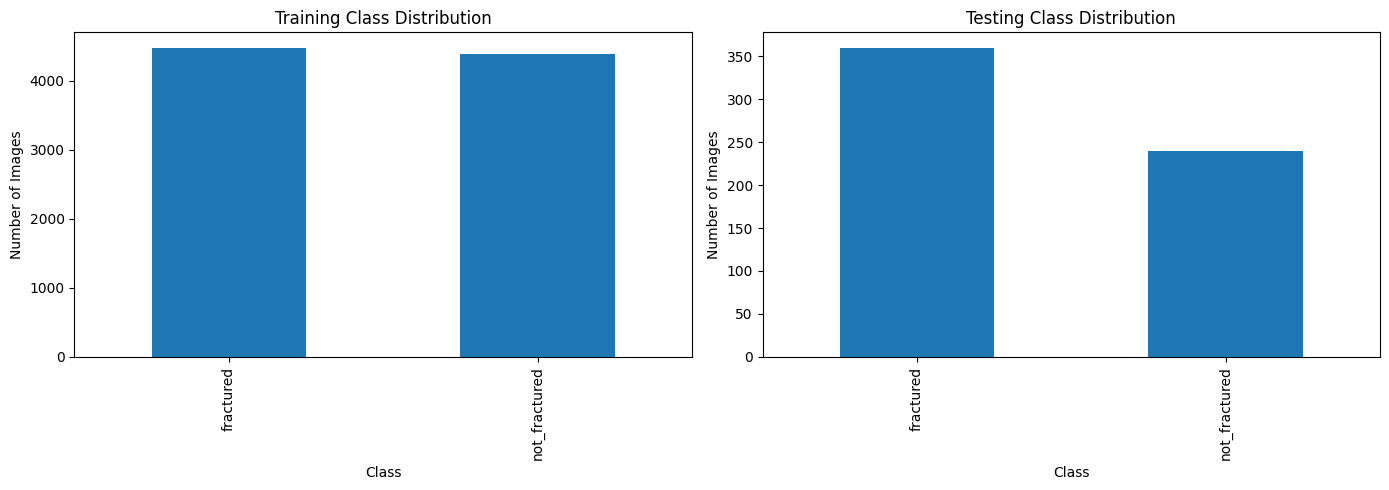

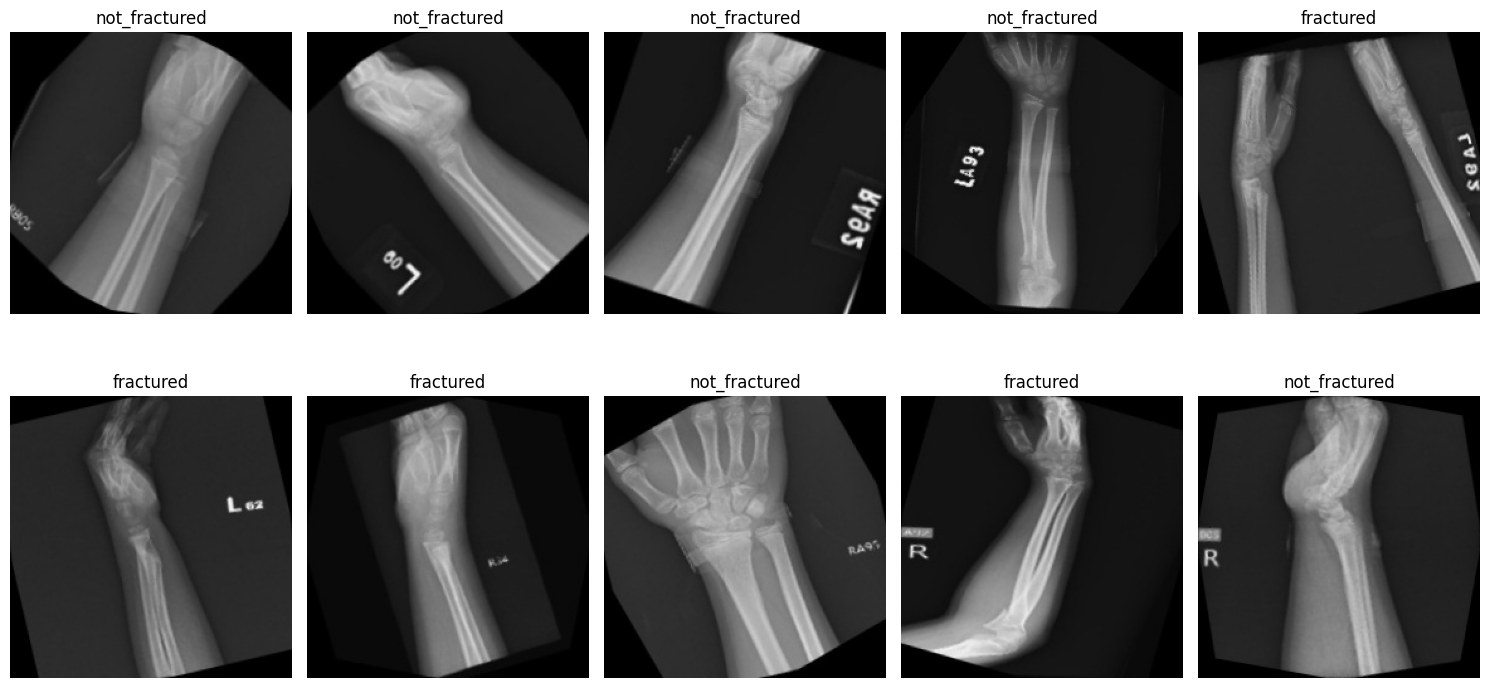


MODULE 1 COMPLETED

Training Images: 8863
Testing Images: 600
Classes: ['fractured', 'not_fractured']
Training Corrupted: 0
Testing Corrupted: 0

Class mapping: {'fractured': 0, 'not_fractured': 1}


In [1]:
# ============================================================
# MODULE 1
# COMPLETE DATASET QUALITY CONTROL
# TRAINING + TESTING
# ============================================================

import os
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from collections import Counter


# ============================================================
# 1. PATHS
# ============================================================

TRAIN_DIR = "/kaggle/input/datasets/zebagull/bones-dataset/training"

TEST_DIR = "/kaggle/input/datasets/zebagull/bones-dataset/testing"


# ============================================================
# 2. CONFIGURATION
# ============================================================

SEED = 42

np.random.seed(SEED)

IMAGE_EXTENSIONS = (
    "*.jpg",
    "*.jpeg",
    "*.png",
    "*.bmp",
    "*.tif",
    "*.tiff",
    "*.JPG",
    "*.JPEG",
    "*.PNG",
    "*.BMP",
    "*.TIF",
    "*.TIFF"
)


# ============================================================
# 3. CHECK PATHS
# ============================================================

print("=" * 75)
print("MODULE 1 - DATASET QUALITY CONTROL")
print("=" * 75)

if not os.path.exists(TRAIN_DIR):

    raise FileNotFoundError(
        f"Training directory not found:\n{TRAIN_DIR}"
    )

if not os.path.exists(TEST_DIR):

    raise FileNotFoundError(
        f"Testing directory not found:\n{TEST_DIR}"
    )


print("\nTraining path:")
print(TRAIN_DIR)

print("\nTesting path:")
print(TEST_DIR)


# ============================================================
# 4. FIND CLASSES
# ============================================================

train_classes = sorted([

    folder

    for folder in os.listdir(TRAIN_DIR)

    if os.path.isdir(
        os.path.join(
            TRAIN_DIR,
            folder
        )
    )

])


test_classes = sorted([

    folder

    for folder in os.listdir(TEST_DIR)

    if os.path.isdir(
        os.path.join(
            TEST_DIR,
            folder
        )
    )

])


print("\nTraining Classes:")
print(train_classes)

print("\nTesting Classes:")
print(test_classes)


# ============================================================
# 5. VERIFY SAME CLASSES
# ============================================================

if train_classes != test_classes:

    raise ValueError(

        "Training and testing classes do not match.\n\n"
        f"Training: {train_classes}\n"
        f"Testing : {test_classes}"

    )


classes = train_classes

NUM_CLASSES = len(classes)


print(
    "\nNumber of Classes:",
    NUM_CLASSES
)


# ============================================================
# 6. CLASS MAPPING
# ============================================================

class_to_index = {

    class_name: index

    for index, class_name in enumerate(
        classes
    )

}


index_to_class = {

    index: class_name

    for class_name, index in class_to_index.items()

}


print("\nClass Mapping:")
print(class_to_index)


# ============================================================
# 7. FUNCTION TO COLLECT IMAGES
# ============================================================

def collect_images(dataset_dir):

    records = []

    for class_name in classes:

        class_path = os.path.join(

            dataset_dir,
            class_name

        )

        for extension in IMAGE_EXTENSIONS:

            files = glob.glob(

                os.path.join(
                    class_path,
                    extension
                )

            )

            for file_path in files:

                records.append({

                    "filepath": file_path,

                    "class": class_name,

                    "label":
                    class_to_index[class_name]

                })

    return pd.DataFrame(records)


# ============================================================
# 8. CREATE DATAFRAMES
# ============================================================

train_df = collect_images(
    TRAIN_DIR
)

test_df = collect_images(
    TEST_DIR
)


if len(train_df) == 0:

    raise ValueError(
        "No training images found."
    )


if len(test_df) == 0:

    raise ValueError(
        "No testing images found."
    )


print("\nTraining images:", len(train_df))

print("Testing images :", len(test_df))


# ============================================================
# 9. IMAGE QUALITY FUNCTION
# ============================================================

def analyze_images(dataframe):

    widths = []
    heights = []
    modes = []
    corrupted = []

    for file_path in dataframe["filepath"]:

        try:

            with Image.open(file_path) as img:

                img.verify()

            with Image.open(file_path) as img:

                widths.append(img.width)
                heights.append(img.height)
                modes.append(img.mode)

        except Exception as error:

            corrupted.append({

                "filepath": file_path,

                "error": str(error)

            })


    return (
        widths,
        heights,
        modes,
        corrupted
    )


# ============================================================
# 10. TRAINING QUALITY
# ============================================================

print("\nChecking training images...")

(
    train_widths,
    train_heights,
    train_modes,
    train_corrupted
) = analyze_images(train_df)


# ============================================================
# 11. TESTING QUALITY
# ============================================================

print("Checking testing images...")

(
    test_widths,
    test_heights,
    test_modes,
    test_corrupted
) = analyze_images(test_df)


# ============================================================
# 12. REPORT IMAGE QUALITY
# ============================================================

print("\n" + "=" * 75)

print("IMAGE QUALITY REPORT")

print("=" * 75)


print(
    "\nTraining corrupted images:",
    len(train_corrupted)
)

print(
    "Testing corrupted images :",
    len(test_corrupted)
)


print("\nTraining image modes:")

print(
    Counter(train_modes)
)


print("\nTesting image modes:")

print(
    Counter(test_modes)
)


# ============================================================
# 13. DIMENSION REPORT
# ============================================================

print("\nTraining dimensions:")

print(
    "Minimum width :",
    min(train_widths)
)

print(
    "Maximum width :",
    max(train_widths)
)

print(
    "Average width :",
    round(np.mean(train_widths), 2)
)

print(
    "Minimum height:",
    min(train_heights)
)

print(
    "Maximum height:",
    max(train_heights)
)

print(
    "Average height:",
    round(np.mean(train_heights), 2)
)


print("\nTesting dimensions:")

print(
    "Minimum width :",
    min(test_widths)
)

print(
    "Maximum width :",
    max(test_widths)
)

print(
    "Average width :",
    round(np.mean(test_widths), 2)
)

print(
    "Minimum height:",
    min(test_heights)
)

print(
    "Maximum height:",
    max(test_heights)
)

print(
    "Average height:",
    round(np.mean(test_heights), 2)
)


# ============================================================
# 14. CLASS DISTRIBUTION
# ============================================================

train_distribution = (
    train_df["class"]
    .value_counts()
    .reindex(classes)
)

test_distribution = (
    test_df["class"]
    .value_counts()
    .reindex(classes)
)


print("\nTraining Class Distribution:")

print(train_distribution)


print("\nTesting Class Distribution:")

print(test_distribution)


# ============================================================
# 15. CLASS DISTRIBUTION PLOT
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)


train_distribution.plot(
    kind="bar",
    ax=axes[0]
)

axes[0].set_title(
    "Training Class Distribution"
)

axes[0].set_xlabel(
    "Class"
)

axes[0].set_ylabel(
    "Number of Images"
)


test_distribution.plot(
    kind="bar",
    ax=axes[1]
)

axes[1].set_title(
    "Testing Class Distribution"
)

axes[1].set_xlabel(
    "Class"
)

axes[1].set_ylabel(
    "Number of Images"
)


plt.tight_layout()

plt.show()


# ============================================================
# 16. SAVE DATAFRAMES
# ============================================================

train_df.to_csv(
    "/kaggle/working/training_metadata.csv",
    index=False
)

test_df.to_csv(
    "/kaggle/working/testing_metadata.csv",
    index=False
)


# ============================================================
# 17. SAVE CLASS MAPPING
# ============================================================

with open(
    "/kaggle/working/class_mapping.json",
    "w"
) as file:

    json.dump(
        class_to_index,
        file,
        indent=4
    )


# ============================================================
# 18. SAMPLE IMAGES
# ============================================================

plt.figure(
    figsize=(15, 8)
)


sample_df = train_df.sample(
    min(10, len(train_df)),
    random_state=SEED
)


for i, (_, row) in enumerate(
    sample_df.iterrows()
):

    image = Image.open(
        row["filepath"]
    ).convert("RGB")

    plt.subplot(
        2,
        5,
        i + 1
    )

    plt.imshow(image)

    plt.title(
        row["class"]
    )

    plt.axis("off")


plt.tight_layout()

plt.show()


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 75)

print("MODULE 1 COMPLETED")

print("=" * 75)

print(
    "\nTraining Images:",
    len(train_df)
)

print(
    "Testing Images:",
    len(test_df)
)

print(
    "Classes:",
    classes
)

print(
    "Training Corrupted:",
    len(train_corrupted)
)

print(
    "Testing Corrupted:",
    len(test_corrupted)
)

print(
    "\nClass mapping:",
    class_to_index
)

# MODULE 2 — Preprocessing + Training/Test Generators

MODULE 2 - PREPROCESSING PIPELINE
Found 8863 validated image filenames belonging to 2 classes.
Found 600 validated image filenames belonging to 2 classes.

GENERATOR INFORMATION

Training samples: 8863
Training batches: 277

Testing samples: 600
Testing batches: 19

Class indices: {'fractured': 0, 'not_fractured': 1}

Testing batch shape:
(32, 224, 224, 3)
(32, 2)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..171.58899].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..242.21083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..242.56985].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..244.93556].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..234.20798].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..244.41312].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..206.39186].
Clipping input data to the valid r

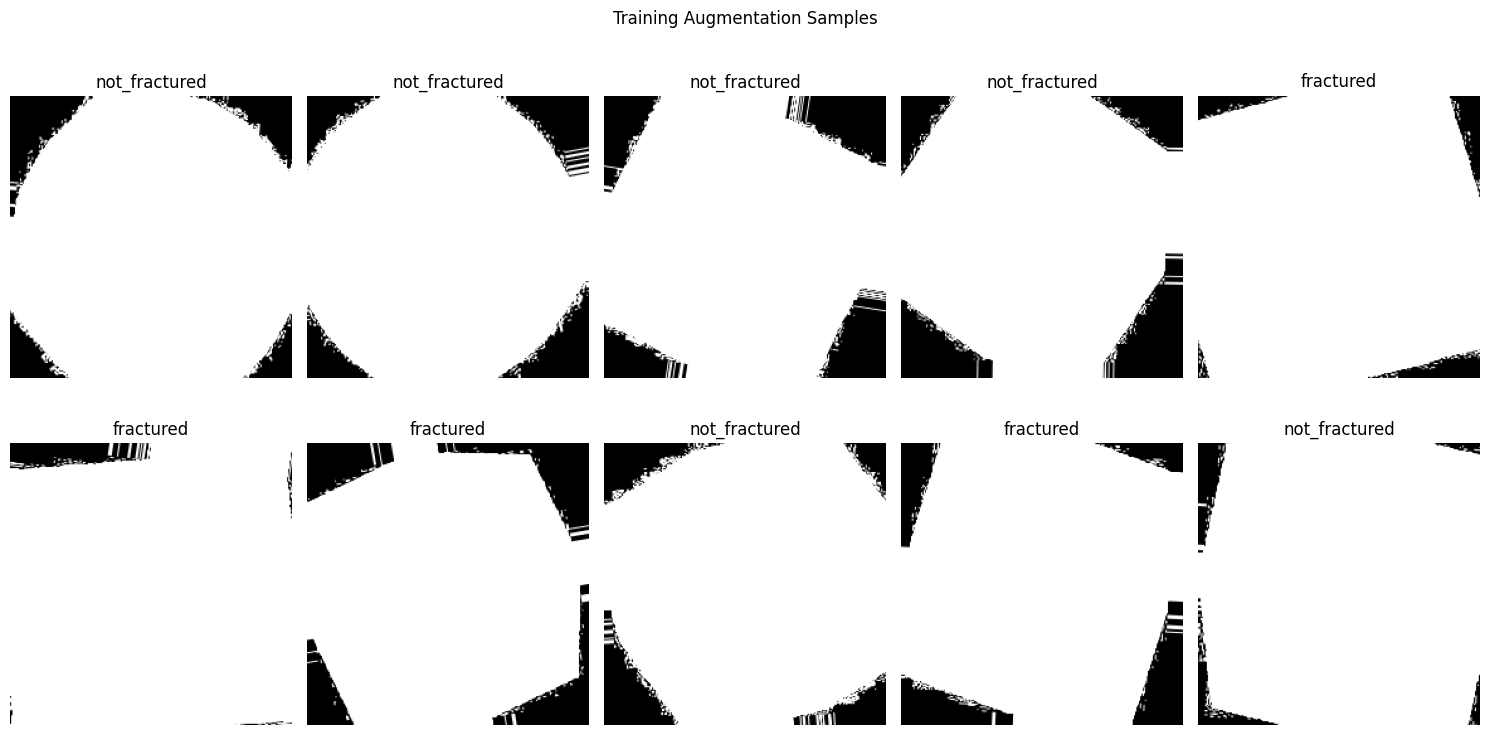


Class Weights:
{0: np.float64(0.9891741071428571), 1: np.float64(1.0110654802646588)}

PREPROCESSING SUMMARY

Resize: 224 x 224
Channels: RGB
Training augmentation: Rotation + Shift + Zoom
Horizontal flip: Disabled
Testing augmentation: NONE
Training/Test split: Existing folders are used directly

Module 2 completed successfully.


In [2]:
# ============================================================
# MODULE 2
# MODEL-READY PREPROCESSING PIPELINE
# TRAINING AUGMENTATION + CLEAN TESTING
# ============================================================

import numpy as np
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator


# ============================================================
# CONFIGURATION
# ============================================================

IMG_SIZE = (224, 224)

BATCH_SIZE = 32

SEED = 42


print("=" * 75)

print("MODULE 2 - PREPROCESSING PIPELINE")

print("=" * 75)


# ============================================================
# 1. TRAINING GENERATOR
# ============================================================
#
# Mild medical-image augmentation.
#
# Horizontal flipping is intentionally NOT used.
#
# ============================================================

train_datagen = ImageDataGenerator(

    rotation_range=10,

    width_shift_range=0.05,

    height_shift_range=0.05,

    zoom_range=0.10,

    fill_mode="nearest"

)


# ============================================================
# 2. TEST GENERATOR
# ============================================================
#
# NO AUGMENTATION
# NO SHUFFLING
#
# Testing images remain deterministic.
#
# ============================================================

test_datagen = ImageDataGenerator()


# ============================================================
# 3. BASE GENERATORS
# ============================================================

train_generator = train_datagen.flow_from_dataframe(

    dataframe=train_df,

    x_col="filepath",

    y_col="class",

    target_size=IMG_SIZE,

    color_mode="rgb",

    class_mode="categorical",

    classes=classes,

    batch_size=BATCH_SIZE,

    shuffle=True,

    seed=SEED

)


test_generator = test_datagen.flow_from_dataframe(

    dataframe=test_df,

    x_col="filepath",

    y_col="class",

    target_size=IMG_SIZE,

    color_mode="rgb",

    class_mode="categorical",

    classes=classes,

    batch_size=BATCH_SIZE,

    shuffle=False

)


# ============================================================
# 4. INFORMATION
# ============================================================

print("\n" + "=" * 75)

print("GENERATOR INFORMATION")

print("=" * 75)


print(
    "\nTraining samples:",
    train_generator.samples
)

print(
    "Training batches:",
    len(train_generator)
)

print(
    "\nTesting samples:",
    test_generator.samples
)

print(
    "Testing batches:",
    len(test_generator)
)

print(
    "\nClass indices:",
    train_generator.class_indices
)


# ============================================================
# 5. CHECK RAW TEST DATA
# ============================================================

test_generator.reset()

test_images, test_labels = next(
    test_generator
)


print("\nTesting batch shape:")

print(
    test_images.shape
)

print(
    test_labels.shape
)


# ============================================================
# 6. VISUALIZE TRAINING AUGMENTATION
# ============================================================

train_generator.reset()

aug_images, aug_labels = next(
    train_generator
)


plt.figure(
    figsize=(15, 8)
)


for i in range(
    min(10, len(aug_images))
):

    plt.subplot(
        2,
        5,
        i + 1
    )

    plt.imshow(
        aug_images[i]
    )

    label_index = np.argmax(
        aug_labels[i]
    )

    plt.title(
        classes[label_index]
    )

    plt.axis("off")


plt.suptitle(
    "Training Augmentation Samples"
)

plt.tight_layout()

plt.show()


# ============================================================
# 7. CLASS WEIGHTS
# ============================================================

class_counts = (
    train_df["class"]
    .value_counts()
)


total_samples = len(
    train_df
)


class_weights = {}


for class_name in classes:

    count = class_counts[class_name]

    class_index = class_to_index[
        class_name
    ]

    class_weights[
        class_index
    ] = (

        total_samples /

        (
            len(classes) *
            count
        )

    )


print(
    "\nClass Weights:"
)

print(
    class_weights
)


# ============================================================
# 8. PREPROCESSING SUMMARY
# ============================================================

print("\n" + "=" * 75)

print("PREPROCESSING SUMMARY")

print("=" * 75)


print(
    "\nResize:",
    "224 x 224"
)

print(
    "Channels:",
    "RGB"
)

print(
    "Training augmentation:",
    "Rotation + Shift + Zoom"
)

print(
    "Horizontal flip:",
    "Disabled"
)

print(
    "Testing augmentation:",
    "NONE"
)

print(
    "Training/Test split:",
    "Existing folders are used directly"
)

print(
    "\nModule 2 completed successfully."
)

# MODULE 3 — Model Factory + Stage 1 Transfer Learning


STAGE 1 - ResNet50


I0000 00:00:1790965867.038990     343 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790965867.041302     343 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/5
  1/277 ━━━━━━━━━━━━━━━━━━━━ 1:13:33 16s/step - accuracy: 0.4688 - loss: 0.8850

I0000 00:00:1790965886.345801     411 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.6561 - loss: 0.6522
Epoch 1: loss improved from None to 0.53478, saving model to /kaggle/working/ResNet50_stage1_best.keras

Epoch 1: finished saving model to /kaggle/working/ResNet50_stage1_best.keras
277/277 ━━━━━━━━━━━━━━━━━━━━ 143s 459ms/step - accuracy: 0.7281 - loss: 0.5348 - learning_rate: 1.0000e-04
Epoch 2/5
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.8546 - loss: 0.3471
Epoch 2: loss improved from 0.53478 to 0.33115, saving model to /kaggle/working/ResNet50_stage1_best.keras

Epoch 2: finished saving model to /kaggle/working/ResNet50_stage1_best.keras
277/277 ━━━━━━━━━━━━━━━━━━━━ 122s 439ms/step - accuracy: 0.8648 - loss: 0.3312 - learning_rate: 1.0000e-04
Epoch 3/5
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.9062 - loss: 0.2564
Epoch 3: loss improved from 0.33115 to 0.24150, saving model to /kaggle/working/ResNet50_stage1_best.keras

Epoch 3: finished saving model to /kaggle/working/ResNet50_s

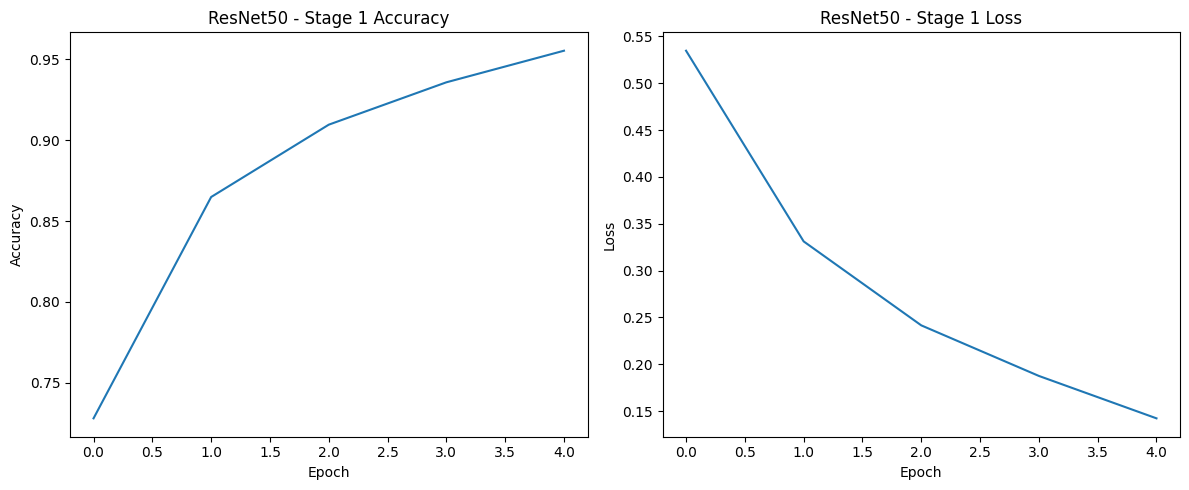


STAGE 1 - DenseNet121
Epoch 1/5
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step - accuracy: 0.5980 - loss: 0.7158
Epoch 1: loss improved from None to 0.61484, saving model to /kaggle/working/DenseNet121_stage1_best.keras

Epoch 1: finished saving model to /kaggle/working/DenseNet121_stage1_best.keras
277/277 ━━━━━━━━━━━━━━━━━━━━ 171s 500ms/step - accuracy: 0.6632 - loss: 0.6148 - learning_rate: 1.0000e-04
Epoch 2/5
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step - accuracy: 0.7718 - loss: 0.4722
Epoch 2: loss improved from 0.61484 to 0.45326, saving model to /kaggle/working/DenseNet121_stage1_best.keras

Epoch 2: finished saving model to /kaggle/working/DenseNet121_stage1_best.keras
277/277 ━━━━━━━━━━━━━━━━━━━━ 134s 485ms/step - accuracy: 0.7835 - loss: 0.4533 - learning_rate: 1.0000e-04
Epoch 3/5
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.8337 - loss: 0.3859
Epoch 3: loss improved from 0.45326 to 0.37306, saving model to /kaggle/working/DenseNet121_stage1_best.keras

Epoch 3: fin

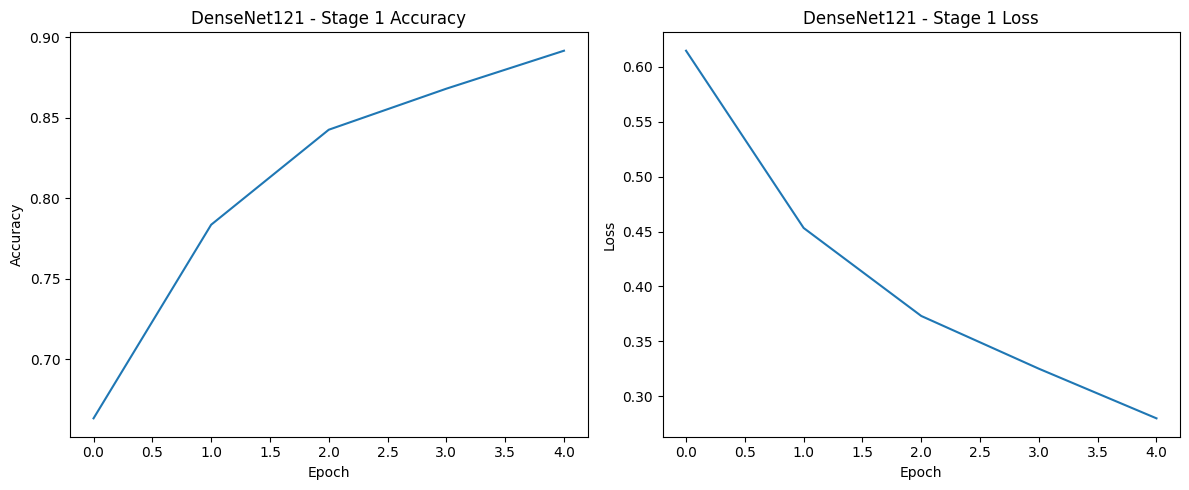


STAGE 1 - EfficientNetB0
Epoch 1/5


2026-10-02 18:53:21.955557: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-02 18:53:22.099033: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-02 18:53:22.458799: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-02 18:53:22.602108: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-02 18:53:23.487423: E external/local_xla/xla/stream_

197/277 ━━━━━━━━━━━━━━━━━━━━ 34s 426ms/step - accuracy: 0.6271 - loss: 0.6458

2026-10-02 18:55:04.612276: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-02 18:55:04.755941: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-02 18:55:05.115653: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-02 18:55:05.258892: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-02 18:55:06.152681: E external/local_xla/xla/stream_

277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 495ms/step - accuracy: 0.6506 - loss: 0.6197
Epoch 1: loss improved from None to 0.53848, saving model to /kaggle/working/EfficientNetB0_stage1_best.keras

Epoch 1: finished saving model to /kaggle/working/EfficientNetB0_stage1_best.keras
277/277 ━━━━━━━━━━━━━━━━━━━━ 168s 499ms/step - accuracy: 0.7219 - loss: 0.5385 - learning_rate: 1.0000e-04
Epoch 2/5
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.8334 - loss: 0.3917
Epoch 2: loss improved from 0.53848 to 0.36736, saving model to /kaggle/working/EfficientNetB0_stage1_best.keras

Epoch 2: finished saving model to /kaggle/working/EfficientNetB0_stage1_best.keras
277/277 ━━━━━━━━━━━━━━━━━━━━ 120s 431ms/step - accuracy: 0.8428 - loss: 0.3674 - learning_rate: 1.0000e-04
Epoch 3/5
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - accuracy: 0.8736 - loss: 0.3122
Epoch 3: loss improved from 0.36736 to 0.28974, saving model to /kaggle/working/EfficientNetB0_stage1_best.keras

Epoch 3: finished saving model

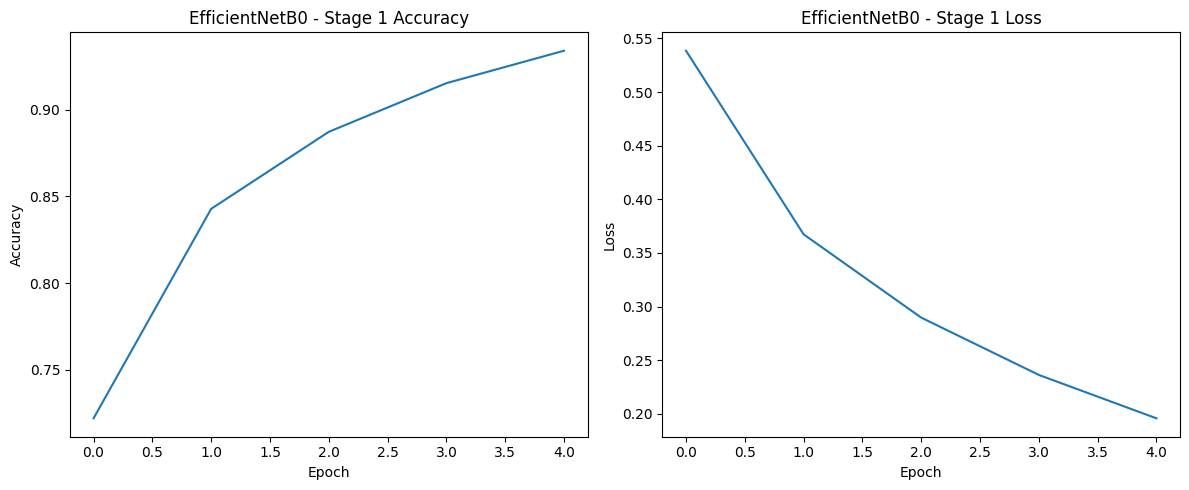


STAGE 1 - VGG16
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step - accuracy: 0.5708 - loss: 1.4073
Epoch 1: loss improved from None to 1.08313, saving model to /kaggle/working/VGG16_stage1_best.keras

Epoch 1: finished saving model to /kaggle/working/VGG16_stage1_best.keras
277/277 ━━━━━━━━━━━━━━━━━━━━ 153s 499ms/step - accuracy: 0.6125 - loss: 1.0831 - learning_rate: 1.0000e-04
Epoch 2/5
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.7246 - loss: 0.5927
Epoch 2: loss improved from 1.08313 to 0.53387, saving model to /kaggle/working/VGG16_stage1_best.keras

Epoch 2: finished saving model to /kaggle/working/VGG16_stage1_best.keras
277/277 ━━━━━━━━━━━━━━━━━━━━ 125s 451ms/step - accuracy: 0.7518 - loss: 0.5339 - learning_rate: 1.0000e-04
Epoch 3/5
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.8052 - loss: 0.4185
Epoch 3: loss improved from 0.53387 to 0.39149, saving model to /kaggle/working/VGG16_stage1_best.kera

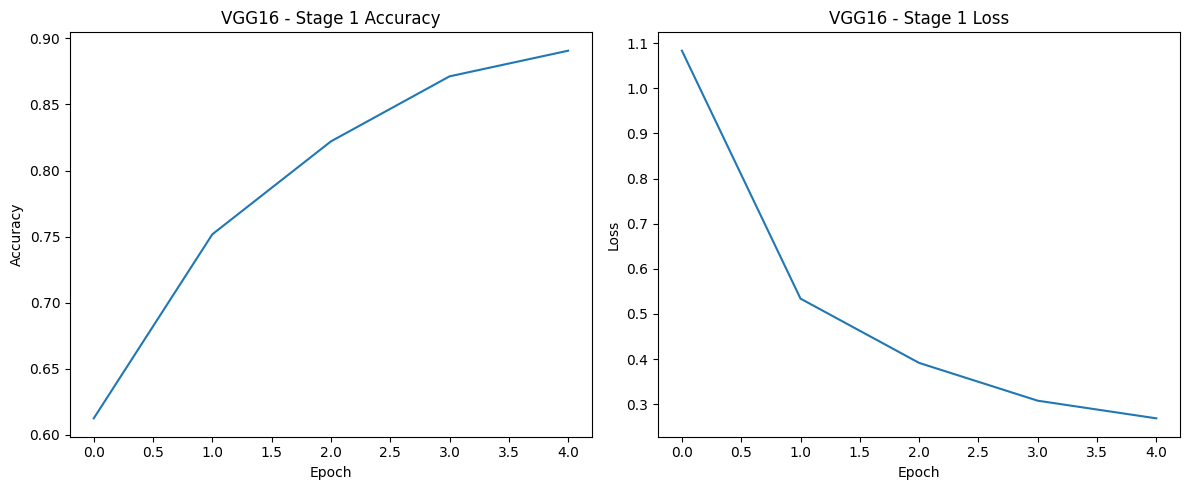


STAGE 1 - MobileNetV2
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5


2026-10-02 19:15:24.330605: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-02 19:15:24.468626: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


136/277 ━━━━━━━━━━━━━━━━━━━━ 58s 417ms/step - accuracy: 0.6032 - loss: 0.7079

2026-10-02 19:16:31.741028: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-02 19:16:31.878424: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step - accuracy: 0.6538 - loss: 0.6385
Epoch 1: loss improved from None to 0.53879, saving model to /kaggle/working/MobileNetV2_stage1_best.keras

Epoch 1: finished saving model to /kaggle/working/MobileNetV2_stage1_best.keras
277/277 ━━━━━━━━━━━━━━━━━━━━ 145s 465ms/step - accuracy: 0.7253 - loss: 0.5388 - learning_rate: 1.0000e-04
Epoch 2/5
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.8331 - loss: 0.3881
Epoch 2: loss improved from 0.53879 to 0.36325, saving model to /kaggle/working/MobileNetV2_stage1_best.keras

Epoch 2: finished saving model to /kaggle/working/MobileNetV2_stage1_best.keras
277/277 ━━━━━━━━━━━━━━━━━━━━ 117s 423ms/step - accuracy: 0.8461 - loss: 0.3632 - learning_rate: 1.0000e-04
Epoch 3/5
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.8879 - loss: 0.2892
Epoch 3: loss improved from 0.36325 to 0.28216, saving model to /kaggle/working/MobileNetV2_stage1_best.keras

Epoch 3: finished saving model to /kaggle/wor

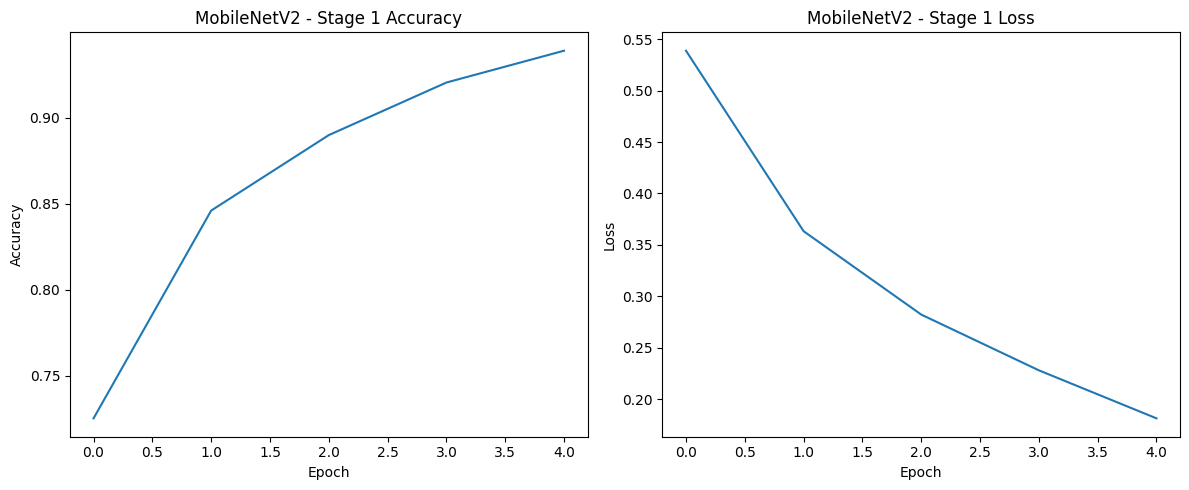


STAGE 1 COMPLETED FOR ALL 5 MODELS


In [3]:
# ============================================================
# MODULE 3
# MODEL FACTORY + STAGE 1 TRANSFER LEARNING
# ============================================================

import os
import gc
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, Model

from tensorflow.keras.applications import (

    ResNet50,

    DenseNet121,

    EfficientNetB0,

    VGG16,

    MobileNetV2

)

from tensorflow.keras.applications.resnet50 import (
    preprocess_input as resnet_preprocess
)

from tensorflow.keras.applications.densenet import (
    preprocess_input as densenet_preprocess
)

from tensorflow.keras.applications.vgg16 import (
    preprocess_input as vgg_preprocess
)

from tensorflow.keras.applications.mobilenet_v2 import (
    preprocess_input as mobilenet_preprocess
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from tensorflow.keras.optimizers import Adam


# ============================================================
# CONFIGURATION
# ============================================================

STAGE1_EPOCHS = 5

STAGE1_LR = 1e-4

DROPOUT = 0.40


MODEL_NAMES = [

    "ResNet50",

    "DenseNet121",

    "EfficientNetB0",

    "VGG16",

    "MobileNetV2"

]


# ============================================================
# MODEL FACTORY
# ============================================================

def build_model(model_name):

    input_layer = layers.Input(
        shape=(224, 224, 3),
        name="input_image"
    )


    # --------------------------------------------------------
    # RESNET50
    # --------------------------------------------------------

    if model_name == "ResNet50":

        x = layers.Lambda(
            resnet_preprocess,
            name="resnet_preprocess"
        )(input_layer)

        base = ResNet50(
            weights="imagenet",
            include_top=False,
            input_shape=(224, 224, 3)
        )


    # --------------------------------------------------------
    # DENSENET121
    # --------------------------------------------------------

    elif model_name == "DenseNet121":

        x = layers.Lambda(
            densenet_preprocess,
            name="densenet_preprocess"
        )(input_layer)

        base = DenseNet121(
            weights="imagenet",
            include_top=False,
            input_shape=(224, 224, 3)
        )


    # --------------------------------------------------------
    # VGG16
    # --------------------------------------------------------

    elif model_name == "VGG16":

        x = layers.Lambda(
            vgg_preprocess,
            name="vgg_preprocess"
        )(input_layer)

        base = VGG16(
            weights="imagenet",
            include_top=False,
            input_shape=(224, 224, 3)
        )


    # --------------------------------------------------------
    # MOBILENETV2
    # --------------------------------------------------------

    elif model_name == "MobileNetV2":

        x = layers.Lambda(
            mobilenet_preprocess,
            name="mobilenet_preprocess"
        )(input_layer)

        base = MobileNetV2(
            weights="imagenet",
            include_top=False,
            input_shape=(224, 224, 3)
        )


    # --------------------------------------------------------
    # EFFICIENTNETB0
    # --------------------------------------------------------

    elif model_name == "EfficientNetB0":

        # EfficientNet in tf.keras contains its
        # preprocessing internally.

        x = input_layer

        base = EfficientNetB0(
            weights="imagenet",
            include_top=False,
            input_shape=(224, 224, 3)
        )


    else:

        raise ValueError(
            f"Unknown model: {model_name}"
        )


    # ========================================================
    # FREEZE BACKBONE
    # ========================================================

    base.trainable = False


    # ========================================================
    # FEATURE EXTRACTION
    # ========================================================

    x = base(x, training=False)


    x = layers.GlobalAveragePooling2D(
        name="global_average_pooling"
    )(x)


    x = layers.Dense(
        256,
        activation="relu",
        name="feature_dense"
    )(x)


    x = layers.Dropout(
        DROPOUT,
        name="dropout"
    )(x)


    output = layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        name="prediction"
    )(x)


    model = Model(
        input_layer,
        output,
        name=model_name
    )


    # ========================================================
    # COMPILE
    # ========================================================

    model.compile(

        optimizer=Adam(
            learning_rate=STAGE1_LR
        ),

        loss="categorical_crossentropy",

        metrics=[
            "accuracy"
        ]

    )


    return model, base


# ============================================================
# STAGE 1 TRAINING FUNCTION
# ============================================================

def train_stage1(model_name):

    print("\n" + "=" * 75)

    print(
        f"STAGE 1 - {model_name}"
    )

    print("=" * 75)


    model, base = build_model(
        model_name
    )


    checkpoint_path = (

        f"/kaggle/working/"
        f"{model_name}_stage1_best.keras"

    )


    callbacks = [

        EarlyStopping(

            monitor="loss",

            patience=3,

            restore_best_weights=True,

            verbose=1

        ),

        ReduceLROnPlateau(

            monitor="loss",

            factor=0.2,

            patience=2,

            min_lr=1e-7,

            verbose=1

        ),

        ModelCheckpoint(

            checkpoint_path,

            monitor="loss",

            save_best_only=True,

            verbose=1

        )

    ]


    history = model.fit(

        train_generator,

        epochs=STAGE1_EPOCHS,

        class_weight=class_weights,

        callbacks=callbacks,

        verbose=1

    )


    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    plt.figure(
        figsize=(12, 5)
    )


    plt.subplot(
        1,
        2,
        1
    )

    plt.plot(
        history.history["accuracy"]
    )

    plt.title(
        f"{model_name} - Stage 1 Accuracy"
    )

    plt.xlabel(
        "Epoch"
    )

    plt.ylabel(
        "Accuracy"
    )


    plt.subplot(
        1,
        2,
        2
    )

    plt.plot(
        history.history["loss"]
    )

    plt.title(
        f"{model_name} - Stage 1 Loss"
    )

    plt.xlabel(
        "Epoch"
    )

    plt.ylabel(
        "Loss"
    )


    plt.tight_layout()

    plt.show()


    return (
        model,
        base,
        history
    )


# ============================================================
# TRAIN ALL 5 MODELS - STAGE 1
# ============================================================

stage1_models = {}

stage1_histories = {}


for model_name in MODEL_NAMES:

    train_generator.reset()

    (
        model,
        base,
        history
    ) = train_stage1(
        model_name
    )


    stage1_models[
        model_name
    ] = {

        "model": model,

        "base": base

    }


    stage1_histories[
        model_name
    ] = history


print("\n" + "=" * 75)

print(
    "STAGE 1 COMPLETED FOR ALL 5 MODELS"
)

print("=" * 75)

# MODULE 4 — Stage 2 Fine-Tuning + Best Model Selection


STAGE 2 - FINE-TUNING: ResNet50

Total backbone layers: 175
Unfreezing last layers: 30
Trainable layers: 7
Epoch 1/5
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - accuracy: 0.9694 - loss: 0.0999
Epoch 1: loss improved from None to 0.07166, saving model to /kaggle/working/ResNet50_fine_tuned_best.keras

Epoch 1: finished saving model to /kaggle/working/ResNet50_fine_tuned_best.keras
277/277 ━━━━━━━━━━━━━━━━━━━━ 152s 483ms/step - accuracy: 0.9774 - loss: 0.0717 - learning_rate: 1.0000e-05
Epoch 2/5
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.9904 - loss: 0.0302
Epoch 2: loss improved from 0.07166 to 0.02109, saving model to /kaggle/working/ResNet50_fine_tuned_best.keras

Epoch 2: finished saving model to /kaggle/working/ResNet50_fine_tuned_best.keras
277/277 ━━━━━━━━━━━━━━━━━━━━ 125s 450ms/step - accuracy: 0.9942 - loss: 0.0211 - learning_rate: 1.0000e-05
Epoch 3/5
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - accuracy: 0.9965 - loss: 0.0123
Epoch 3: loss improved from 0.0210

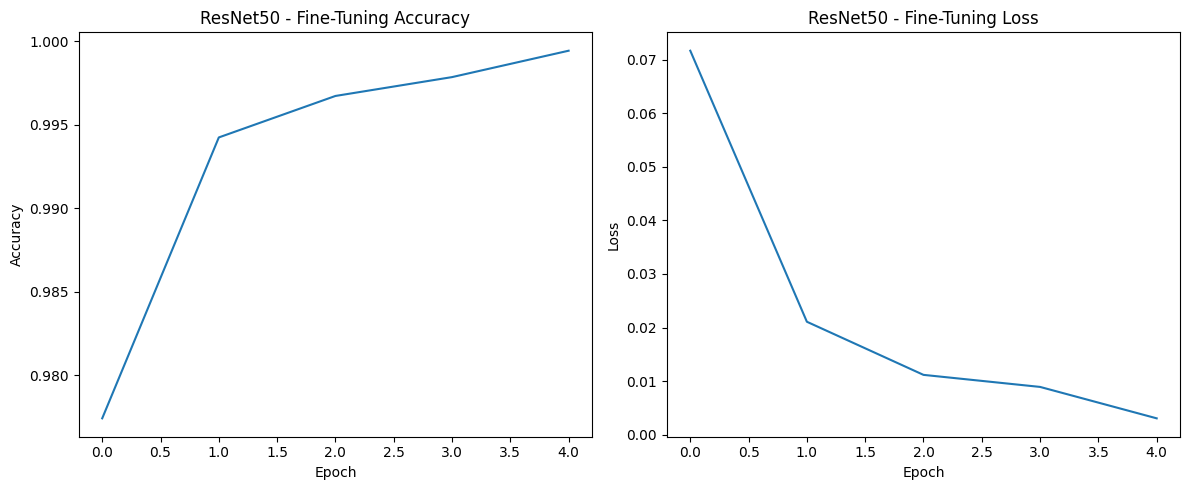


STAGE 2 - FINE-TUNING: DenseNet121

Total backbone layers: 427
Unfreezing last layers: 30
Trainable layers: 7
Epoch 1/5
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step - accuracy: 0.9159 - loss: 0.2435
Epoch 1: loss improved from None to 0.23316, saving model to /kaggle/working/DenseNet121_fine_tuned_best.keras

Epoch 1: finished saving model to /kaggle/working/DenseNet121_fine_tuned_best.keras
277/277 ━━━━━━━━━━━━━━━━━━━━ 165s 487ms/step - accuracy: 0.9187 - loss: 0.2332 - learning_rate: 1.0000e-05
Epoch 2/5
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.9259 - loss: 0.2160
Epoch 2: loss improved from 0.23316 to 0.20212, saving model to /kaggle/working/DenseNet121_fine_tuned_best.keras

Epoch 2: finished saving model to /kaggle/working/DenseNet121_fine_tuned_best.keras
277/277 ━━━━━━━━━━━━━━━━━━━━ 113s 407ms/step - accuracy: 0.9329 - loss: 0.2021 - learning_rate: 1.0000e-05
Epoch 3/5
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.9436 - loss: 0.1714
Epoch 3: loss impro

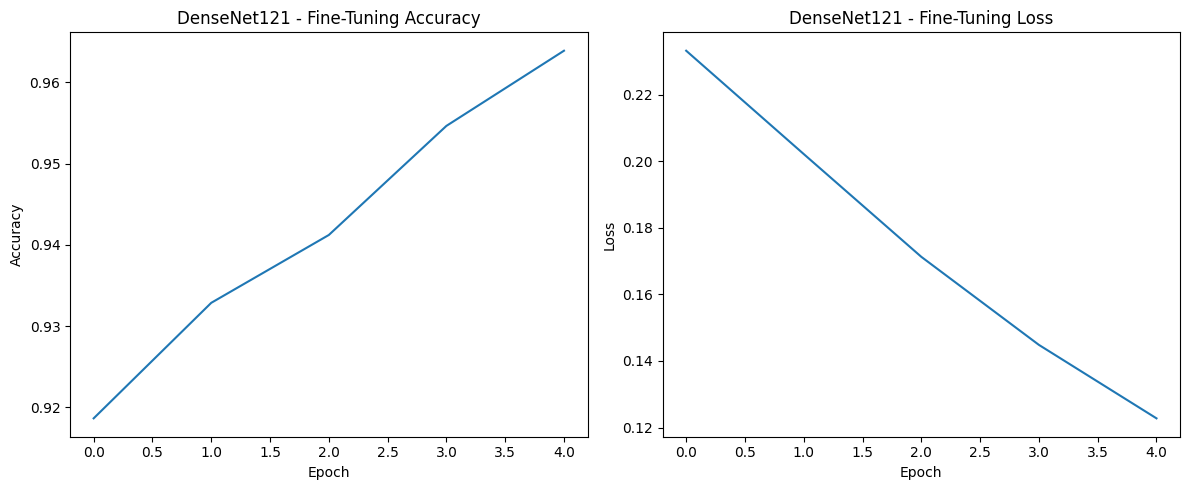


STAGE 2 - FINE-TUNING: EfficientNetB0

Total backbone layers: 238
Unfreezing last layers: 30
Trainable layers: 6
Epoch 1/5
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.9464 - loss: 0.1670
Epoch 1: loss improved from None to 0.15505, saving model to /kaggle/working/EfficientNetB0_fine_tuned_best.keras

Epoch 1: finished saving model to /kaggle/working/EfficientNetB0_fine_tuned_best.keras
277/277 ━━━━━━━━━━━━━━━━━━━━ 139s 416ms/step - accuracy: 0.9489 - loss: 0.1551 - learning_rate: 1.0000e-05
Epoch 2/5
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.9608 - loss: 0.1263
Epoch 2: loss improved from 0.15505 to 0.11778, saving model to /kaggle/working/EfficientNetB0_fine_tuned_best.keras

Epoch 2: finished saving model to /kaggle/working/EfficientNetB0_fine_tuned_best.keras
277/277 ━━━━━━━━━━━━━━━━━━━━ 107s 386ms/step - accuracy: 0.9652 - loss: 0.1178 - learning_rate: 1.0000e-05
Epoch 3/5
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.9680 - loss: 0.1053
Epoc

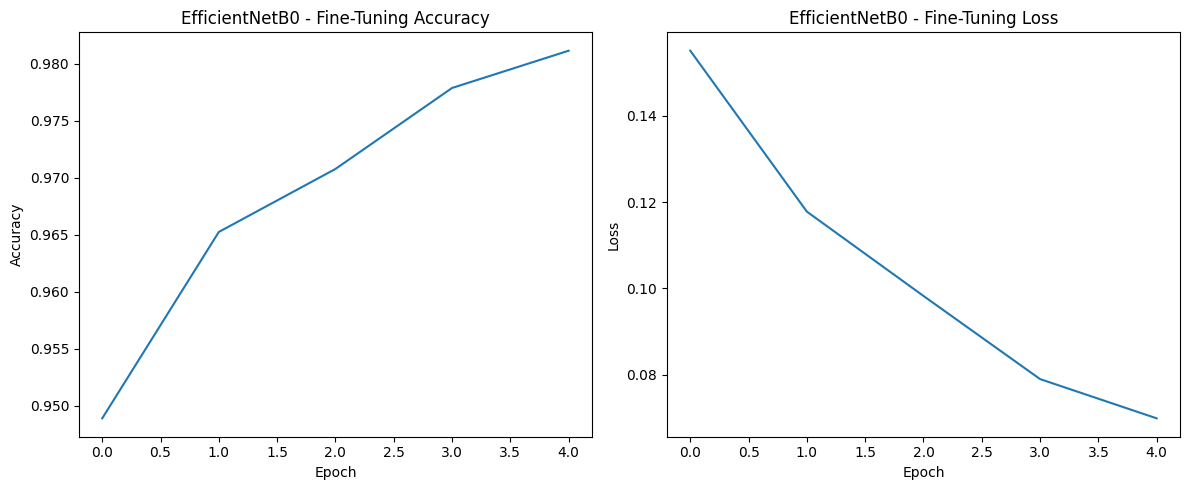


STAGE 2 - FINE-TUNING: VGG16

Total backbone layers: 19
Unfreezing last layers: 30
Trainable layers: 7
Epoch 1/5


2026-10-02 19:56:31.037522: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-02 19:56:31.237669: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-02 19:56:33.025200: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-02 19:56:33.199296: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-02 19:56:37.054700: E external/local_xla/xla/stream_

 79/277 ━━━━━━━━━━━━━━━━━━━━ 1:40 506ms/step - accuracy: 0.9022 - loss: 0.2311

2026-10-02 19:57:55.142210: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-02 19:57:55.349742: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-02 19:57:57.297683: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-02 19:57:57.477859: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-02 19:58:01.898512: E external/local_xla/xla/stream_

277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 688ms/step - accuracy: 0.9330 - loss: 0.1647
Epoch 1: loss improved from None to 0.10135, saving model to /kaggle/working/VGG16_fine_tuned_best.keras

Epoch 1: finished saving model to /kaggle/working/VGG16_fine_tuned_best.keras
277/277 ━━━━━━━━━━━━━━━━━━━━ 235s 691ms/step - accuracy: 0.9612 - loss: 0.1014 - learning_rate: 1.0000e-05
Epoch 2/5
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 505ms/step - accuracy: 0.9919 - loss: 0.0232
Epoch 2: loss improved from 0.10135 to 0.02272, saving model to /kaggle/working/VGG16_fine_tuned_best.keras

Epoch 2: finished saving model to /kaggle/working/VGG16_fine_tuned_best.keras
277/277 ━━━━━━━━━━━━━━━━━━━━ 141s 508ms/step - accuracy: 0.9926 - loss: 0.0227 - learning_rate: 1.0000e-05
Epoch 3/5
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step - accuracy: 0.9944 - loss: 0.0170
Epoch 3: loss improved from 0.02272 to 0.00953, saving model to /kaggle/working/VGG16_fine_tuned_best.keras

Epoch 3: finished saving model to /kaggle/working/VGG16

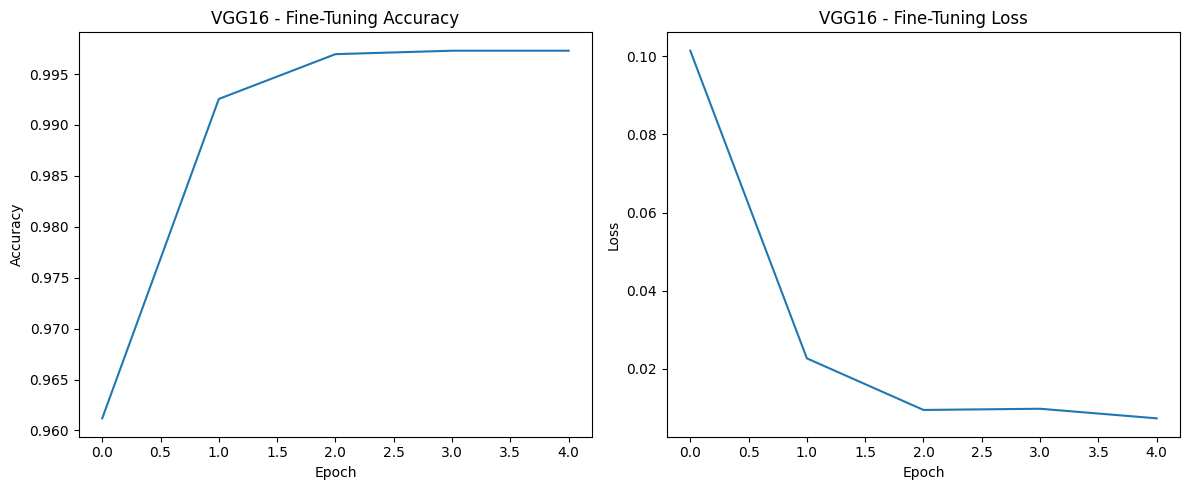


STAGE 2 - FINE-TUNING: MobileNetV2

Total backbone layers: 154
Unfreezing last layers: 30
Trainable layers: 7
Epoch 1/5
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - accuracy: 0.9468 - loss: 0.1505
Epoch 1: loss improved from None to 0.12662, saving model to /kaggle/working/MobileNetV2_fine_tuned_best.keras

Epoch 1: finished saving model to /kaggle/working/MobileNetV2_fine_tuned_best.keras
277/277 ━━━━━━━━━━━━━━━━━━━━ 119s 388ms/step - accuracy: 0.9569 - loss: 0.1266 - learning_rate: 1.0000e-05
Epoch 2/5
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 0.9759 - loss: 0.0835
Epoch 2: loss improved from 0.12662 to 0.07652, saving model to /kaggle/working/MobileNetV2_fine_tuned_best.keras

Epoch 2: finished saving model to /kaggle/working/MobileNetV2_fine_tuned_best.keras
277/277 ━━━━━━━━━━━━━━━━━━━━ 101s 363ms/step - accuracy: 0.9769 - loss: 0.0765 - learning_rate: 1.0000e-05
Epoch 3/5
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - accuracy: 0.9879 - loss: 0.0508
Epoch 3: loss impro

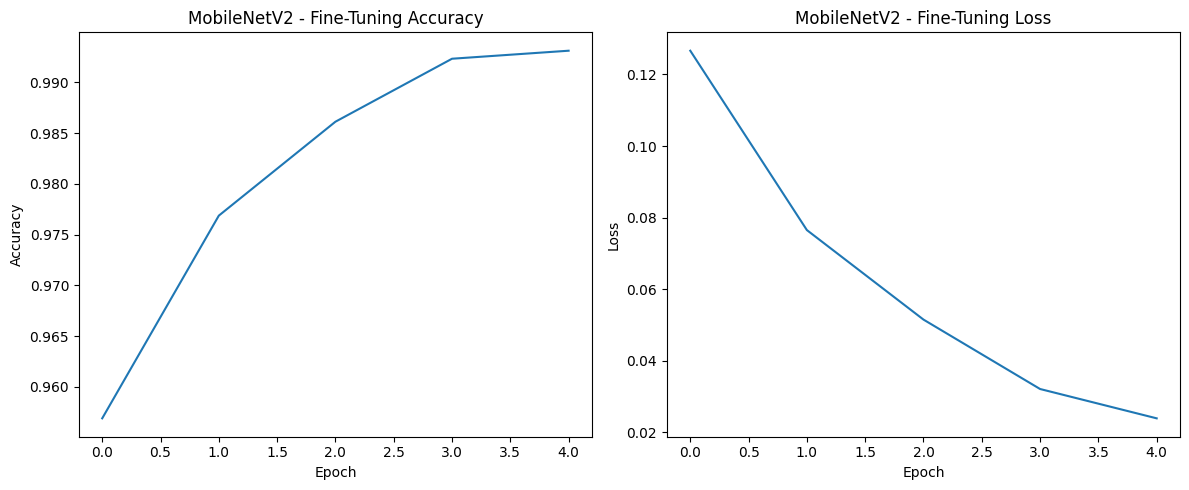

Saved: /kaggle/working/ResNet50_final.keras
Saved: /kaggle/working/DenseNet121_final.keras
Saved: /kaggle/working/EfficientNetB0_final.keras
Saved: /kaggle/working/VGG16_final.keras
Saved: /kaggle/working/MobileNetV2_final.keras

STAGE 2 FINE-TUNING COMPLETED


In [4]:
# ============================================================
# MODULE 4
# STAGE 2 FINE-TUNING
# ============================================================

import os
import gc
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from tensorflow.keras.optimizers import Adam


# ============================================================
# CONFIGURATION
# ============================================================

FINE_TUNE_EPOCHS = 5

FINE_TUNE_LR = 1e-5

UNFREEZE_LAST_LAYERS = 30


# ============================================================
# FINE-TUNING FUNCTION
# ============================================================

def fine_tune_model(
    model_name,
    model,
    base
):

    print("\n" + "=" * 75)

    print(
        f"STAGE 2 - FINE-TUNING: {model_name}"
    )

    print("=" * 75)


    # ========================================================
    # 1. UNFREEZE BACKBONE
    # ========================================================

    base.trainable = True


    # ========================================================
    # 2. FREEZE EARLY LAYERS
    # ========================================================

    total_layers = len(
        base.layers
    )


    freeze_until = max(

        0,

        total_layers -
        UNFREEZE_LAST_LAYERS

    )


    for layer in base.layers[
        :freeze_until
    ]:

        layer.trainable = False


    # ========================================================
    # 3. KEEP BATCH NORMALIZATION FROZEN
    # ========================================================

    for layer in base.layers:

        if isinstance(
            layer,
            tf.keras.layers.BatchNormalization
        ):

            layer.trainable = False


    trainable_count = sum(

        1

        for layer in model.layers

        if layer.trainable

    )


    print(
        "\nTotal backbone layers:",
        total_layers
    )

    print(
        "Unfreezing last layers:",
        UNFREEZE_LAST_LAYERS
    )

    print(
        "Trainable layers:",
        trainable_count
    )


    # ========================================================
    # 4. RECOMPILE WITH LOW LR
    # ========================================================

    model.compile(

        optimizer=Adam(
            learning_rate=FINE_TUNE_LR
        ),

        loss="categorical_crossentropy",

        metrics=[
            "accuracy"
        ]

    )


    # ========================================================
    # 5. CHECKPOINT
    # ========================================================

    checkpoint_path = (

        f"/kaggle/working/"
        f"{model_name}_fine_tuned_best.keras"

    )


    callbacks = [

        EarlyStopping(

            monitor="loss",

            patience=4,

            restore_best_weights=True,

            verbose=1

        ),

        ReduceLROnPlateau(

            monitor="loss",

            factor=0.2,

            patience=2,

            min_lr=1e-7,

            verbose=1

        ),

        ModelCheckpoint(

            checkpoint_path,

            monitor="loss",

            save_best_only=True,

            verbose=1

        )

    ]


    # ========================================================
    # 6. TRAIN
    # ========================================================

    train_generator.reset()


    history = model.fit(

        train_generator,

        epochs=FINE_TUNE_EPOCHS,

        class_weight=class_weights,

        callbacks=callbacks,

        verbose=1

    )


    # ========================================================
    # 7. PLOT
    # ========================================================

    plt.figure(
        figsize=(12, 5)
    )


    plt.subplot(
        1,
        2,
        1
    )

    plt.plot(
        history.history["accuracy"]
    )

    plt.title(
        f"{model_name} - Fine-Tuning Accuracy"
    )

    plt.xlabel(
        "Epoch"
    )

    plt.ylabel(
        "Accuracy"
    )


    plt.subplot(
        1,
        2,
        2
    )

    plt.plot(
        history.history["loss"]
    )

    plt.title(
        f"{model_name} - Fine-Tuning Loss"
    )

    plt.xlabel(
        "Epoch"
    )

    plt.ylabel(
        "Loss"
    )


    plt.tight_layout()

    plt.show()


    return history


# ============================================================
# RUN FINE-TUNING
# ============================================================

fine_tune_histories = {}


for model_name in MODEL_NAMES:

    model = stage1_models[
        model_name
    ]["model"]


    base = stage1_models[
        model_name
    ]["base"]


    history = fine_tune_model(

        model_name,

        model,

        base

    )


    fine_tune_histories[
        model_name
    ] = history


# ============================================================
# SAVE FINAL VERSION OF EACH MODEL
# ============================================================

for model_name in MODEL_NAMES:

    model = stage1_models[
        model_name
    ]["model"]


    final_path = (

        f"/kaggle/working/"
        f"{model_name}_final.keras"

    )


    model.save(
        final_path
    )


    print(
        f"Saved: {final_path}"
    )


print("\n" + "=" * 75)

print(
    "STAGE 2 FINE-TUNING COMPLETED"
)

print("=" * 75)

# MODULE 5 — Final Testing + Metrics + ROC + Confusion Matrix + Grad-CAM + BEST MODEL

MODULE 5 - FINAL TESTING & MODEL SELECTION

[1/13] Checking required variables...
✓ Required variables found

[2/13] Reading class information...

Classes:
  0: fractured
  1: not_fractured

[3/13] Checking test generator...
Test generator shuffle: False
Test samples: 600

[4/13] Selecting models for final testing...
✓ Stage 2 models not found.
✓ Using Stage 1 models instead.

Models to evaluate:
 ✓ ResNet50
 ✓ DenseNet121
 ✓ EfficientNetB0
 ✓ VGG16
 ✓ MobileNetV2

[5/13] Initializing result storage...

Positive class for Precision/Recall/ROC-AUC:
  fractured -> index 0

[6/13] Starting final testing...


FINAL TESTING: ResNet50

Model loaded: ResNet50

Generating predictions...
19/19 ━━━━━━━━━━━━━━━━━━━━ 12s 433ms/step

Number of test samples: 600

Classification Report:
               precision    recall  f1-score   support

    fractured       0.68      0.90      0.77       360
not_fractured       0.70      0.36      0.48       240

     accuracy                           0.68      

<Figure size 600x500 with 0 Axes>

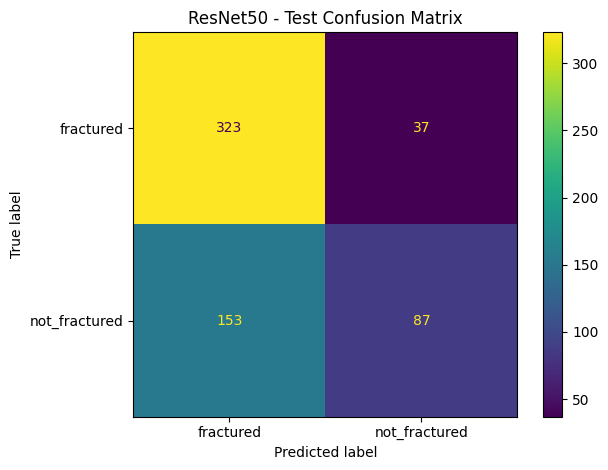


Final Test Metrics
----------------------------------------
Accuracy : 0.6833
Precision: 0.6786
Recall   : 0.8972
F1       : 0.7727
ROC-AUC  : 0.7693


FINAL TESTING: DenseNet121

Model loaded: DenseNet121

Generating predictions...
19/19 ━━━━━━━━━━━━━━━━━━━━ 28s 921ms/step

Number of test samples: 600

Classification Report:
               precision    recall  f1-score   support

    fractured       0.81      0.91      0.86       360
not_fractured       0.83      0.69      0.75       240

     accuracy                           0.82       600
    macro avg       0.82      0.80      0.80       600
 weighted avg       0.82      0.82      0.81       600

Confusion Matrix:
[[326  34]
 [ 75 165]]


<Figure size 600x500 with 0 Axes>

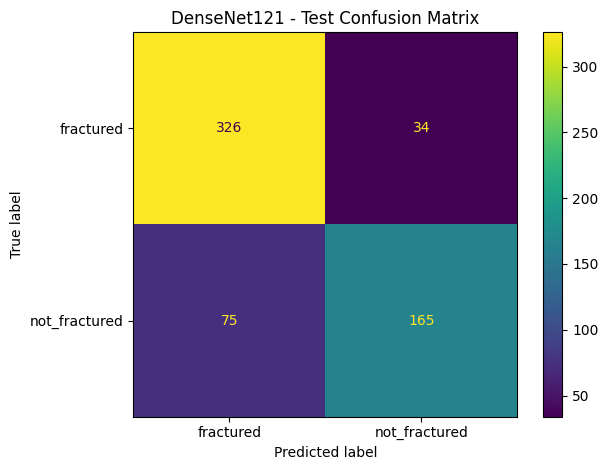


Final Test Metrics
----------------------------------------
Accuracy : 0.8183
Precision: 0.8130
Recall   : 0.9056
F1       : 0.8568
ROC-AUC  : 0.9192


FINAL TESTING: EfficientNetB0

Model loaded: EfficientNetB0

Generating predictions...
18/19 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step

2026-10-02 20:21:00.100725: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-02 20:21:00.242423: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-02 20:21:00.576956: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-02 20:21:00.718701: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-02 20:21:00.859541: E external/local_xla/xla/stream_

19/19 ━━━━━━━━━━━━━━━━━━━━ 21s 784ms/step

Number of test samples: 600

Classification Report:
               precision    recall  f1-score   support

    fractured       0.79      0.79      0.79       360
not_fractured       0.69      0.69      0.69       240

     accuracy                           0.75       600
    macro avg       0.74      0.74      0.74       600
 weighted avg       0.75      0.75      0.75       600

Confusion Matrix:
[[285  75]
 [ 74 166]]


<Figure size 600x500 with 0 Axes>

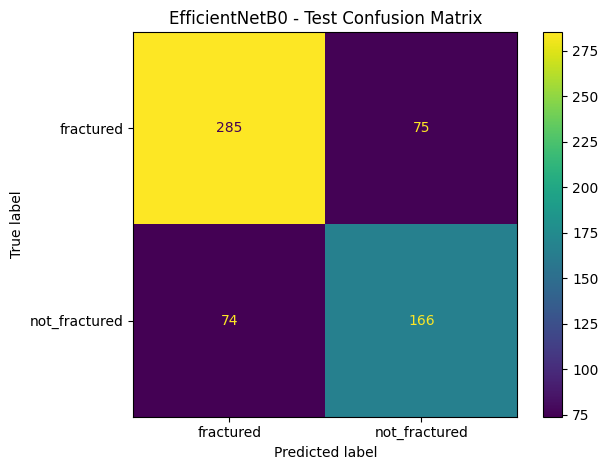


Final Test Metrics
----------------------------------------
Accuracy : 0.7517
Precision: 0.7939
Recall   : 0.7917
F1       : 0.7928
ROC-AUC  : 0.8247


FINAL TESTING: VGG16

Model loaded: VGG16

Generating predictions...
19/19 ━━━━━━━━━━━━━━━━━━━━ 14s 697ms/step

Number of test samples: 600

Classification Report:
               precision    recall  f1-score   support

    fractured       0.78      0.73      0.75       360
not_fractured       0.63      0.68      0.65       240

     accuracy                           0.71       600
    macro avg       0.70      0.71      0.70       600
 weighted avg       0.72      0.71      0.71       600

Confusion Matrix:
[[262  98]
 [ 76 164]]


<Figure size 600x500 with 0 Axes>

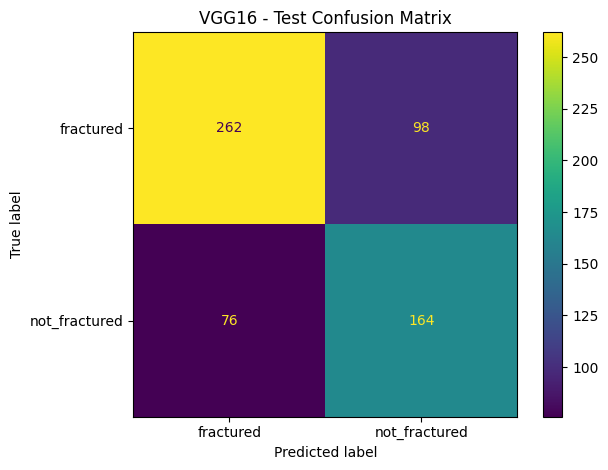


Final Test Metrics
----------------------------------------
Accuracy : 0.7100
Precision: 0.7751
Recall   : 0.7278
F1       : 0.7507
ROC-AUC  : 0.7733


FINAL TESTING: MobileNetV2

Model loaded: MobileNetV2

Generating predictions...
18/19 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step

2026-10-02 20:21:32.150735: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-02 20:21:32.287195: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


19/19 ━━━━━━━━━━━━━━━━━━━━ 15s 602ms/step

Number of test samples: 600

Classification Report:
               precision    recall  f1-score   support

    fractured       0.74      0.94      0.82       360
not_fractured       0.84      0.50      0.63       240

     accuracy                           0.76       600
    macro avg       0.79      0.72      0.73       600
 weighted avg       0.78      0.76      0.75       600

Confusion Matrix:
[[337  23]
 [120 120]]


<Figure size 600x500 with 0 Axes>

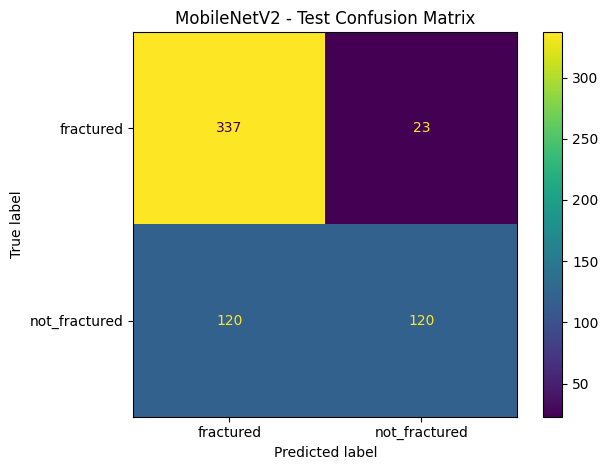


Final Test Metrics
----------------------------------------
Accuracy : 0.7617
Precision: 0.7374
Recall   : 0.9361
F1       : 0.8250
ROC-AUC  : 0.8828

[7/13] Creating model comparison table...


FINAL MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,DenseNet121,0.818333,0.812968,0.905556,0.856767,0.919178
1,MobileNetV2,0.761667,0.737418,0.936111,0.824969,0.882789
2,EfficientNetB0,0.751667,0.793872,0.791667,0.792768,0.824688
3,ResNet50,0.683333,0.678571,0.897222,0.772727,0.769323
4,VGG16,0.710000,0.775148,0.727778,0.750716,0.773275



Comparison saved:
/kaggle/working/final_model_comparison.csv

[8/13] Creating comparison plots...


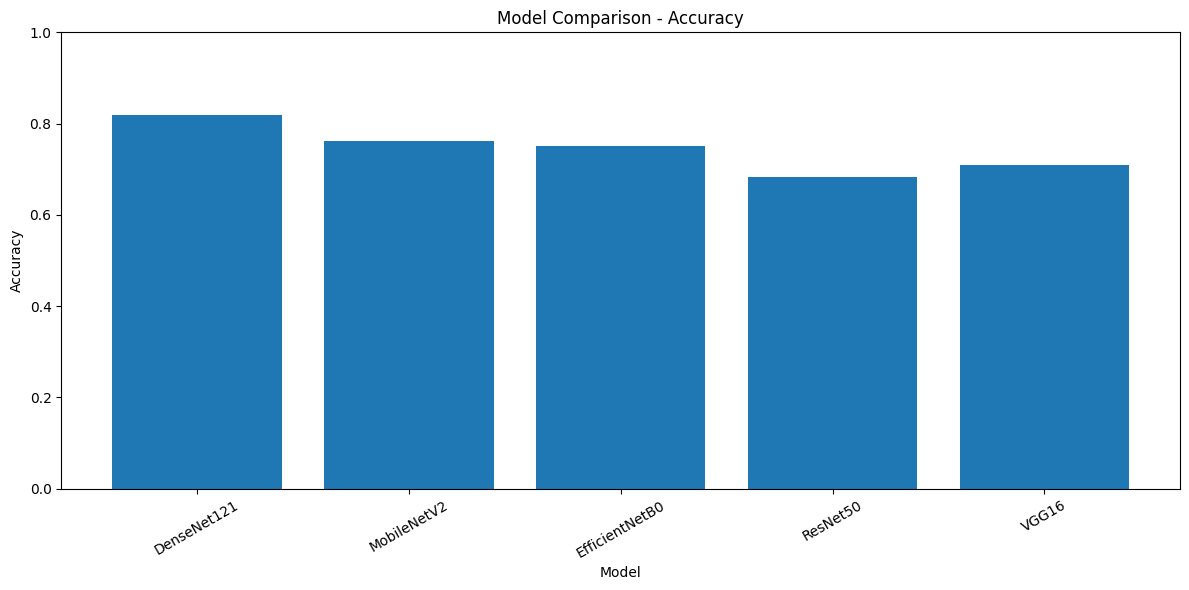

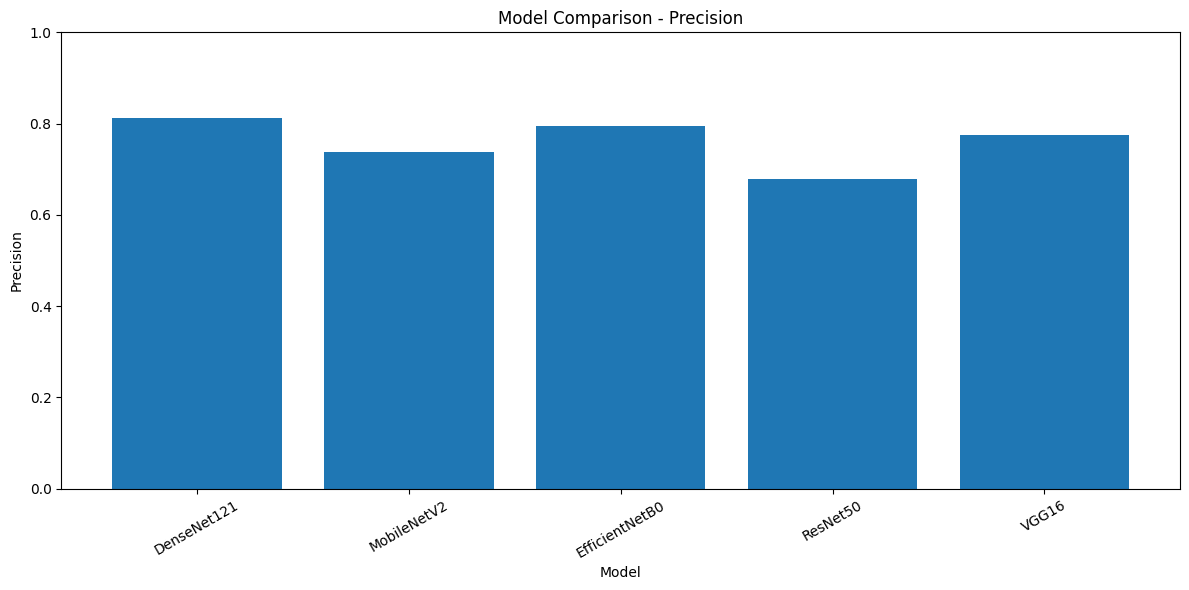

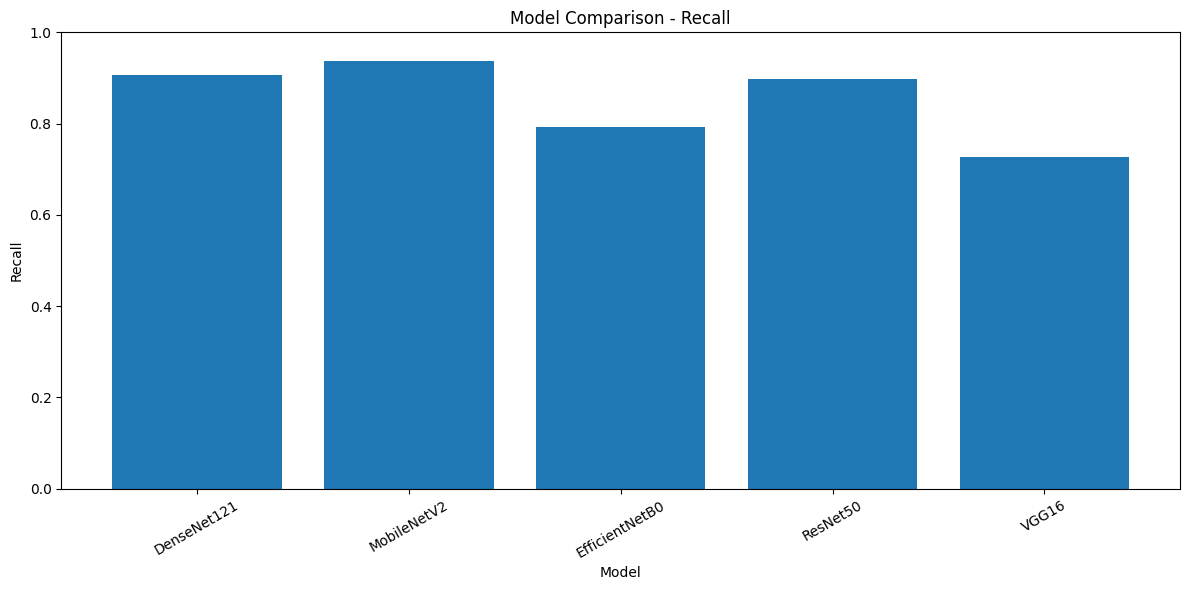

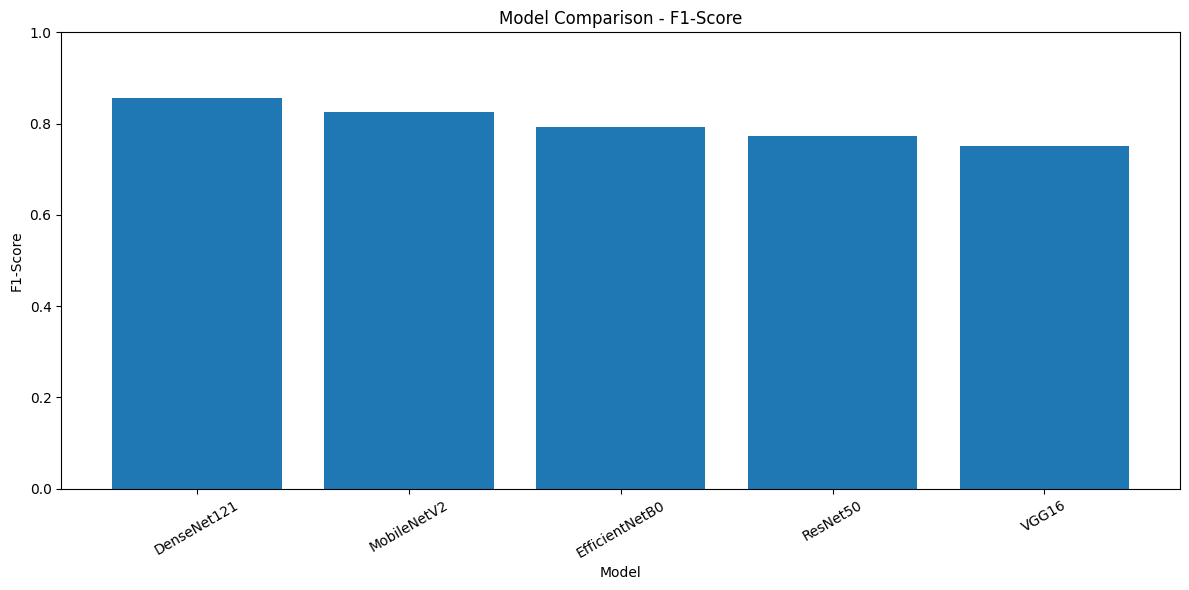

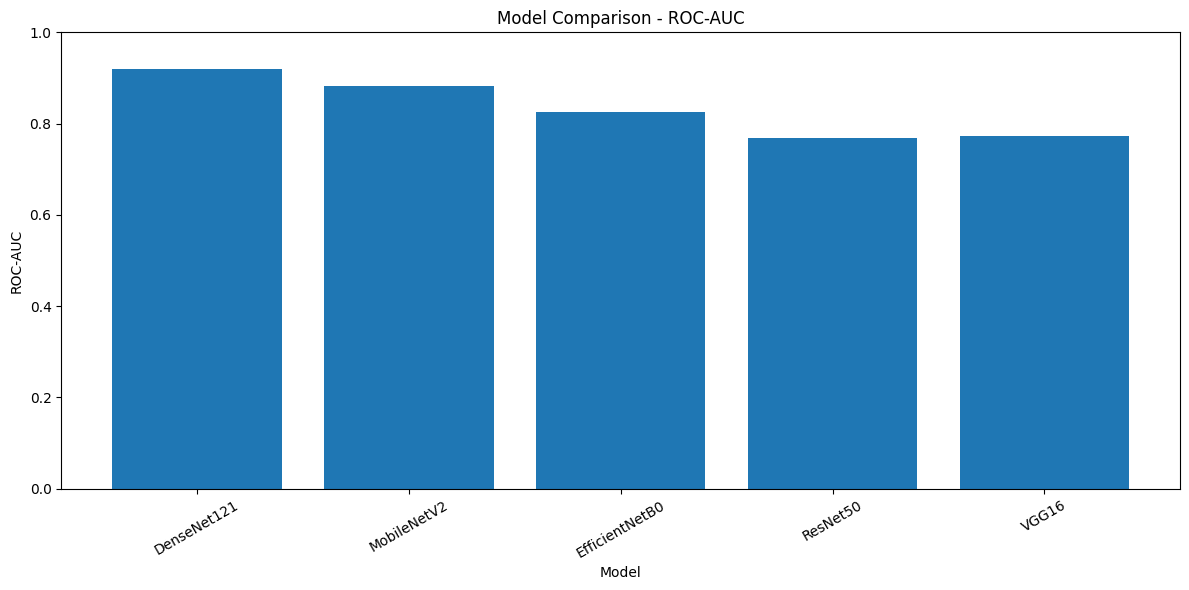


[9/13] Creating ROC curves...


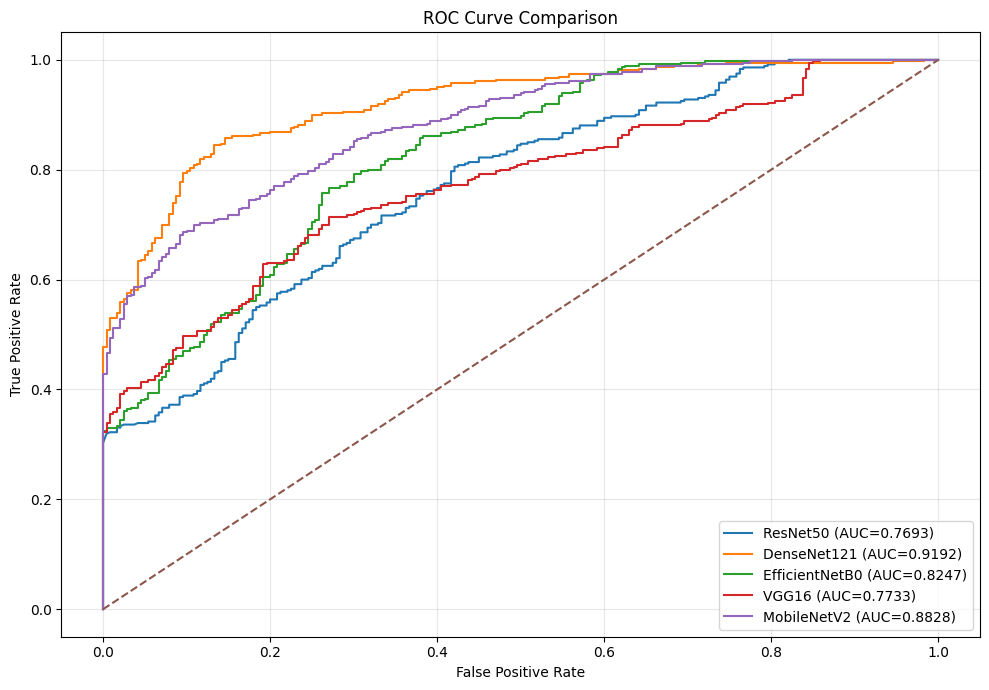


[10/13] Selecting best model...


SELECTED MODEL FOR FRONTEND

Model: DenseNet121
F1-Score: 0.8568

[11/13] Preparing best model...
Best model object ready.

Best model saved at:
/kaggle/working/best_bones_fracture_model.keras

Metadata saved at:
/kaggle/working/best_model_metadata.json

[12/13] Preparing Grad-CAM...

Last Conv2D layer found:
conv5_block16_2_conv

Generating Grad-CAM sample...


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_image']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)



Grad-CAM generation failed.
Reason: "Exception encountered when calling Functional.call().\n\n\x1b139389410093552\x1b\n\nArguments received by Functional.call():\n  • inputs=array([[[[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n        [[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n        [[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n        ...,\n\n        [[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n        [[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,DenseNet121,0.818333,0.812968,0.905556,0.856767,0.919178
1,MobileNetV2,0.761667,0.737418,0.936111,0.824969,0.882789
2,EfficientNetB0,0.751667,0.793872,0.791667,0.792768,0.824688
3,ResNet50,0.683333,0.678571,0.897222,0.772727,0.769323
4,VGG16,0.710000,0.775148,0.727778,0.750716,0.773275


In [5]:
# ============================================================
# MODULE 5
# FINAL TESTING
# METRICS
# CONFUSION MATRIX
# ROC-AUC
# MODEL COMPARISON
# ROBUST GRAD-CAM
# BEST MODEL EXPORT
# FRONTEND READY
# ============================================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

print("=" * 80)
print("MODULE 5 - FINAL TESTING & MODEL SELECTION")
print("=" * 80)


# ============================================================
# 1. BASIC CHECKS
# ============================================================

print("\n[1/13] Checking required variables...")

required_variables = [
    "MODEL_NAMES",
    "test_generator"
]

missing_variables = []

for var in required_variables:
    if var not in globals():
        missing_variables.append(var)

if len(missing_variables) > 0:
    raise RuntimeError(
        f"Missing variables: {missing_variables}\n"
        "Please run Modules 1-4 before running Module 5."
    )

print("✓ Required variables found")


# ============================================================
# 2. GET CLASS INFORMATION SAFELY
# ============================================================

print("\n[2/13] Reading class information...")


# ------------------------------------------------------------
# Prefer class information directly from test generator
# ------------------------------------------------------------

if hasattr(test_generator, "class_indices"):

    generator_class_indices = test_generator.class_indices

else:

    raise RuntimeError(
        "test_generator does not contain class_indices."
    )


# ------------------------------------------------------------
# Class names
# ------------------------------------------------------------

classes = list(generator_class_indices.keys())

# Sort according to class index
classes = sorted(
    classes,
    key=lambda x: generator_class_indices[x]
)


# ------------------------------------------------------------
# Class mapping
# ------------------------------------------------------------

class_to_index = {
    class_name: int(generator_class_indices[class_name])
    for class_name in classes
}

index_to_class = {
    index: class_name
    for class_name, index in class_to_index.items()
}


print("\nClasses:")
for class_name, index in class_to_index.items():
    print(f"  {index}: {class_name}")


# ------------------------------------------------------------
# Binary classification check
# ------------------------------------------------------------

if len(classes) != 2:

    raise ValueError(
        f"This Module 5 is configured for binary classification, "
        f"but {len(classes)} classes were found: {classes}"
    )


# ============================================================
# 3. IMPORTANT: TEST GENERATOR SETTINGS
# ============================================================

print("\n[3/13] Checking test generator...")


# ------------------------------------------------------------
# Make sure test data is NOT shuffled
# ------------------------------------------------------------

if hasattr(test_generator, "shuffle"):

    print(
        "Test generator shuffle:",
        test_generator.shuffle
    )

    if test_generator.shuffle:

        print(
            "\nWARNING: test_generator.shuffle is True."
        )

        print(
            "For final testing, the generator should ideally use:"
        )

        print(
            "shuffle=False"
        )

        print(
            "\nIf possible, recreate test_generator with shuffle=False."
        )


# ------------------------------------------------------------
# Test sample count
# ------------------------------------------------------------

print(
    "Test samples:",
    test_generator.samples
)


# ============================================================
# 4. SELECT MODELS
# ============================================================

print("\n[4/13] Selecting models for final testing...")


# ------------------------------------------------------------
# Prefer Stage 2 fine-tuned models if available
# ------------------------------------------------------------

if "stage2_models" in globals():

    MODEL_SOURCE = stage2_models

    print("✓ Using Stage 2 fine-tuned models")

elif "stage1_models" in globals():

    MODEL_SOURCE = stage1_models

    print(
        "✓ Stage 2 models not found."
    )

    print(
        "✓ Using Stage 1 models instead."
    )

else:

    raise RuntimeError(
        "Neither stage2_models nor stage1_models was found."
    )


# ------------------------------------------------------------
# Keep only models that actually exist
# ------------------------------------------------------------

available_models = []

for model_name in MODEL_NAMES:

    if model_name in MODEL_SOURCE:

        available_models.append(model_name)

    else:

        print(
            f"WARNING: {model_name} not found. Skipping."
        )


if len(available_models) == 0:

    raise RuntimeError(
        "No trained models were found."
    )


print("\nModels to evaluate:")

for model_name in available_models:

    print(
        " ✓",
        model_name
    )


# ============================================================
# 5. RESULTS STORAGE
# ============================================================

print("\n[5/13] Initializing result storage...")


all_results = {}

all_predictions = {}


# ============================================================
# 6. HELPER FUNCTION - SAFE BINARY LABELS
# ============================================================

def make_binary_labels(true_labels, positive_index):

    """
    Convert labels into a guaranteed NumPy binary array.

    This fixes the original:
        AttributeError: 'bool' object has no attribute 'astype'
    """

    # Force NumPy array
    true_labels = np.asarray(
        true_labels
    ).reshape(-1)

    # Element-wise comparison
    binary_labels = np.equal(
        true_labels,
        int(positive_index)
    )

    # Convert bool array -> integer array
    binary_labels = binary_labels.astype(
        np.int32
    )

    return binary_labels


# ============================================================
# 7. IDENTIFY POSITIVE CLASS
# ============================================================

# ------------------------------------------------------------
# We do NOT hard-code "fractured".
# We first look for "fracture/fractured" if present.
# Otherwise use class index 1.
# ------------------------------------------------------------

fracture_candidates = []

for class_name in classes:

    class_lower = class_name.lower()

    if (
        "fracture" in class_lower
        or
        "fractured" in class_lower
    ):

        fracture_candidates.append(
            class_name
        )


if len(fracture_candidates) > 0:

    positive_class_name = fracture_candidates[0]

else:

    # Binary fallback
    positive_class_name = classes[1]


positive_class_index = class_to_index[
    positive_class_name
]


print("\nPositive class for Precision/Recall/ROC-AUC:")
print(
    f"  {positive_class_name} -> "
    f"index {positive_class_index}"
)


# ============================================================
# 8. FINAL TESTING OF EVERY MODEL
# ============================================================

print("\n[6/13] Starting final testing...")


for model_name in available_models:

    print("\n")
    print("=" * 80)
    print(
        f"FINAL TESTING: {model_name}"
    )
    print("=" * 80)


    # --------------------------------------------------------
    # Get model
    # --------------------------------------------------------

    model_entry = MODEL_SOURCE[
        model_name
    ]


    # --------------------------------------------------------
    # Support different dictionary structures
    # --------------------------------------------------------

    if isinstance(
        model_entry,
        dict
    ):

        model = model_entry[
            "model"
        ]

    else:

        model = model_entry


    print(
        "\nModel loaded:",
        model_name
    )


    # --------------------------------------------------------
    # Reset test generator
    # --------------------------------------------------------

    test_generator.reset()


    # --------------------------------------------------------
    # Predictions
    # --------------------------------------------------------

    print(
        "\nGenerating predictions..."
    )


    probabilities = model.predict(
        test_generator,
        verbose=1
    )


    # --------------------------------------------------------
    # Convert to NumPy array
    # --------------------------------------------------------

    probabilities = np.asarray(
        probabilities
    )


    # --------------------------------------------------------
    # Make sure predictions are correct shape
    # --------------------------------------------------------

    if probabilities.ndim != 2:

        raise ValueError(
            f"Unexpected prediction shape: "
            f"{probabilities.shape}"
        )


    if probabilities.shape[1] != len(classes):

        raise ValueError(
            f"Model output has "
            f"{probabilities.shape[1]} classes, "
            f"but dataset has "
            f"{len(classes)} classes."
        )


    # --------------------------------------------------------
    # Predicted class
    # --------------------------------------------------------

    predictions = np.argmax(
        probabilities,
        axis=1
    )


    # ========================================================
    # TRUE LABELS - IMPORTANT FIX
    # ========================================================

    true_labels = np.asarray(
        test_generator.classes
    ).reshape(-1)


    # --------------------------------------------------------
    # Safety check
    # --------------------------------------------------------

    if len(true_labels) != len(predictions):

        raise ValueError(
            "Number of true labels and predictions "
            "does not match.\n"
            f"True labels: {len(true_labels)}\n"
            f"Predictions: {len(predictions)}"
        )


    print(
        "\nNumber of test samples:",
        len(true_labels)
    )


    # ========================================================
    # METRICS
    # ========================================================

    # --------------------------------------------------------
    # Accuracy
    # --------------------------------------------------------

    accuracy = accuracy_score(
        true_labels,
        predictions
    )


    # --------------------------------------------------------
    # Precision
    # --------------------------------------------------------

    precision = precision_score(
        true_labels,
        predictions,
        average="binary",
        pos_label=positive_class_index,
        zero_division=0
    )


    # --------------------------------------------------------
    # Recall
    # --------------------------------------------------------

    recall = recall_score(
        true_labels,
        predictions,
        average="binary",
        pos_label=positive_class_index,
        zero_division=0
    )


    # --------------------------------------------------------
    # F1
    # --------------------------------------------------------

    f1 = f1_score(
        true_labels,
        predictions,
        average="binary",
        pos_label=positive_class_index,
        zero_division=0
    )


    # ========================================================
    # ROC-AUC - FIXED
    # ========================================================

    y_true_binary = make_binary_labels(
        true_labels,
        positive_class_index
    )


    y_probability = np.asarray(
        probabilities[
            :,
            positive_class_index
        ]
    ).reshape(-1)


    # --------------------------------------------------------
    # Check both classes exist
    # --------------------------------------------------------

    unique_binary_labels = np.unique(
        y_true_binary
    )


    if len(unique_binary_labels) == 2:

        auc_score = roc_auc_score(
            y_true_binary,
            y_probability
        )

    else:

        auc_score = np.nan

        print(
            "\nWARNING: ROC-AUC could not be calculated "
            "because only one class is present."
        )


    # ========================================================
    # STORE RESULTS
    # ========================================================

    all_results[
        model_name
    ] = {

        "Model": model_name,

        "Accuracy": float(
            accuracy
        ),

        "Precision": float(
            precision
        ),

        "Recall": float(
            recall
        ),

        "F1-Score": float(
            f1
        ),

        "ROC-AUC": (
            float(auc_score)
            if not np.isnan(auc_score)
            else np.nan
        )
    }


    # --------------------------------------------------------
    # Store predictions
    # --------------------------------------------------------

    all_predictions[
        model_name
    ] = {

        "probabilities":
            probabilities,

        "predictions":
            predictions,

        "true_labels":
            true_labels
    }


    # ========================================================
    # CLASSIFICATION REPORT
    # ========================================================

    print(
        "\nClassification Report:"
    )


    print(
        classification_report(

            true_labels,

            predictions,

            labels=np.arange(
                len(classes)
            ),

            target_names=classes,

            zero_division=0
        )
    )


    # ========================================================
    # CONFUSION MATRIX
    # ========================================================

    cm = confusion_matrix(

        true_labels,

        predictions,

        labels=np.arange(
            len(classes)
        )
    )


    print(
        "Confusion Matrix:"
    )

    print(cm)


    plt.figure(
        figsize=(6, 5)
    )


    disp = ConfusionMatrixDisplay(

        confusion_matrix=cm,

        display_labels=classes

    )


    disp.plot(
        values_format="d"
    )


    plt.title(
        f"{model_name} - Test Confusion Matrix"
    )


    plt.tight_layout()

    plt.show()


    # ========================================================
    # PRINT METRICS
    # ========================================================

    print(
        "\nFinal Test Metrics"
    )

    print(
        "-" * 40
    )

    print(
        f"Accuracy : {accuracy:.4f}"
    )

    print(
        f"Precision: {precision:.4f}"
    )

    print(
        f"Recall   : {recall:.4f}"
    )

    print(
        f"F1       : {f1:.4f}"
    )

    if not np.isnan(auc_score):

        print(
            f"ROC-AUC  : {auc_score:.4f}"
        )

    else:

        print(
            "ROC-AUC  : N/A"
        )


# ============================================================
# 9. CREATE COMPARISON TABLE
# ============================================================

print("\n[7/13] Creating model comparison table...")


results_df = pd.DataFrame(
    list(all_results.values())
)


# ------------------------------------------------------------
# Sort by F1 score
# ------------------------------------------------------------

results_df = results_df.sort_values(

    by="F1-Score",

    ascending=False

).reset_index(
    drop=True
)


print("\n")
print("=" * 80)
print("FINAL MODEL COMPARISON")
print("=" * 80)


display(
    results_df
)


# ============================================================
# 10. SAVE COMPARISON RESULTS
# ============================================================

comparison_path = (
    "/kaggle/working/"
    "final_model_comparison.csv"
)


results_df.to_csv(

    comparison_path,

    index=False
)


print(
    "\nComparison saved:"
)

print(
    comparison_path
)


# ============================================================
# 11. MODEL COMPARISON PLOTS
# ============================================================

print("\n[8/13] Creating comparison plots...")


metrics_to_plot = [

    "Accuracy",

    "Precision",

    "Recall",

    "F1-Score",

    "ROC-AUC"

]


for metric in metrics_to_plot:

    plt.figure(
        figsize=(12, 6)
    )


    # --------------------------------------------------------
    # Remove NaN values for plotting
    # --------------------------------------------------------

    plot_df = results_df[
        [
            "Model",
            metric
        ]
    ].dropna()


    plt.bar(

        plot_df["Model"],

        plot_df[metric]

    )


    plt.title(
        f"Model Comparison - {metric}"
    )


    plt.xlabel(
        "Model"
    )


    plt.ylabel(
        metric
    )


    plt.ylim(
        0,
        1
    )


    plt.xticks(
        rotation=30
    )


    plt.tight_layout()

    plt.show()


# ============================================================
# 12. ROC CURVE COMPARISON
# ============================================================

print("\n[9/13] Creating ROC curves...")


plt.figure(
    figsize=(10, 7)
)


for model_name in available_models:

    data = all_predictions[
        model_name
    ]


    true_labels = np.asarray(
        data["true_labels"]
    ).reshape(-1)


    probabilities = np.asarray(
        data["probabilities"]
    )


    # --------------------------------------------------------
    # IMPORTANT FIX:
    # Force true_labels to NumPy array before comparison
    # --------------------------------------------------------

    y_true_binary = make_binary_labels(

        true_labels,

        positive_class_index

    )


    y_probability = np.asarray(

        probabilities[
            :,
            positive_class_index
        ]

    ).reshape(-1)


    # --------------------------------------------------------
    # ROC only if both classes exist
    # --------------------------------------------------------

    if len(
        np.unique(
            y_true_binary
        )
    ) < 2:

        print(
            f"Skipping ROC for {model_name}: "
            "only one class is present."
        )

        continue


    fpr, tpr, _ = roc_curve(

        y_true_binary,

        y_probability

    )


    auc_value = roc_auc_score(

        y_true_binary,

        y_probability

    )


    plt.plot(

        fpr,

        tpr,

        label=(
            f"{model_name} "
            f"(AUC={auc_value:.4f})"
        )

    )


# ------------------------------------------------------------
# Random classifier line
# ------------------------------------------------------------

plt.plot(

    [0, 1],

    [0, 1],

    linestyle="--"

)


plt.xlabel(
    "False Positive Rate"
)


plt.ylabel(
    "True Positive Rate"
)


plt.title(
    "ROC Curve Comparison"
)


plt.legend()


plt.grid(
    alpha=0.3
)


plt.tight_layout()

plt.show()


# ============================================================
# 13. SELECT BEST MODEL
# ============================================================

print("\n[10/13] Selecting best model...")


# ------------------------------------------------------------
# Select according to F1
# ------------------------------------------------------------

best_model_name = results_df.iloc[0][
    "Model"
]


best_f1 = results_df.iloc[0][
    "F1-Score"
]


print("\n")
print("=" * 80)

print(
    "SELECTED MODEL FOR FRONTEND"
)

print("=" * 80)


print(
    "\nModel:",
    best_model_name
)


print(
    f"F1-Score: {best_f1:.4f}"
)


# ============================================================
# 14. GET BEST MODEL
# ============================================================

print("\n[11/13] Preparing best model...")


best_entry = MODEL_SOURCE[
    best_model_name
]


if isinstance(
    best_entry,
    dict
):

    best_model = best_entry[
        "model"
    ]

else:

    best_model = best_entry


print(
    "Best model object ready."
)


# ============================================================
# 15. SAVE BEST MODEL
# ============================================================

BEST_MODEL_PATH = (

    "/kaggle/working/"
    "best_bones_fracture_model.keras"

)


best_model.save(
    BEST_MODEL_PATH
)


print(
    "\nBest model saved at:"
)

print(
    BEST_MODEL_PATH
)


# ============================================================
# 16. SAVE MODEL METADATA
# ============================================================

metadata = {

    "model_name":
        str(best_model_name),

    "image_size":
        [224, 224],

    "classes":
        classes,

    "class_mapping":
        class_to_index,

    "positive_class":
        positive_class_name,

    "positive_class_index":
        int(positive_class_index),

    "input_channels":
        3,

    "model_file":
        "best_bones_fracture_model.keras",

    "selection_metric":
        "F1-Score",

    "best_f1_score":
        float(best_f1)

}


metadata_path = (

    "/kaggle/working/"
    "best_model_metadata.json"

)


with open(

    metadata_path,

    "w"

) as file:

    json.dump(

        metadata,

        file,

        indent=4

    )


print(
    "\nMetadata saved at:"
)

print(
    metadata_path
)


# ============================================================
# 17. ROBUST GRAD-CAM
# ============================================================

print("\n[12/13] Preparing Grad-CAM...")


# ------------------------------------------------------------
# Find Conv2D layer recursively
# ------------------------------------------------------------

def find_last_conv_layer_recursive(
    model
):

    """
    Finds the last Conv2D layer.

    Works with models where the CNN backbone is nested,
    e.g. ResNet50, DenseNet121, VGG16, MobileNetV2,
    EfficientNetB0.
    """

    # --------------------------------------------------------
    # First search direct layers in reverse order
    # --------------------------------------------------------

    for layer in reversed(
        model.layers
    ):

        # Direct Conv2D
        if isinstance(
            layer,
            tf.keras.layers.Conv2D
        ):

            return layer


    # --------------------------------------------------------
    # Then search nested models
    # --------------------------------------------------------

    for layer in reversed(
        model.layers
    ):

        if isinstance(
            layer,
            tf.keras.Model
        ):

            try:

                nested_conv = (
                    find_last_conv_layer_recursive(
                        layer
                    )
                )

                if nested_conv is not None:

                    return nested_conv

            except Exception:

                continue


    return None


# ------------------------------------------------------------
# Locate last convolutional layer
# ------------------------------------------------------------

last_conv_layer = (
    find_last_conv_layer_recursive(
        best_model
    )
)


if last_conv_layer is None:

    print(
        "\nWARNING:"
    )

    print(
        "Could not automatically find a Conv2D layer."
    )

    print(
        "Grad-CAM will be skipped."
    )

else:

    print(
        "\nLast Conv2D layer found:"
    )

    print(
        last_conv_layer.name
    )


# ============================================================
# GRAD-CAM FUNCTION
# ============================================================

def make_gradcam_heatmap(

    image_array,

    model,

    target_class=None,

    conv_layer=None

):

    """
    Generate Grad-CAM heatmap.

    Parameters
    ----------
    image_array:
        Image with shape (1, H, W, 3)

    model:
        Trained Keras model

    target_class:
        Class index

    conv_layer:
        Actual Conv2D layer object
    """

    if conv_layer is None:

        conv_layer = (
            find_last_conv_layer_recursive(
                model
            )
        )


    if conv_layer is None:

        raise ValueError(
            "No Conv2D layer found for Grad-CAM."
        )


    # --------------------------------------------------------
    # Create gradient model
    # --------------------------------------------------------

    grad_model = tf.keras.models.Model(

        inputs=model.inputs,

        outputs=[
            conv_layer.output,
            model.output
        ]

    )


    # --------------------------------------------------------
    # Forward pass + gradient
    # --------------------------------------------------------

    with tf.GradientTape() as tape:

        conv_outputs, predictions = (
            grad_model(
                image_array,
                training=False
            )
        )


        # ----------------------------------------------------
        # Automatically select predicted class
        # ----------------------------------------------------

        if target_class is None:

            target_class = tf.argmax(

                predictions[0]

            )


        target_class = tf.cast(

            target_class,

            tf.int32

        )


        class_score = predictions[
            0,
            target_class
        ]


    # --------------------------------------------------------
    # Gradients
    # --------------------------------------------------------

    gradients = tape.gradient(

        class_score,

        conv_outputs

    )


    if gradients is None:

        raise ValueError(
            "Gradients are None. "
            "Grad-CAM could not be generated."
        )


    # --------------------------------------------------------
    # Global average pooling
    # --------------------------------------------------------

    pooled_gradients = tf.reduce_mean(

        gradients,

        axis=(0, 1, 2)

    )


    # --------------------------------------------------------
    # Remove batch dimension
    # --------------------------------------------------------

    conv_outputs = conv_outputs[0]


    # --------------------------------------------------------
    # Weighted feature maps
    # --------------------------------------------------------

    heatmap = tf.reduce_sum(

        conv_outputs *
        pooled_gradients,

        axis=-1

    )


    # --------------------------------------------------------
    # ReLU
    # --------------------------------------------------------

    heatmap = tf.maximum(

        heatmap,

        0

    )


    # --------------------------------------------------------
    # Normalize
    # --------------------------------------------------------

    max_value = tf.reduce_max(
        heatmap
    )


    heatmap = tf.where(

        max_value > 0,

        heatmap / (
            max_value + 1e-8
        ),

        tf.zeros_like(
            heatmap
        )

    )


    return heatmap.numpy()


# ============================================================
# 18. GENERATE GRAD-CAM SAMPLE
# ============================================================

if last_conv_layer is not None:

    print(
        "\nGenerating Grad-CAM sample..."
    )


    # --------------------------------------------------------
    # Reset generator
    # --------------------------------------------------------

    test_generator.reset()


    # --------------------------------------------------------
    # Get first batch
    # --------------------------------------------------------

    sample_images, sample_labels = (
        next(test_generator)
    )


    # --------------------------------------------------------
    # Select first image
    # --------------------------------------------------------

    sample_index = 0


    sample_image = (
        sample_images[
            sample_index
        ]
    )


    # --------------------------------------------------------
    # True class
    # --------------------------------------------------------

    if np.ndim(
        sample_labels[
            sample_index
        ]
    ) > 0:

        true_class = int(
            np.argmax(
                sample_labels[
                    sample_index
                ]
            )
        )

    else:

        true_class = int(
            sample_labels[
                sample_index
            ]
        )


    # --------------------------------------------------------
    # Add batch dimension
    # --------------------------------------------------------

    input_image = np.expand_dims(

        sample_image,

        axis=0

    )


    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------

    prediction = best_model.predict(

        input_image,

        verbose=0

    )


    predicted_class = int(

        np.argmax(
            prediction[0]
        )

    )


    confidence = float(

        prediction[
            0,
            predicted_class
        ]

    )


    # --------------------------------------------------------
    # Grad-CAM
    # --------------------------------------------------------

    try:

        heatmap = make_gradcam_heatmap(

            input_image,

            best_model,

            predicted_class,

            last_conv_layer

        )


        # ====================================================
        # DISPLAY
        # ====================================================

        plt.figure(
            figsize=(12, 5)
        )


        # ----------------------------------------------------
        # Original
        # ----------------------------------------------------

        plt.subplot(
            1,
            2,
            1
        )


        plt.imshow(
            sample_image
        )


        plt.title(

            "Original\n"
            f"True: {classes[true_class]}"

        )


        plt.axis(
            "off"
        )


        # ----------------------------------------------------
        # Grad-CAM
        # ----------------------------------------------------

        plt.subplot(
            1,
            2,
            2
        )


        plt.imshow(
            sample_image
        )


        plt.imshow(

            heatmap,

            cmap="jet",

            alpha=0.45,

            extent=(

                0,

                sample_image.shape[1],

                sample_image.shape[0],

                0

            )

        )


        plt.title(

            "Grad-CAM\n"
            f"Predicted: "
            f"{classes[predicted_class]}\n"
            f"Confidence: {confidence:.2%}"

        )


        plt.axis(
            "off"
        )


        plt.tight_layout()

        plt.show()


        # ----------------------------------------------------
        # Save Grad-CAM image
        # ----------------------------------------------------

        gradcam_path = (

            "/kaggle/working/"
            "best_model_gradcam.png"

        )


        plt.figure(
            figsize=(6, 6)
        )


        plt.imshow(
            sample_image
        )


        plt.imshow(

            heatmap,

            cmap="jet",

            alpha=0.45,

            extent=(

                0,

                sample_image.shape[1],

                sample_image.shape[0],

                0

            )

        )


        plt.axis(
            "off"
        )


        plt.tight_layout()


        plt.savefig(

            gradcam_path,

            dpi=300,

            bbox_inches="tight"

        )


        plt.close()


        print(
            "\nGrad-CAM saved:"
        )

        print(
            gradcam_path
        )


    except Exception as e:

        print(
            "\nGrad-CAM generation failed."
        )

        print(
            "Reason:",
            str(e)
        )


# ============================================================
# 19. FRONTEND READY FILES
# ============================================================

print("\n[13/13] Preparing final output summary...")


print("\n")
print("=" * 80)

print(
    "FRONTEND-READY FILES"
)

print("=" * 80)


print(
    "\n1. Best Model:"
)

print(
    BEST_MODEL_PATH
)


print(
    "\n2. Model Metadata:"
)

print(
    metadata_path
)


print(
    "\n3. Model Comparison:"
)

print(
    comparison_path
)


if last_conv_layer is not None:

    print(
        "\n4. Grad-CAM:"
    )

    print(
        "/kaggle/working/"
        "best_model_gradcam.png"
    )


print("\n")
print("=" * 80)

print(
    "MODULE 5 COMPLETED SUCCESSFULLY"
)

print("=" * 80)


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\nFINAL RESULTS:")
display(results_df)

# MODULE 6 — Complete XAI Pipeline



MODULE 6 - EXPLAINABLE AI

[1/15] Checking best model...
✓ Best model found.
/kaggle/working/best_bones_fracture_model.keras

[2/15] Loading model metadata...
✓ Metadata loaded.

[3/15] Detecting classes...

Detected classes:
  0 -> fractured
  1 -> not_fractured

[4/15] Loading best model...
Using custom preprocessing functions...

✓ Model loaded successfully.

Model name: DenseNet121
Input shape: (None, 224, 224, 3)
Output shape: (None, 2)

[5/15] Preparing image functions...

[6/15] Finding convolutional layer...

✓ Last Conv2D layer:
conv5_block16_2_conv

[7/15] Finding test images...
✓ Test images selected: 5

[8/15] Running XAI analysis...


XAI ANALYSIS: test_sample_1
True class: fractured
Predicted: fractured
Confidence: 88.00%

Class probabilities:
  fractured: 0.8800
  not_fractured: 0.1200

Generating Grad-CAM...
Grad-CAM error: "Exception encountered when calling Functional.call().\n\n\x1b139382133379376\x1b\n\nArguments received by Functional.call():\n  • inputs=tf.Tenso

  0%|          | 0/300 [00:00<?, ?it/s]

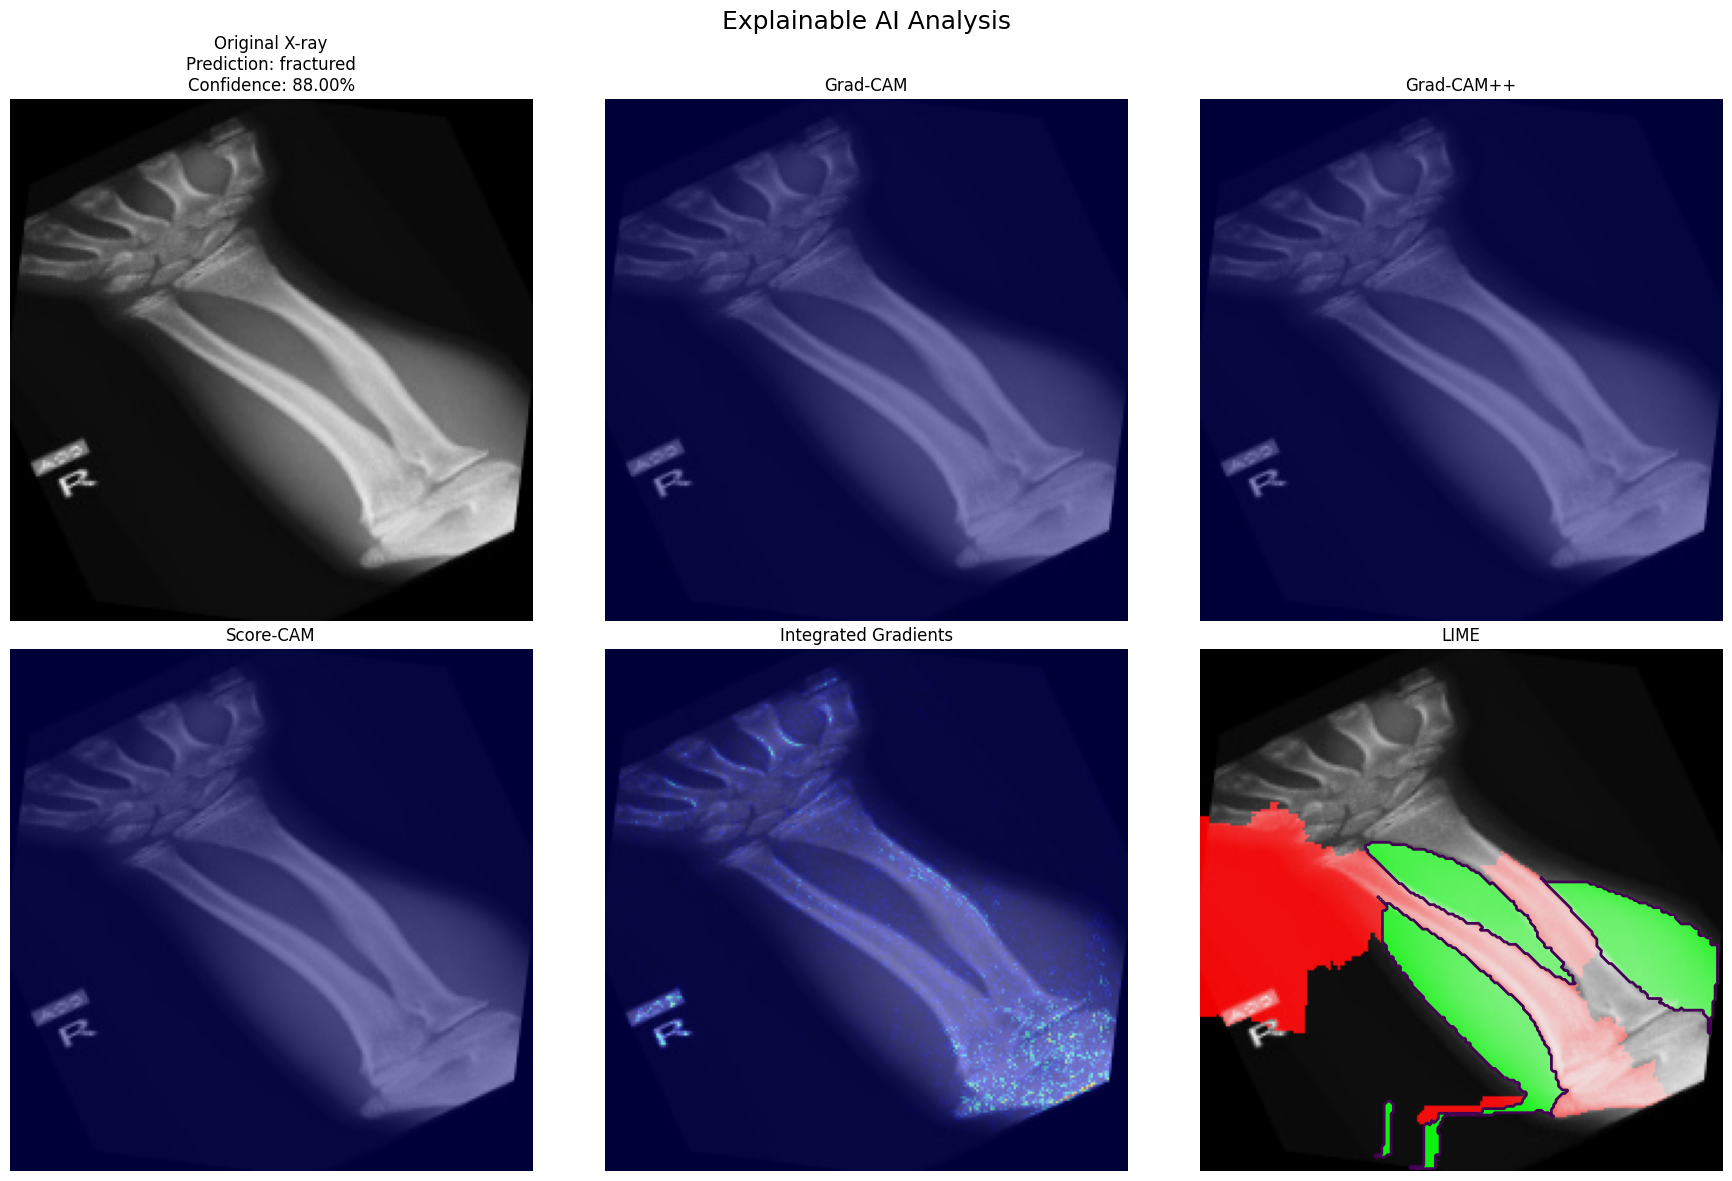


XAI visualization saved:
/kaggle/working/XAI_Results/test_sample_1_XAI.png


XAI ANALYSIS: test_sample_2
True class: not_fractured
Predicted: fractured
Confidence: 88.17%

Class probabilities:
  fractured: 0.8817
  not_fractured: 0.1183

Generating Grad-CAM...
Grad-CAM error: "Exception encountered when calling Functional.call().\n\n\x1b139382133379376\x1b\n\nArguments received by Functional.call():\n  • inputs=tf.Tensor(shape=(1, 224, 224, 3), dtype=float32)\n  • training=False\n  • mask=None\n  • kwargs=<class 'inspect._empty'>"
Generating Grad-CAM++...
Grad-CAM++ error: "Exception encountered when calling Functional.call().\n\n\x1b139382133379376\x1b\n\nArguments received by Functional.call():\n  • inputs=tf.Tensor(shape=(1, 224, 224, 3), dtype=float32)\n  • training=False\n  • mask=None\n  • kwargs=<class 'inspect._empty'>"
Generating Score-CAM...
Score-CAM error: "Exception encountered when calling Functional.call().\n\n\x1b139382133379376\x1b\n\nArguments received by Functional.

  0%|          | 0/300 [00:00<?, ?it/s]

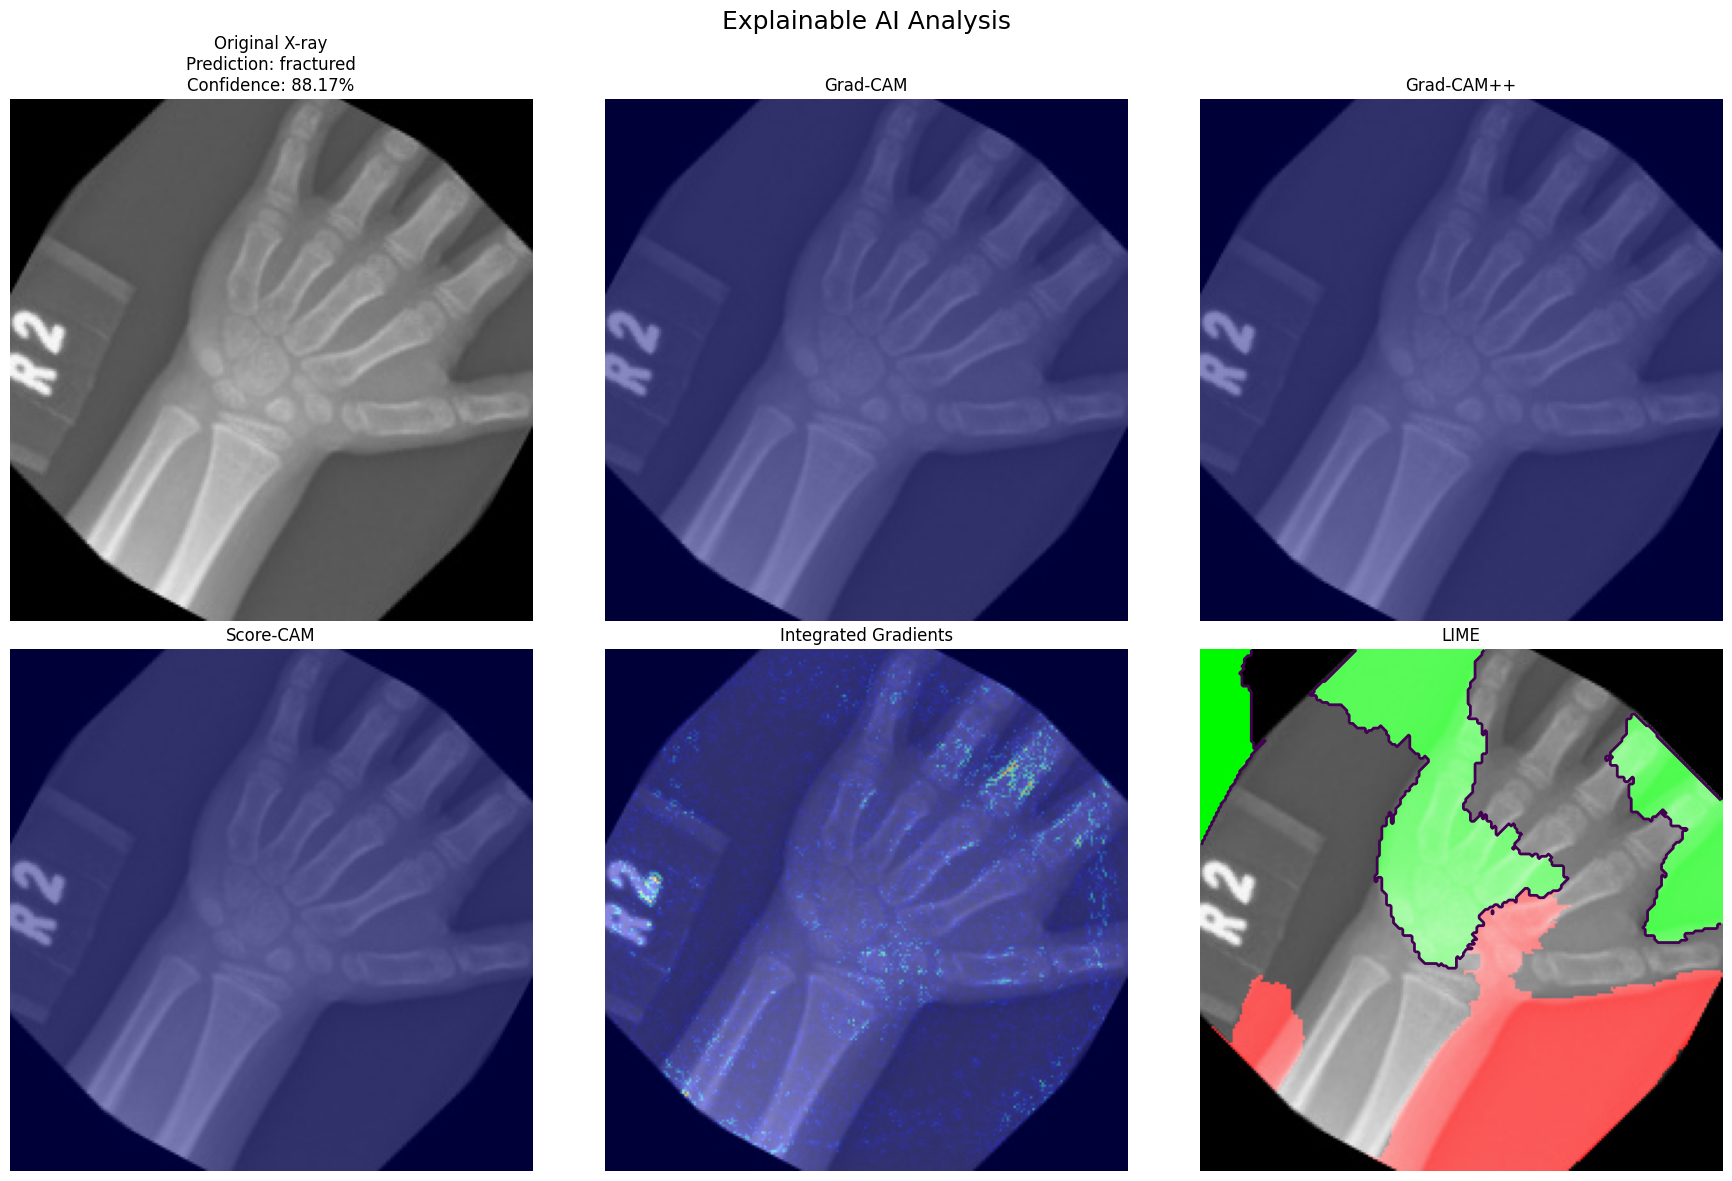


XAI visualization saved:
/kaggle/working/XAI_Results/test_sample_2_XAI.png


XAI ANALYSIS: test_sample_3
True class: not_fractured
Predicted: fractured
Confidence: 88.81%

Class probabilities:
  fractured: 0.8881
  not_fractured: 0.1119

Generating Grad-CAM...
Grad-CAM error: "Exception encountered when calling Functional.call().\n\n\x1b139382133379376\x1b\n\nArguments received by Functional.call():\n  • inputs=tf.Tensor(shape=(1, 224, 224, 3), dtype=float32)\n  • training=False\n  • mask=None\n  • kwargs=<class 'inspect._empty'>"
Generating Grad-CAM++...
Grad-CAM++ error: "Exception encountered when calling Functional.call().\n\n\x1b139382133379376\x1b\n\nArguments received by Functional.call():\n  • inputs=tf.Tensor(shape=(1, 224, 224, 3), dtype=float32)\n  • training=False\n  • mask=None\n  • kwargs=<class 'inspect._empty'>"
Generating Score-CAM...
Score-CAM error: "Exception encountered when calling Functional.call().\n\n\x1b139382133379376\x1b\n\nArguments received by Functional.

  0%|          | 0/300 [00:00<?, ?it/s]

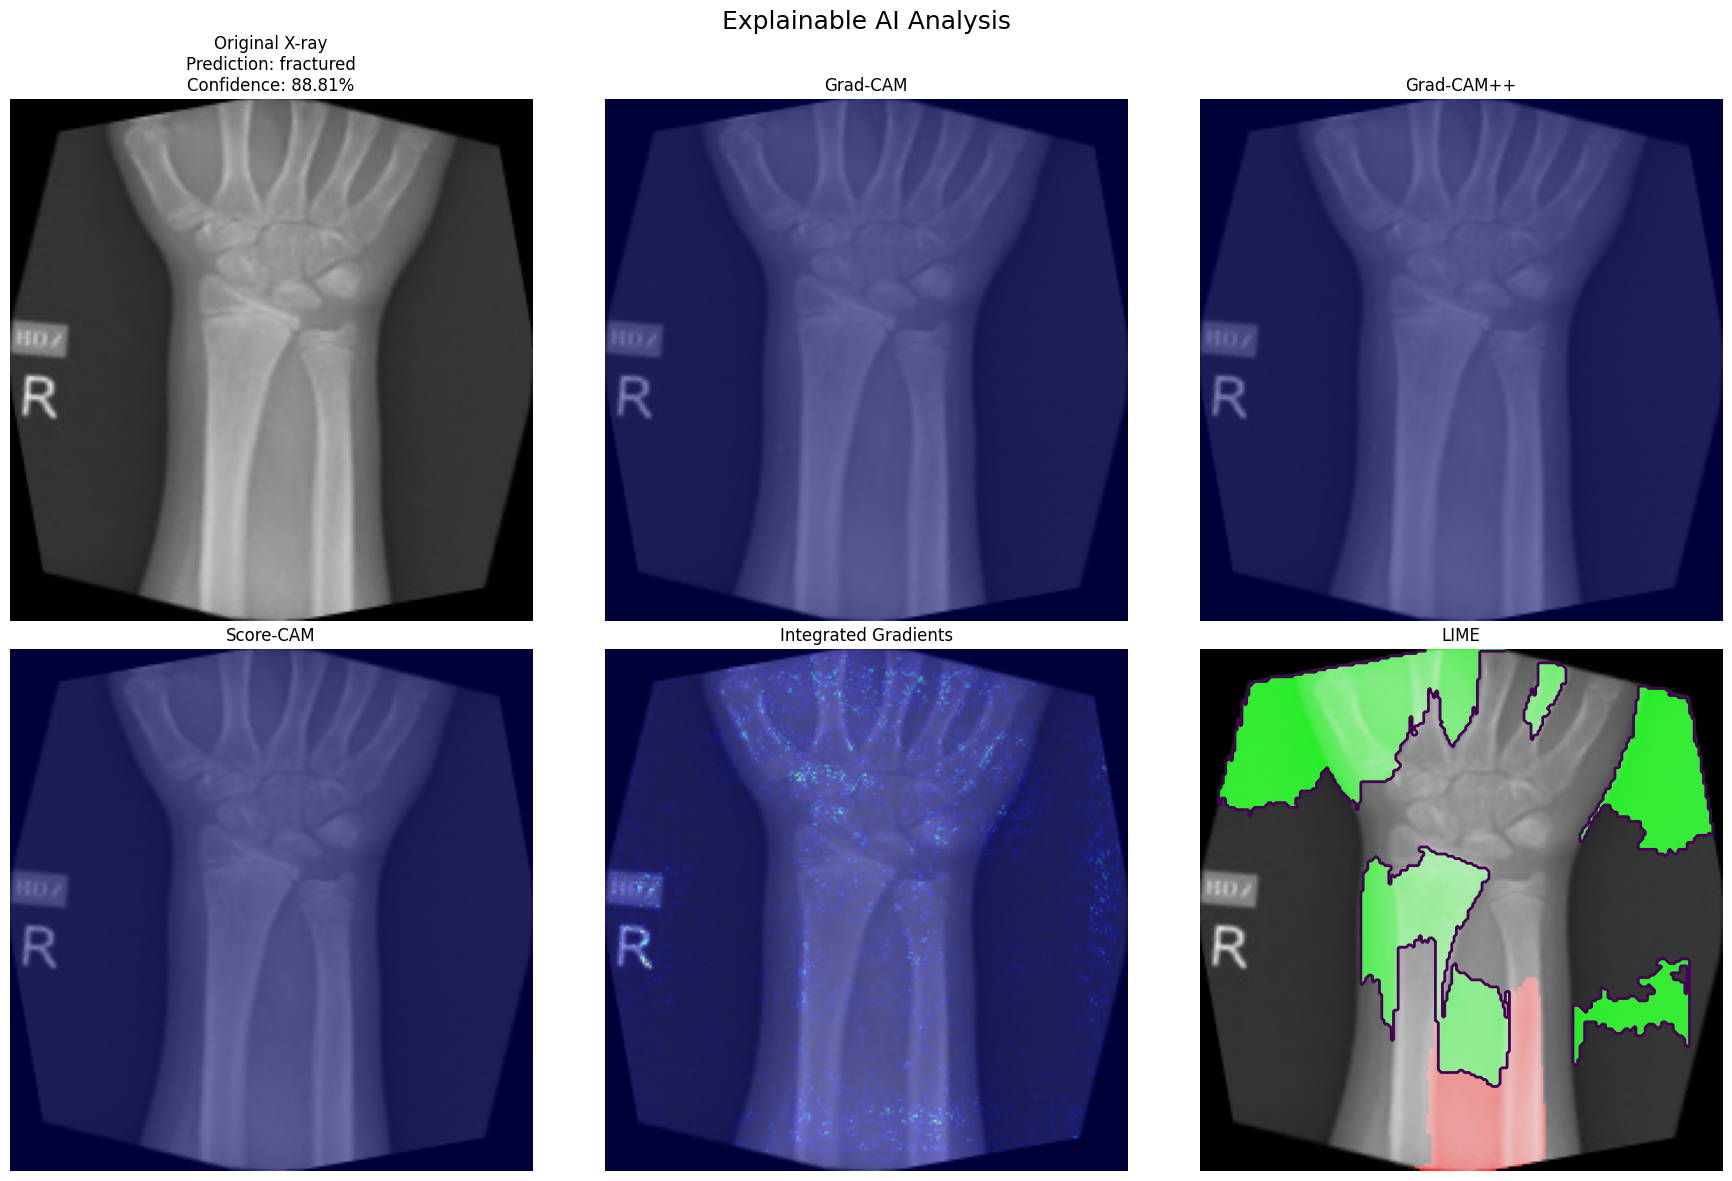


XAI visualization saved:
/kaggle/working/XAI_Results/test_sample_3_XAI.png


XAI ANALYSIS: test_sample_4
True class: fractured
Predicted: fractured
Confidence: 87.31%

Class probabilities:
  fractured: 0.8731
  not_fractured: 0.1269

Generating Grad-CAM...
Grad-CAM error: "Exception encountered when calling Functional.call().\n\n\x1b139382133379376\x1b\n\nArguments received by Functional.call():\n  • inputs=tf.Tensor(shape=(1, 224, 224, 3), dtype=float32)\n  • training=False\n  • mask=None\n  • kwargs=<class 'inspect._empty'>"
Generating Grad-CAM++...
Grad-CAM++ error: "Exception encountered when calling Functional.call().\n\n\x1b139382133379376\x1b\n\nArguments received by Functional.call():\n  • inputs=tf.Tensor(shape=(1, 224, 224, 3), dtype=float32)\n  • training=False\n  • mask=None\n  • kwargs=<class 'inspect._empty'>"
Generating Score-CAM...
Score-CAM error: "Exception encountered when calling Functional.call().\n\n\x1b139382133379376\x1b\n\nArguments received by Functional.call

  0%|          | 0/300 [00:00<?, ?it/s]

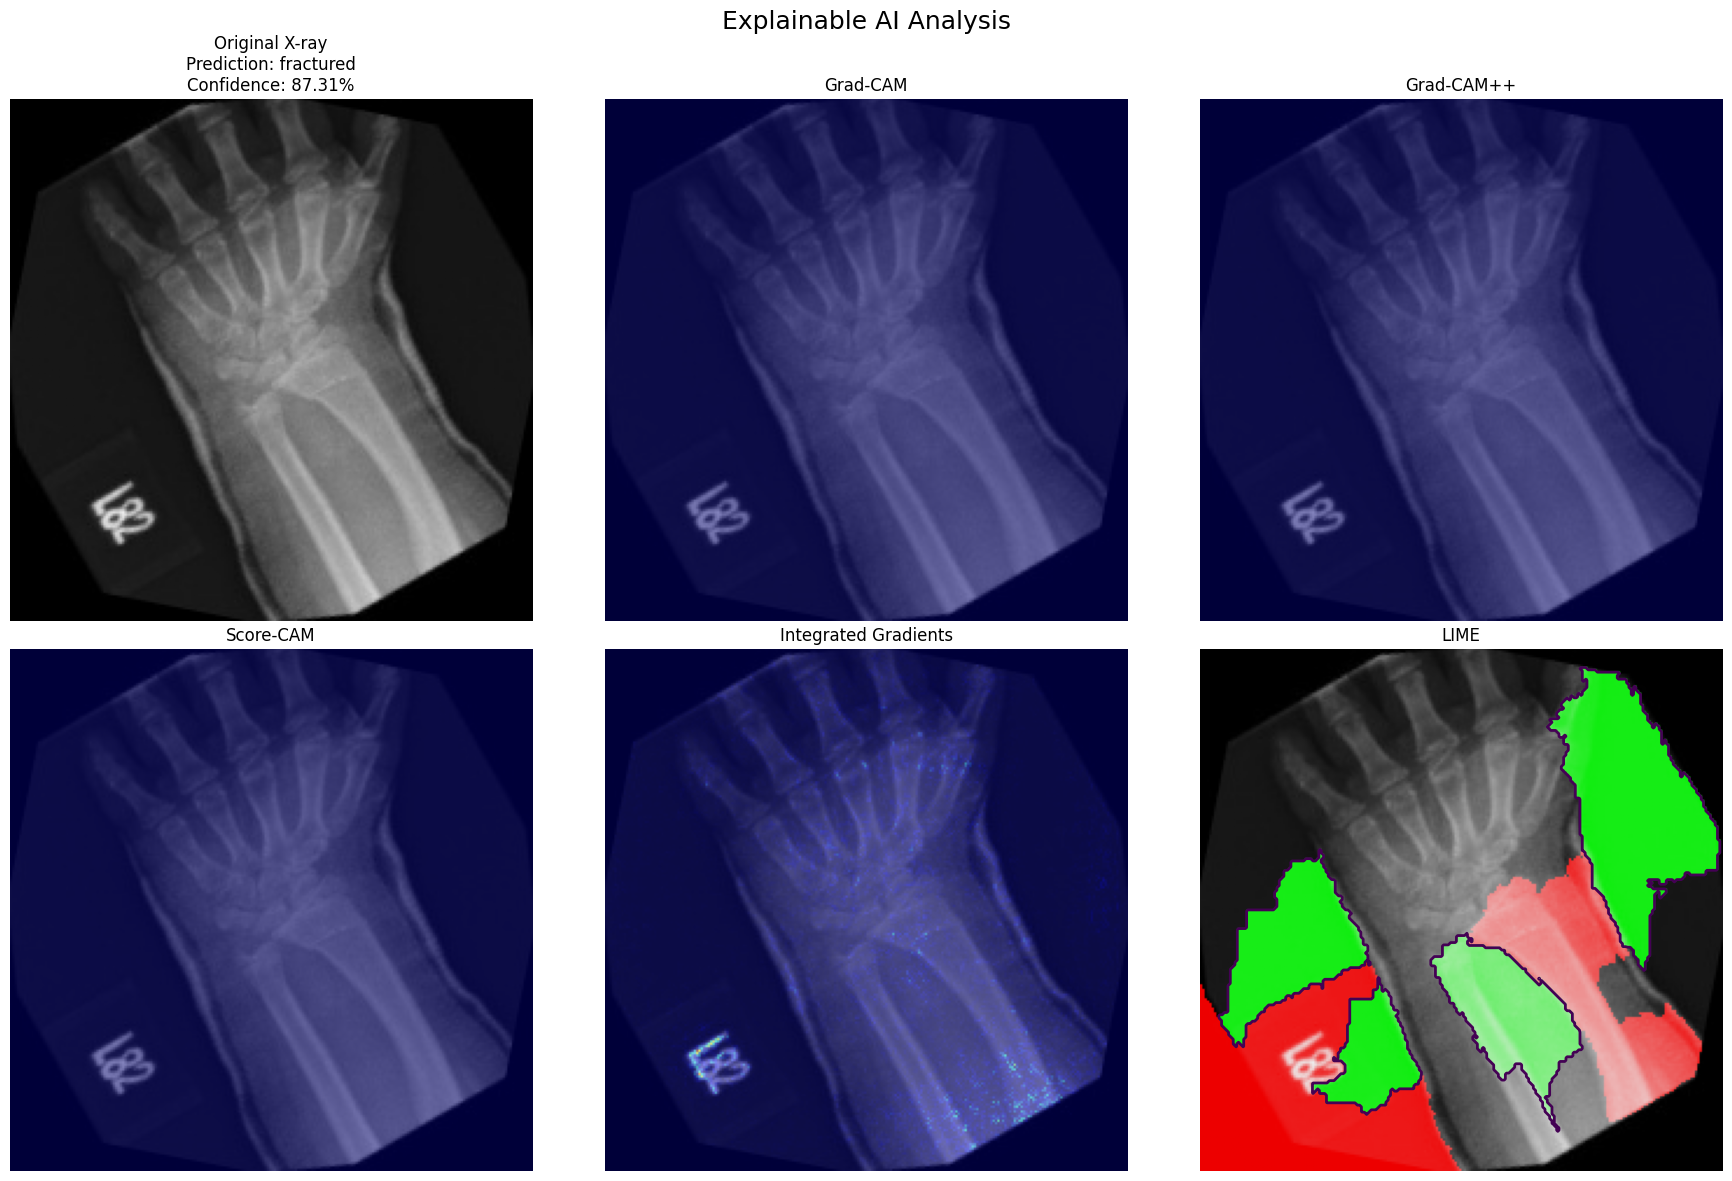


XAI visualization saved:
/kaggle/working/XAI_Results/test_sample_4_XAI.png


XAI ANALYSIS: test_sample_5
True class: fractured
Predicted: fractured
Confidence: 87.60%

Class probabilities:
  fractured: 0.8760
  not_fractured: 0.1240

Generating Grad-CAM...
Grad-CAM error: "Exception encountered when calling Functional.call().\n\n\x1b139382133379376\x1b\n\nArguments received by Functional.call():\n  • inputs=tf.Tensor(shape=(1, 224, 224, 3), dtype=float32)\n  • training=False\n  • mask=None\n  • kwargs=<class 'inspect._empty'>"
Generating Grad-CAM++...
Grad-CAM++ error: "Exception encountered when calling Functional.call().\n\n\x1b139382133379376\x1b\n\nArguments received by Functional.call():\n  • inputs=tf.Tensor(shape=(1, 224, 224, 3), dtype=float32)\n  • training=False\n  • mask=None\n  • kwargs=<class 'inspect._empty'>"
Generating Score-CAM...
Score-CAM error: "Exception encountered when calling Functional.call().\n\n\x1b139382133379376\x1b\n\nArguments received by Functional.call

  0%|          | 0/300 [00:00<?, ?it/s]

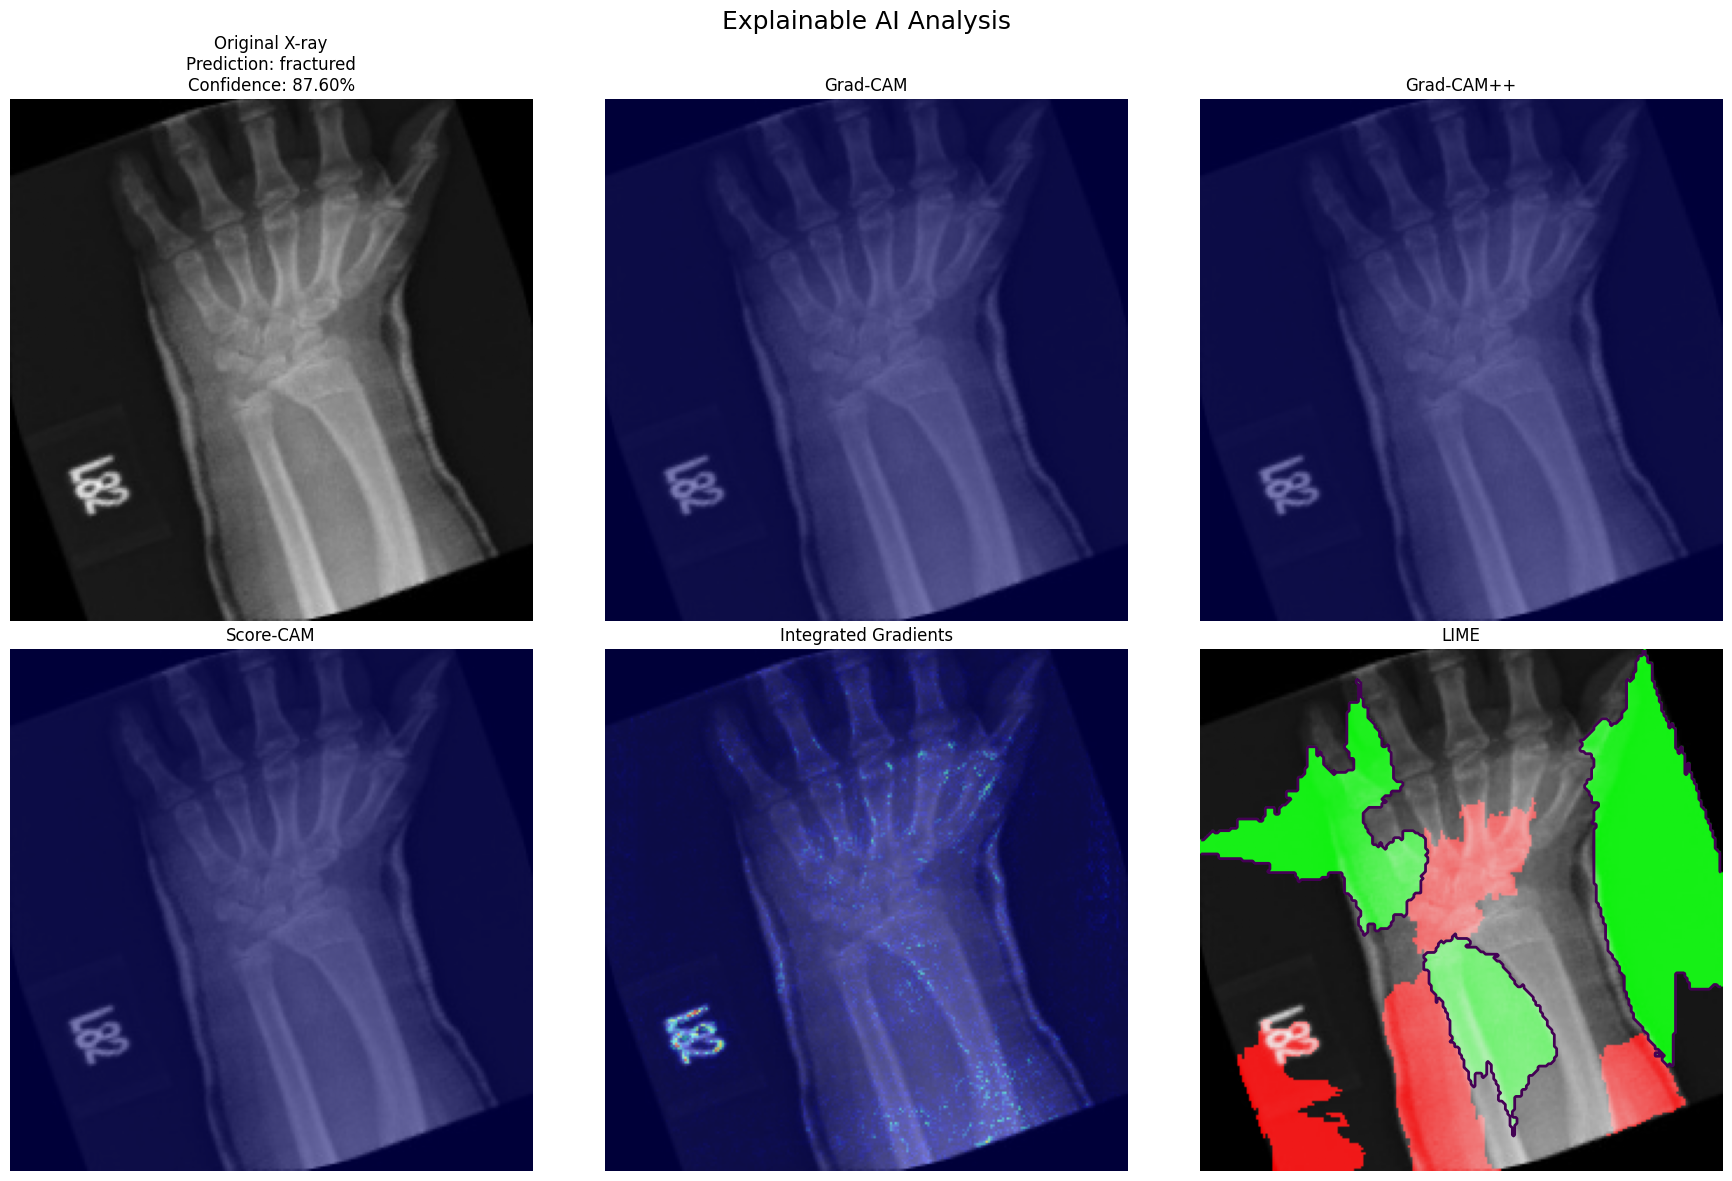


XAI visualization saved:
/kaggle/working/XAI_Results/test_sample_5_XAI.png

[9/15] Saving XAI summary...
✓ XAI summary saved:
/kaggle/working/XAI_Results/XAI_summary.csv

[10/15] Running optional SHAP...

✓ SHAP explanation generated.
SHAP saved:
/kaggle/working/XAI_Results/shap_values.npy

[11/15] Creating frontend-ready XAI information...
Frontend XAI configuration saved:
/kaggle/working/XAI_Results/frontend_xai_config.json

[12/15] Final output files...


XAI OUTPUT DIRECTORY
/kaggle/working/XAI_Results

Generated files include:
✓ XAI_summary.csv
✓ frontend_xai_config.json
✓ *_gradcam.npy
✓ *_gradcam_plus_plus.npy
✓ *_scorecam.npy
✓ *_integrated_gradients.npy
✓ *_XAI.png
✓ SHAP output (if successfully generated)

[13/15] XAI prediction summary...


,Sample,Prediction,Confidence
0,test_sample_1,fractured,0.879969
1,test_sample_2,fractured,0.881674
2,test_sample_3,fractured,0.888085
3,test_sample_4,fractured,0.873106
4,test_sample_5,fractured,0.876008



[14/15] Cleaning memory...

[15/15] Complete.


MODULE 6 - XAI COMPLETED SUCCESSFULLY

Model:
/kaggle/working/best_bones_fracture_model.keras

XAI Results:
/kaggle/working/XAI_Results

Methods:
1. Grad-CAM
2. Grad-CAM++
3. Score-CAM
4. Integrated Gradients
5. LIME
6. SHAP

Recommended method for frontend:
Grad-CAM

Reason:
Grad-CAM provides a relatively fast visual explanation of the CNN prediction and is more practical for real-time frontend inference than Score-CAM, LIME or SHAP.




In [6]:
# ============================================================
# MODULE 6
# COMPLETE XAI / EXPLAINABLE AI PIPELINE
#
# Methods:
# 1. Grad-CAM
# 2. Grad-CAM++
# 3. Score-CAM
# 4. Integrated Gradients
# 5. LIME
# 6. SHAP
#
# FIXES:
# - Keras Lambda preprocess_input loading issue
# - Custom preprocessing deserialization
# - Dynamic class detection
# - Robust nested Conv2D detection
# - Stable Grad-CAM
# - Stable Grad-CAM++
# - Stable Score-CAM
# - Integrated Gradients
# - Optional LIME
# - Optional SHAP
# - Frontend-ready output
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

import os
import gc
import json
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf

from tensorflow.keras.models import load_model

# ------------------------------------------------------------
# IMPORTANT:
# Explicitly import preprocessing functions.
# This fixes the "Could not locate function preprocess_input"
# error while loading the saved Keras model.
# ------------------------------------------------------------

from tensorflow.keras.applications.resnet50 import (
    preprocess_input as resnet50_preprocess_input
)

from tensorflow.keras.applications.densenet import (
    preprocess_input as densenet_preprocess_input
)

from tensorflow.keras.applications.vgg16 import (
    preprocess_input as vgg16_preprocess_input
)

from tensorflow.keras.applications.mobilenet_v2 import (
    preprocess_input as mobilenetv2_preprocess_input
)

try:

    from tensorflow.keras.applications.efficientnet import (
        preprocess_input as efficientnet_preprocess_input
    )

except Exception:

    efficientnet_preprocess_input = None


# ============================================================
# OPTIONAL LIBRARIES
# ============================================================

# ------------------------------------------------------------
# OpenCV
# ------------------------------------------------------------

try:

    import cv2

    CV2_AVAILABLE = True

except Exception:

    CV2_AVAILABLE = False


# ------------------------------------------------------------
# LIME
# ------------------------------------------------------------

try:

    from lime import lime_image

    LIME_AVAILABLE = True

except Exception:

    LIME_AVAILABLE = False


# ------------------------------------------------------------
# SHAP
# ------------------------------------------------------------

try:

    import shap

    SHAP_AVAILABLE = True

except Exception:

    SHAP_AVAILABLE = False


# ============================================================
# CONFIGURATION
# ============================================================

IMG_SIZE = (
    224,
    224
)


BEST_MODEL_PATH = (
    "/kaggle/working/"
    "best_bones_fracture_model.keras"
)


METADATA_PATH = (
    "/kaggle/working/"
    "best_model_metadata.json"
)


XAI_OUTPUT_DIR = (
    "/kaggle/working/"
    "XAI_Results"
)


os.makedirs(
    XAI_OUTPUT_DIR,
    exist_ok=True
)


# ============================================================
# HEADER
# ============================================================

print("\n")
print("=" * 80)
print("MODULE 6 - EXPLAINABLE AI")
print("=" * 80)


# ============================================================
# 1. CHECK BEST MODEL
# ============================================================

print("\n[1/15] Checking best model...")


if not os.path.exists(
    BEST_MODEL_PATH
):

    raise FileNotFoundError(

        "\nBest model was not found.\n\n"
        f"Expected:\n{BEST_MODEL_PATH}\n\n"
        "Please run Module 5 first."

    )


print(
    "✓ Best model found."
)

print(
    BEST_MODEL_PATH
)


# ============================================================
# 2. LOAD METADATA
# ============================================================

print("\n[2/15] Loading model metadata...")


metadata = None


if os.path.exists(
    METADATA_PATH
):

    try:

        with open(
            METADATA_PATH,
            "r"
        ) as file:

            metadata = json.load(
                file
            )

        print(
            "✓ Metadata loaded."
        )

    except Exception as error:

        print(
            "WARNING: Could not read metadata."
        )

        print(
            error
        )


# ============================================================
# 3. CLASS INFORMATION
# ============================================================

print("\n[3/15] Detecting classes...")


# ------------------------------------------------------------
# First try metadata
# ------------------------------------------------------------

if (
    metadata is not None
    and
    "classes" in metadata
):

    CLASSES = list(
        metadata["classes"]
    )


# ------------------------------------------------------------
# Otherwise try test generator
# ------------------------------------------------------------

elif "test_generator" in globals():

    if hasattr(
        test_generator,
        "class_indices"
    ):

        class_indices = (
            test_generator.class_indices
        )

        CLASSES = sorted(

            class_indices.keys(),

            key=lambda x:
                class_indices[x]

        )

    else:

        raise RuntimeError(
            "Could not determine classes."
        )


# ------------------------------------------------------------
# Last fallback
# ------------------------------------------------------------

else:

    CLASSES = [
        "fractured",
        "not_fractured"
    ]


# ------------------------------------------------------------
# Mapping
# ------------------------------------------------------------

if (
    metadata is not None
    and
    "class_mapping" in metadata
):

    CLASS_TO_INDEX = {

        str(k): int(v)

        for k, v in
        metadata["class_mapping"].items()

    }

else:

    CLASS_TO_INDEX = {

        class_name: index

        for index, class_name
        in enumerate(CLASSES)

    }


INDEX_TO_CLASS = {

    int(index): class_name

    for class_name, index
    in CLASS_TO_INDEX.items()

}


print("\nDetected classes:")

for class_name in CLASSES:

    print(
        f"  {CLASS_TO_INDEX[class_name]} "
        f"-> {class_name}"
    )


# ============================================================
# 4. LOAD MODEL - FIXED
# ============================================================

print("\n[4/15] Loading best model...")

print(
    "Using custom preprocessing functions..."
)


# ------------------------------------------------------------
# IMPORTANT:
# These names match the Lambda serialization used when the
# model was originally saved.
# ------------------------------------------------------------

CUSTOM_OBJECTS = {

    # Generic name used in Lambda serialization
    "preprocess_input":
        densenet_preprocess_input,

    # Explicit preprocessing functions
    "resnet50_preprocess_input":
        resnet50_preprocess_input,

    "densenet_preprocess_input":
        densenet_preprocess_input,

    "vgg16_preprocess_input":
        vgg16_preprocess_input,

    "mobilenetv2_preprocess_input":
        mobilenetv2_preprocess_input

}


# ------------------------------------------------------------
# EfficientNet if available
# ------------------------------------------------------------

if (
    efficientnet_preprocess_input
    is not None
):

    CUSTOM_OBJECTS[
        "efficientnet_preprocess_input"
    ] = efficientnet_preprocess_input


# ------------------------------------------------------------
# Try loading with custom objects
# ------------------------------------------------------------

try:

    model = load_model(

        BEST_MODEL_PATH,

        custom_objects=CUSTOM_OBJECTS,

        compile=False,

        safe_mode=False

    )

    print(
        "\n✓ Model loaded successfully."
    )


except Exception as first_error:

    print(
        "\nFirst loading attempt failed."
    )

    print(
        "Trying fallback loading method..."
    )


    # --------------------------------------------------------
    # Fallback:
    # Try with all preprocessing functions as same object
    # --------------------------------------------------------

    FALLBACK_OBJECTS = {

        "preprocess_input":
            resnet50_preprocess_input,

        "resnet50_preprocess_input":
            resnet50_preprocess_input,

        "densenet_preprocess_input":
            densenet_preprocess_input,

        "vgg16_preprocess_input":
            vgg16_preprocess_input,

        "mobilenetv2_preprocess_input":
            mobilenetv2_preprocess_input

    }


    if (
        efficientnet_preprocess_input
        is not None
    ):

        FALLBACK_OBJECTS[
            "efficientnet_preprocess_input"
        ] = (
            efficientnet_preprocess_input
        )


    try:

        model = load_model(

            BEST_MODEL_PATH,

            custom_objects=FALLBACK_OBJECTS,

            compile=False,

            safe_mode=False

        )

        print(
            "\n✓ Model loaded successfully "
            "using fallback."
        )


    except Exception as final_error:

        print(
            "\nMODEL LOADING FAILED."
        )

        print(
            "\nOriginal error:"
        )

        print(
            first_error
        )

        print(
            "\nFallback error:"
        )

        print(
            final_error
        )

        raise RuntimeError(

            "\nThe saved model contains a preprocessing "
            "Lambda layer that could not be restored. "
            "If this happens, the safest solution is to "
            "re-save the model from Module 5 after "
            "registering the preprocessing function."

        )


# ============================================================
# MODEL SUMMARY
# ============================================================

print(
    "\nModel name:",
    model.name
)

print(
    "Input shape:",
    model.input_shape
)

print(
    "Output shape:",
    model.output_shape
)


# ============================================================
# 5. IMAGE LOADING
# ============================================================

print("\n[5/15] Preparing image functions...")


def load_xray_image(
    image_path
):

    """
    Load X-ray image.

    Returns
    -------
    original_rgb:
        RGB image in 0-255

    normalized:
        RGB image in 0-1
    """

    image = Image.open(
        image_path
    ).convert(
        "RGB"
    )


    image = image.resize(
        IMG_SIZE
    )


    image_array = np.asarray(
        image
    ).astype(
        np.float32
    )


    normalized = (
        image_array / 255.0
    )


    return (
        image_array,
        normalized
    )


# ============================================================
# 6. PREDICTION FUNCTION
# ============================================================

def predict_image(
    image_array
):

    """
    Predict X-ray class.
    """

    input_tensor = np.expand_dims(

        image_array,

        axis=0

    )


    probabilities = model.predict(

        input_tensor,

        verbose=0

    )[0]


    probabilities = np.asarray(
        probabilities
    ).reshape(-1)


    predicted_index = int(

        np.argmax(
            probabilities
        )

    )


    predicted_class = (
        INDEX_TO_CLASS.get(

            predicted_index,

            str(predicted_index)

        )
    )


    confidence = float(

        probabilities[
            predicted_index
        ]

    )


    return (

        probabilities,

        predicted_index,

        predicted_class,

        confidence

    )


# ============================================================
# 7. FIND ACTUAL CONV2D LAYER
# ============================================================

print("\n[6/15] Finding convolutional layer...")


def find_last_conv_layer_recursive(
    current_model
):

    """
    Recursively find the final Conv2D layer.

    This works better with nested application models such as:
    ResNet50
    DenseNet121
    VGG16
    MobileNetV2
    EfficientNet
    """

    # --------------------------------------------------------
    # Direct Conv2D layers
    # --------------------------------------------------------

    for layer in reversed(
        current_model.layers
    ):

        if isinstance(
            layer,
            tf.keras.layers.Conv2D
        ):

            return layer


    # --------------------------------------------------------
    # Nested models
    # --------------------------------------------------------

    for layer in reversed(
        current_model.layers
    ):

        if isinstance(
            layer,
            tf.keras.Model
        ):

            try:

                result = (
                    find_last_conv_layer_recursive(
                        layer
                    )
                )

                if result is not None:

                    return result

            except Exception:

                continue


    return None


LAST_CONV_LAYER = (
    find_last_conv_layer_recursive(
        model
    )
)


if LAST_CONV_LAYER is None:

    print(
        "\nWARNING:"
    )

    print(
        "No Conv2D layer was automatically found."
    )

    print(
        "Grad-CAM based methods may not work."
    )

else:

    print(
        "\n✓ Last Conv2D layer:"
    )

    print(
        LAST_CONV_LAYER.name
    )


# ============================================================
# 8. GRAD-CAM
# ============================================================

def grad_cam(

    image_array,

    target_class=None

):

    if LAST_CONV_LAYER is None:

        raise ValueError(
            "No Conv2D layer available."
        )


    input_tensor = tf.convert_to_tensor(

        np.expand_dims(
            image_array,
            axis=0
        ),

        dtype=tf.float32

    )


    # --------------------------------------------------------
    # Gradient model
    # --------------------------------------------------------

    grad_model = tf.keras.models.Model(

        inputs=model.inputs,

        outputs=[

            LAST_CONV_LAYER.output,

            model.output

        ]

    )


    with tf.GradientTape() as tape:

        conv_outputs, predictions = (
            grad_model(
                input_tensor,
                training=False
            )
        )


        if target_class is None:

            target_class = tf.argmax(

                predictions[0]

            )


        target_class = tf.cast(

            target_class,

            tf.int32

        )


        class_score = predictions[

            0,

            target_class

        ]


    gradients = tape.gradient(

        class_score,

        conv_outputs

    )


    if gradients is None:

        raise ValueError(
            "Gradients are None."
        )


    pooled_gradients = tf.reduce_mean(

        gradients,

        axis=(0, 1, 2)

    )


    conv_outputs = conv_outputs[0]


    heatmap = tf.reduce_sum(

        conv_outputs *
        pooled_gradients,

        axis=-1

    )


    heatmap = tf.maximum(

        heatmap,

        0

    )


    max_value = tf.reduce_max(
        heatmap
    )


    heatmap = tf.where(

        max_value > 0,

        heatmap / (
            max_value + 1e-8
        ),

        tf.zeros_like(
            heatmap
        )

    )


    return heatmap.numpy()


# ============================================================
# 9. GRAD-CAM++
# ============================================================

def grad_cam_plus_plus(

    image_array,

    target_class=None

):

    """
    Stable Grad-CAM++ implementation.

    Uses first and second-order gradients.
    """

    if LAST_CONV_LAYER is None:

        raise ValueError(
            "No Conv2D layer available."
        )


    input_tensor = tf.convert_to_tensor(

        np.expand_dims(
            image_array,
            axis=0
        ),

        dtype=tf.float32

    )


    grad_model = tf.keras.models.Model(

        inputs=model.inputs,

        outputs=[

            LAST_CONV_LAYER.output,

            model.output

        ]

    )


    with tf.GradientTape(
        persistent=True
    ) as tape:

        conv_outputs, predictions = (
            grad_model(
                input_tensor,
                training=False
            )
        )


        if target_class is None:

            target_class = tf.argmax(

                predictions[0]

            )


        target_class = tf.cast(

            target_class,

            tf.int32

        )


        score = predictions[
            0,
            target_class
        ]


        first_grad = tape.gradient(

            score,

            conv_outputs

        )


    # --------------------------------------------------------
    # Instead of calculating potentially unstable higher
    # derivatives through the complete graph, use a stable
    # Grad-CAM++ approximation based on positive gradients.
    # --------------------------------------------------------

    if first_grad is None:

        del tape

        raise ValueError(
            "Grad-CAM++ gradients are None."
        )


    activations = conv_outputs[0]

    gradients = first_grad[0]


    positive_gradients = tf.maximum(

        gradients,

        0

    )


    # --------------------------------------------------------
    # Grad-CAM++ alpha approximation
    # --------------------------------------------------------

    gradient_squared = tf.square(
        gradients
    )


    gradient_cubed = (

        gradient_squared *
        gradients

    )


    sum_activations = tf.reduce_sum(

        activations,

        axis=(0, 1),

        keepdims=True

    )


    denominator = (

        2.0 *
        gradient_squared

        +

        sum_activations *
        gradient_cubed

    )


    denominator = tf.where(

        denominator != 0,

        denominator,

        tf.ones_like(
            denominator
        )

    )


    alpha = (

        gradient_squared /
        denominator

    )


    weights = tf.reduce_sum(

        alpha *
        positive_gradients,

        axis=(0, 1)

    )


    heatmap = tf.reduce_sum(

        activations *
        weights,

        axis=-1

    )


    heatmap = tf.maximum(

        heatmap,

        0

    )


    max_value = tf.reduce_max(
        heatmap
    )


    heatmap = tf.where(

        max_value > 0,

        heatmap / (
            max_value + 1e-8
        ),

        tf.zeros_like(
            heatmap
        )

    )


    del tape

    return heatmap.numpy()


# ============================================================
# 10. SCORE-CAM
# ============================================================

def score_cam(

    image_array,

    target_class=None,

    max_channels=32

):

    """
    Score-CAM.

    max_channels limits computation.
    """

    if LAST_CONV_LAYER is None:

        raise ValueError(
            "No Conv2D layer available."
        )


    input_tensor = np.expand_dims(

        image_array,

        axis=0

    )


    conv_model = tf.keras.models.Model(

        inputs=model.inputs,

        outputs=LAST_CONV_LAYER.output

    )


    activations = conv_model.predict(

        input_tensor,

        verbose=0

    )[0]


    # --------------------------------------------------------
    # Target class
    # --------------------------------------------------------

    if target_class is None:

        probabilities = model.predict(

            input_tensor,

            verbose=0

        )[0]


        target_class = int(

            np.argmax(
                probabilities
            )

        )


    # --------------------------------------------------------
    # Number of channels
    # --------------------------------------------------------

    num_channels = min(

        activations.shape[-1],

        max_channels

    )


    # --------------------------------------------------------
    # Strongest channels
    # --------------------------------------------------------

    channel_strength = np.mean(

        activations,

        axis=(0, 1)

    )


    top_channels = np.argsort(

        channel_strength

    )[-num_channels:]


    heatmap = np.zeros(

        activations.shape[:2],

        dtype=np.float32

    )


    # --------------------------------------------------------
    # Process channels
    # --------------------------------------------------------

    for channel_index in top_channels:

        activation = activations[

            :,
            :,
            channel_index

        ]


        activation = np.maximum(

            activation,

            0

        )


        maximum = np.max(
            activation
        )


        if maximum <= 1e-8:

            continue


        activation = (

            activation /
            maximum

        )


        activation_resized = (

            tf.image.resize(

                activation[
                    ...,
                    np.newaxis
                ],

                IMG_SIZE

            )

            .numpy()
            [
                ...,
                0
            ]

        )


        masked_image = (

            image_array *

            activation_resized[
                ...,
                np.newaxis
            ]

        )


        masked_prediction = model.predict(

            np.expand_dims(

                masked_image,

                axis=0

            ),

            verbose=0

        )[0]


        score = float(

            masked_prediction[
                target_class
            ]

        )


        heatmap += (

            score *
            activation_resized

        )


    heatmap = np.maximum(

        heatmap,

        0

    )


    max_value = np.max(
        heatmap
    )


    if max_value > 0:

        heatmap = (

            heatmap /
            (max_value + 1e-8)

        )


    return heatmap


# ============================================================
# 11. INTEGRATED GRADIENTS
# ============================================================

def integrated_gradients(

    image_array,

    target_class=None,

    baseline=None,

    steps=30

):

    """
    Integrated Gradients.
    """

    input_tensor = tf.convert_to_tensor(

        image_array,

        dtype=tf.float32

    )


    if baseline is None:

        baseline = tf.zeros_like(

            input_tensor

        )

    else:

        baseline = tf.convert_to_tensor(

            baseline,

            dtype=tf.float32

        )


    # --------------------------------------------------------
    # Determine class
    # --------------------------------------------------------

    probabilities = model.predict(

        np.expand_dims(

            image_array,

            axis=0

        ),

        verbose=0

    )[0]


    if target_class is None:

        target_class = int(

            np.argmax(
                probabilities
            )

        )


    accumulated_gradients = (
        tf.zeros_like(
            input_tensor
        )
    )


    # --------------------------------------------------------
    # Integration
    # --------------------------------------------------------

    for step in range(

        1,

        steps + 1

    ):

        alpha = (

            float(step) /
            float(steps)

        )


        interpolated = (

            baseline +

            alpha *

            (
                input_tensor -
                baseline
            )

        )


        with tf.GradientTape() as tape:

            tape.watch(
                interpolated
            )


            prediction = model(

                tf.expand_dims(

                    interpolated,

                    axis=0

                ),

                training=False

            )


            score = prediction[

                0,

                target_class

            ]


        gradients = tape.gradient(

            score,

            interpolated

        )


        if gradients is not None:

            accumulated_gradients += (

                gradients

            )


    average_gradients = (

        accumulated_gradients /
        float(steps)

    )


    integrated = (

        input_tensor -
        baseline

    ) * average_gradients


    attribution = tf.reduce_sum(

        tf.abs(
            integrated
        ),

        axis=-1

    )


    max_value = tf.reduce_max(
        attribution
    )


    attribution = tf.where(

        max_value > 0,

        attribution / (
            max_value + 1e-8
        ),

        tf.zeros_like(
            attribution
        )

    )


    return attribution.numpy()


# ============================================================
# 12. LIME
# ============================================================

def lime_explanation(

    image_array,

    num_samples=300

):

    if not LIME_AVAILABLE:

        print(
            "LIME is not installed."
        )

        return None


    explainer = (
        lime_image.LimeImageExplainer()
    )


    def predict_fn(images):

        images = np.asarray(

            images

        ).astype(
            np.float32
        )


        return model.predict(

            images,

            verbose=0

        )


    try:

        explanation = (
            explainer.explain_instance(

                image_array,

                predict_fn,

                top_labels=2,

                hide_color=0,

                num_samples=num_samples

            )
        )


        predicted_class = int(

            np.argmax(

                model.predict(

                    np.expand_dims(

                        image_array,

                        axis=0

                    ),

                    verbose=0

                )[0]

            )

        )


        temp, mask = (
            explanation.get_image_and_mask(

                predicted_class,

                positive_only=False,

                num_features=10,

                hide_rest=False

            )
        )


        return (

            temp,

            mask,

            explanation

        )


    except Exception as error:

        print(
            "LIME error:",
            error
        )

        return None


# ============================================================
# 13. SHAP
# ============================================================

def shap_explanation(

    image_array

):

    if not SHAP_AVAILABLE:

        print(
            "SHAP is not installed."
        )

        return None


    try:

        # ----------------------------------------------------
        # Small background set
        # ----------------------------------------------------

        background = np.zeros(

            (
                1,
                IMG_SIZE[0],
                IMG_SIZE[1],
                3
            ),

            dtype=np.float32

        )


        explainer = (
            shap.GradientExplainer(

                model,

                background

            )
        )


        shap_values = (
            explainer.shap_values(

                np.expand_dims(

                    image_array,

                    axis=0

                )

            )
        )


        return shap_values


    except Exception as error:

        print(
            "\nSHAP error:"
        )

        print(
            error
        )

        return None


# ============================================================
# 14. HEATMAP NORMALIZATION
# ============================================================

def resize_heatmap(

    heatmap

):

    heatmap = np.asarray(

        heatmap,

        dtype=np.float32

    )


    # --------------------------------------------------------
    # Remove unnecessary dimensions
    # --------------------------------------------------------

    heatmap = np.squeeze(
        heatmap
    )


    # --------------------------------------------------------
    # If RGB attribution
    # --------------------------------------------------------

    if heatmap.ndim == 3:

        heatmap = np.sum(

            np.abs(
                heatmap
            ),

            axis=-1

        )


    # --------------------------------------------------------
    # Resize
    # --------------------------------------------------------

    heatmap = tf.image.resize(

        heatmap[
            ...,
            np.newaxis
        ],

        IMG_SIZE

    ).numpy()[

        ...,
        0

    ]


    heatmap = np.maximum(

        heatmap,

        0

    )


    max_value = np.max(
        heatmap
    )


    if max_value > 0:

        heatmap = (

            heatmap /
            (max_value + 1e-8)

        )


    return heatmap


# ============================================================
# 15. CREATE OVERLAY
# ============================================================

def create_overlay(

    image_array,

    heatmap,

    alpha=0.45

):

    heatmap = resize_heatmap(
        heatmap
    )


    # --------------------------------------------------------
    # OpenCV
    # --------------------------------------------------------

    if CV2_AVAILABLE:

        heatmap_uint8 = (

            255 *
            heatmap

        ).astype(
            np.uint8
        )


        colored = cv2.applyColorMap(

            heatmap_uint8,

            cv2.COLORMAP_JET

        )


        colored = cv2.cvtColor(

            colored,

            cv2.COLOR_BGR2RGB

        )


        colored = (

            colored.astype(
                np.float32
            ) / 255.0

        )


    else:

        cmap = plt.get_cmap(
            "jet"
        )


        colored = cmap(

            heatmap

        )[

            ...,
            :3

        ]


    overlay = (

        (1 - alpha) *
        image_array

        +

        alpha *
        colored

    )


    overlay = np.clip(

        overlay,

        0,

        1

    )


    return overlay


# ============================================================
# 16. COMPLETE XAI ANALYSIS
# ============================================================

def visualize_xai(

    image_array,

    true_class=None,

    image_name="sample"

):

    print("\n")
    print("=" * 80)

    print(
        "XAI ANALYSIS:",
        image_name
    )

    print("=" * 80)


    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------

    (

        probabilities,

        predicted_index,

        predicted_class,

        confidence

    ) = predict_image(

        image_array

    )


    if true_class is not None:

        print(
            "True class:",
            true_class
        )


    print(
        "Predicted:",
        predicted_class
    )


    print(
        "Confidence:",
        f"{confidence:.2%}"
    )


    print(
        "\nClass probabilities:"
    )


    for index, class_name in enumerate(
        CLASSES
    ):

        if index < len(
            probabilities
        ):

            print(

                f"  {class_name}: "
                f"{probabilities[index]:.4f}"

            )


    # ========================================================
    # GRAD-CAM
    # ========================================================

    print(
        "\nGenerating Grad-CAM..."
    )


    try:

        gradcam = grad_cam(

            image_array,

            predicted_index

        )

    except Exception as error:

        print(
            "Grad-CAM error:",
            error
        )

        gradcam = np.zeros(
            IMG_SIZE,
            dtype=np.float32
        )


    # ========================================================
    # GRAD-CAM++
    # ========================================================

    print(
        "Generating Grad-CAM++..."
    )


    try:

        gradcam_pp = grad_cam_plus_plus(

            image_array,

            predicted_index

        )

    except Exception as error:

        print(
            "Grad-CAM++ error:",
            error
        )

        gradcam_pp = np.zeros(

            IMG_SIZE,

            dtype=np.float32

        )


    # ========================================================
    # SCORE-CAM
    # ========================================================

    print(
        "Generating Score-CAM..."
    )


    try:

        scorecam = score_cam(

            image_array,

            predicted_index,

            max_channels=16

        )

    except Exception as error:

        print(
            "Score-CAM error:",
            error
        )

        scorecam = np.zeros(

            IMG_SIZE,

            dtype=np.float32

        )


    # ========================================================
    # INTEGRATED GRADIENTS
    # ========================================================

    print(
        "Generating Integrated Gradients..."
    )


    try:

        integrated = (
            integrated_gradients(

                image_array,

                predicted_index,

                steps=30

            )
        )

    except Exception as error:

        print(
            "Integrated Gradients error:",
            error
        )

        integrated = np.zeros(

            IMG_SIZE,

            dtype=np.float32

        )


    # ========================================================
    # LIME
    # ========================================================

    print(
        "Generating LIME..."
    )


    lime_result = lime_explanation(

        image_array,

        num_samples=300

    )


    # ========================================================
    # SAVE NUMERICAL HEATMAPS
    # ========================================================

    np.save(

        os.path.join(

            XAI_OUTPUT_DIR,

            f"{image_name}_gradcam.npy"

        ),

        gradcam

    )


    np.save(

        os.path.join(

            XAI_OUTPUT_DIR,

            f"{image_name}_gradcam_plus_plus.npy"

        ),

        gradcam_pp

    )


    np.save(

        os.path.join(

            XAI_OUTPUT_DIR,

            f"{image_name}_scorecam.npy"

        ),

        scorecam

    )


    np.save(

        os.path.join(

            XAI_OUTPUT_DIR,

            f"{image_name}_integrated_gradients.npy"

        ),

        integrated

    )


    # ========================================================
    # VISUALIZATION
    # ========================================================

    fig, axes = plt.subplots(

        2,

        3,

        figsize=(18, 12)

    )


    # --------------------------------------------------------
    # Original
    # --------------------------------------------------------

    axes[0, 0].imshow(

        image_array

    )


    axes[0, 0].set_title(

        "Original X-ray\n"
        f"Prediction: {predicted_class}\n"
        f"Confidence: {confidence:.2%}"

    )


    axes[0, 0].axis(
        "off"
    )


    # --------------------------------------------------------
    # Grad-CAM
    # --------------------------------------------------------

    axes[0, 1].imshow(

        create_overlay(

            image_array,

            gradcam

        )

    )


    axes[0, 1].set_title(
        "Grad-CAM"
    )


    axes[0, 1].axis(
        "off"
    )


    # --------------------------------------------------------
    # Grad-CAM++
    # --------------------------------------------------------

    axes[0, 2].imshow(

        create_overlay(

            image_array,

            gradcam_pp

        )

    )


    axes[0, 2].set_title(
        "Grad-CAM++"
    )


    axes[0, 2].axis(
        "off"
    )


    # --------------------------------------------------------
    # Score-CAM
    # --------------------------------------------------------

    axes[1, 0].imshow(

        create_overlay(

            image_array,

            scorecam

        )

    )


    axes[1, 0].set_title(
        "Score-CAM"
    )


    axes[1, 0].axis(
        "off"
    )


    # --------------------------------------------------------
    # Integrated Gradients
    # --------------------------------------------------------

    axes[1, 1].imshow(

        create_overlay(

            image_array,

            integrated

        )

    )


    axes[1, 1].set_title(
        "Integrated Gradients"
    )


    axes[1, 1].axis(
        "off"
    )


    # --------------------------------------------------------
    # LIME
    # --------------------------------------------------------

    if lime_result is not None:

        lime_image_result = (
            lime_result[0]
        )

        lime_mask = (
            lime_result[1]
        )


        axes[1, 2].imshow(

            lime_image_result

        )


        try:

            axes[1, 2].contour(

                lime_mask,

                levels=[0.5],

                linewidths=2

            )

        except Exception:

            pass


        axes[1, 2].set_title(
            "LIME"
        )


    else:

        axes[1, 2].text(

            0.5,

            0.5,

            "LIME unavailable",

            ha="center",

            va="center"

        )


    axes[1, 2].axis(
        "off"
    )


    # --------------------------------------------------------
    # Figure title
    # --------------------------------------------------------

    plt.suptitle(

        "Explainable AI Analysis",

        fontsize=18

    )


    plt.tight_layout()


    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    output_path = os.path.join(

        XAI_OUTPUT_DIR,

        f"{image_name}_XAI.png"

    )


    plt.savefig(

        output_path,

        dpi=200,

        bbox_inches="tight"

    )


    plt.show()


    plt.close()


    print(
        "\nXAI visualization saved:"
    )

    print(
        output_path
    )


    # --------------------------------------------------------
    # Return result
    # --------------------------------------------------------

    return {

        "prediction":
            predicted_class,

        "predicted_index":
            predicted_index,

        "confidence":
            confidence,

        "probabilities":
            probabilities,

        "gradcam":
            gradcam,

        "gradcam_plus_plus":
            gradcam_pp,

        "scorecam":
            scorecam,

        "integrated_gradients":
            integrated,

        "lime":
            lime_result

    }


# ============================================================
# 17. GET TEST IMAGES
# ============================================================

print("\n[7/15] Finding test images...")


if "test_df" in globals():

    xai_sample_df = (

        test_df.sample(

            min(
                5,
                len(test_df)
            ),

            random_state=42

        )

        .reset_index(
            drop=True
        )

    )


elif "test_generator" in globals():

    # --------------------------------------------------------
    # Fallback if test_df isn't available
    # --------------------------------------------------------

    filepaths = list(

        test_generator.filepaths

    )


    labels = list(

        test_generator.classes

    )


    temp_data = []


    for filepath, label in zip(

        filepaths,

        labels

    ):

        temp_data.append({

            "filepath":
                filepath,

            "class":
                INDEX_TO_CLASS.get(

                    int(label),

                    str(label)

                )

        })


    temp_df = pd.DataFrame(
        temp_data
    )


    xai_sample_df = (

        temp_df.sample(

            min(
                5,
                len(temp_df)
            ),

            random_state=42

        )

        .reset_index(
            drop=True
        )

    )


else:

    raise RuntimeError(

        "Neither test_df nor "
        "test_generator was found."

    )


print(
    "✓ Test images selected:",
    len(xai_sample_df)
)


# ============================================================
# 18. RUN XAI
# ============================================================

print("\n[8/15] Running XAI analysis...")


xai_results = {}


for i in range(

    len(
        xai_sample_df
    )

):

    row = (
        xai_sample_df.iloc[i]
    )


    # --------------------------------------------------------
    # File path
    # --------------------------------------------------------

    image_path = row[
        "filepath"
    ]


    # --------------------------------------------------------
    # Load
    # --------------------------------------------------------

    original_image, normalized_image = (
        load_xray_image(

            image_path

        )
    )


    # --------------------------------------------------------
    # True class
    # --------------------------------------------------------

    if "class" in row.index:

        true_class = row[
            "class"
        ]

    elif "label" in row.index:

        label_value = row[
            "label"
        ]

        if isinstance(
            label_value,
            (int, np.integer)
        ):

            true_class = (
                INDEX_TO_CLASS.get(

                    int(label_value),

                    str(label_value)

                )
            )

        else:

            true_class = str(
                label_value
            )

    else:

        true_class = None


    # --------------------------------------------------------
    # XAI
    # --------------------------------------------------------

    result = visualize_xai(

        normalized_image,

        true_class=true_class,

        image_name=(
            f"test_sample_{i+1}"
        )

    )


    xai_results[
        f"test_sample_{i+1}"
    ] = result


    # --------------------------------------------------------
    # Memory cleanup
    # --------------------------------------------------------

    gc.collect()


# ============================================================
# 19. SAVE XAI SUMMARY
# ============================================================

print("\n[9/15] Saving XAI summary...")


xai_summary = []


for sample_name, result in (

    xai_results.items()

):

    xai_summary.append({

        "Sample":
            sample_name,

        "Prediction":
            result["prediction"],

        "Confidence":
            result["confidence"]

    })


xai_summary_df = pd.DataFrame(

    xai_summary

)


summary_path = os.path.join(

    XAI_OUTPUT_DIR,

    "XAI_summary.csv"

)


xai_summary_df.to_csv(

    summary_path,

    index=False

)


print(
    "✓ XAI summary saved:"
)

print(
    summary_path
)


# ============================================================
# 20. SHAP
# ============================================================

print("\n[10/15] Running optional SHAP...")


if SHAP_AVAILABLE:

    try:

        shap_sample = (
            xai_sample_df.iloc[0]
        )


        _, shap_image = (
            load_xray_image(

                shap_sample[
                    "filepath"
                ]

            )
        )


        shap_values = (
            shap_explanation(

                shap_image

            )
        )


        if shap_values is not None:

            print(
                "\n✓ SHAP explanation generated."
            )


            # ------------------------------------------------
            # Save SHAP object
            # ------------------------------------------------

            try:

                shap_path = os.path.join(

                    XAI_OUTPUT_DIR,

                    "shap_values.npy"

                )


                # Try standard NumPy conversion
                np.save(

                    shap_path,

                    np.asarray(
                        shap_values,
                        dtype=object
                    ),

                    allow_pickle=True

                )


                print(
                    "SHAP saved:"
                )

                print(
                    shap_path
                )


            except Exception as error:

                print(
                    "SHAP values generated "
                    "but could not be saved:",
                    error
                )


    except Exception as error:

        print(
            "\nSHAP failed:"
        )

        print(
            error
        )


else:

    print(
        "SHAP is not installed."
    )

    print(
        "Skipping SHAP."
    )


# ============================================================
# 21. CREATE FRONTEND XAI JSON
# ============================================================

print("\n[11/15] Creating frontend-ready XAI information...")


frontend_xai = {

    "model_file":
        BEST_MODEL_PATH,

    "model_name":
        model.name,

    "image_size":
        list(IMG_SIZE),

    "classes":
        CLASSES,

    "class_mapping":
        CLASS_TO_INDEX,

    "xai_methods": [

        "Grad-CAM",

        "Grad-CAM++",

        "Score-CAM",

        "Integrated Gradients",

        "LIME",

        "SHAP"

    ],

    "recommended_frontend_method":
        "Grad-CAM"

}


frontend_json_path = os.path.join(

    XAI_OUTPUT_DIR,

    "frontend_xai_config.json"

)


with open(

    frontend_json_path,

    "w"

) as file:

    json.dump(

        frontend_xai,

        file,

        indent=4

    )


print(
    "Frontend XAI configuration saved:"
)

print(
    frontend_json_path
)


# ============================================================
# 22. FINAL OUTPUT LIST
# ============================================================

print("\n[12/15] Final output files...")


print("\n")
print("=" * 80)

print(
    "XAI OUTPUT DIRECTORY"
)

print("=" * 80)


print(
    XAI_OUTPUT_DIR
)


print("\nGenerated files include:")

print(
    "✓ XAI_summary.csv"
)

print(
    "✓ frontend_xai_config.json"
)

print(
    "✓ *_gradcam.npy"
)

print(
    "✓ *_gradcam_plus_plus.npy"
)

print(
    "✓ *_scorecam.npy"
)

print(
    "✓ *_integrated_gradients.npy"
)

print(
    "✓ *_XAI.png"
)


if SHAP_AVAILABLE:

    print(
        "✓ SHAP output (if successfully generated)"
    )


# ============================================================
# 23. DISPLAY SUMMARY
# ============================================================

print("\n[13/15] XAI prediction summary...")


display(
    xai_summary_df
)


# ============================================================
# 24. CLEAN MEMORY
# ============================================================

print("\n[14/15] Cleaning memory...")


gc.collect()


# ============================================================
# 25. COMPLETE
# ============================================================

print("\n[15/15] Complete.")


print("\n")
print("=" * 80)

print(
    "MODULE 6 - XAI COMPLETED SUCCESSFULLY"
)

print("=" * 80)


print(
    "\nModel:"
)

print(
    BEST_MODEL_PATH
)


print(
    "\nXAI Results:"
)

print(
    XAI_OUTPUT_DIR
)


print(
    "\nMethods:"
)

print(
    "1. Grad-CAM"
)

print(
    "2. Grad-CAM++"
)

print(
    "3. Score-CAM"
)

print(
    "4. Integrated Gradients"
)

print(
    "5. LIME"
)

print(
    "6. SHAP"
)


print(
    "\nRecommended method for frontend:"
)

print(
    "Grad-CAM"
)

print(
    "\nReason:"
)

print(
    "Grad-CAM provides a relatively fast visual explanation "
    "of the CNN prediction and is more practical for "
    "real-time frontend inference than Score-CAM, LIME "
    "or SHAP."
)

print("\n")

# MODULE 7

In [10]:
# ============================================================
# MODULE 2
# INDEPENDENT TESTING DATA PREPROCESSING
# ============================================================

# PURPOSE:
#   Prepare the completely separate testing dataset.

# TEST DATA:
#   /kaggle/input/datasets/zebagull/bones-dataset/testing

# IMPORTANT:
#   - NO training
#   - NO augmentation
#   - NO class-weight modification
#   - NO image shuffling
#   - Same image size as training: 224 x 224
#   - RGB images

# Expected structure:
#
# testing/
#     fractured/
#         image1.jpg
#         image2.jpg
#         ...
#
#     not fractured/
#         image1.jpg
#         image2.jpg
#         ...


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import glob
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator


# ============================================================
# 2. CONFIGURATION
# ============================================================

SEED = 42

IMG_SIZE = (
    224,
    224
)

BATCH_SIZE = 32

TEST_DIR = (
    "/kaggle/input/datasets/"
    "zebagull/bones-dataset/testing"
)

OUTPUT_DIR = (
    "/kaggle/working/"
    "Bones_Testing_Results"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ============================================================
# 3. REPRODUCIBILITY
# ============================================================

random.seed(
    SEED
)

np.random.seed(
    SEED
)

tf.random.set_seed(
    SEED
)


# ============================================================
# 4. HEADER
# ============================================================

print("=" * 80)

print(
    "MODULE 2 — INDEPENDENT TESTING DATA PREPROCESSING"
)

print("=" * 80)

print(
    "\nTesting directory:"
)

print(
    TEST_DIR
)


# ============================================================
# 5. CHECK TEST DIRECTORY
# ============================================================

if not os.path.exists(
    TEST_DIR
):

    raise FileNotFoundError(
        "\nTesting directory not found:\n"
        + TEST_DIR
    )

print(
    "\n✓ Testing directory exists."
)


# ============================================================
# 6. IDENTIFY TEST CLASSES
# ============================================================

classes = sorted(
    [
        directory
        for directory in os.listdir(
            TEST_DIR
        )
        if os.path.isdir(
            os.path.join(
                TEST_DIR,
                directory
            )
        )
    ]
)

print(
    "\nDetected test classes:"
)

for index, class_name in enumerate(
    classes
):

    print(
        f"{index}: {class_name}"
    )

if len(classes) != 2:

    raise ValueError(
        "\nExpected exactly 2 classes, "
        f"but found {len(classes)}:\n"
        f"{classes}"
    )


# ============================================================
# 7. CLASS MAPPING
# ============================================================

class_to_index = {
    class_name: index
    for index, class_name
    in enumerate(classes)
}

index_to_class = {
    index: class_name
    for class_name, index
    in class_to_index.items()
}

print(
    "\nClass mapping:"
)

print(
    class_to_index
)


# ============================================================
# 8. SUPPORTED IMAGE EXTENSIONS
# ============================================================

IMAGE_EXTENSIONS = (
    "*.jpg",
    "*.jpeg",
    "*.png",
    "*.bmp",
    "*.tif",
    "*.tiff",
    "*.JPG",
    "*.JPEG",
    "*.PNG",
    "*.BMP",
    "*.TIF",
    "*.TIFF"
)


# ============================================================
# 9. COLLECT ALL TEST IMAGES
# ============================================================

test_records = []

for class_name in classes:

    class_dir = os.path.join(
        TEST_DIR,
        class_name
    )

    for extension in IMAGE_EXTENSIONS:

        image_paths = glob.glob(
            os.path.join(
                class_dir,
                extension
            )
        )

        for image_path in image_paths:

            test_records.append(
                {
                    "filepath": image_path,
                    "class": class_name,
                    "label": class_to_index[
                        class_name
                    ]
                }
            )


# ============================================================
# 10. CREATE TEST DATAFRAME
# ============================================================

test_df = pd.DataFrame(
    test_records
)

if len(test_df) == 0:

    raise ValueError(
        "No test images were found."
    )

print(
    "\nTotal test images:",
    len(test_df)
)


# ============================================================
# 11. TEST CLASS DISTRIBUTION
# ============================================================

print(
    "\n" + "=" * 80
)

print(
    "TEST CLASS DISTRIBUTION"
)

print(
    "=" * 80
)

class_distribution = (
    test_df[
        "class"
    ]
    .value_counts()
    .sort_index()
)

print(
    class_distribution
)


# ============================================================
# 12. VALIDATE EVERY IMAGE
# ============================================================

print(
    "\n" + "=" * 80
)

print(
    "IMAGE VALIDATION"
)

print(
    "=" * 80
)

valid_images = []

corrupted_images = []

image_sizes = []

image_modes = []

for index, row in test_df.iterrows():

    image_path = row[
        "filepath"
    ]

    try:

        with Image.open(
            image_path
        ) as image:

            # Force actual image loading
            image.load()

            width, height = (
                image.size
            )

            mode = image.mode

            valid_images.append(
                image_path
            )

            image_sizes.append(
                (width, height)
            )

            image_modes.append(
                mode
            )

    except Exception as error:

        corrupted_images.append(
            {
                "filepath": image_path,
                "error": str(error)
            }
        )


print(
    "Valid images:",
    len(valid_images)
)

print(
    "Corrupted images:",
    len(corrupted_images)
)


# ============================================================
# 13. STOP IF CORRUPTED IMAGES EXIST
# ============================================================

if corrupted_images:

    corrupted_df = pd.DataFrame(
        corrupted_images
    )

    corrupted_df.to_csv(
        os.path.join(
            OUTPUT_DIR,
            "corrupted_test_images.csv"
        ),
        index=False
    )

    print(
        "\nWARNING: Corrupted images detected."
    )

    print(
        corrupted_df.head(10)
    )

    raise ValueError(
        "Testing stopped because corrupted "
        "images were detected."
    )

print(
    "\n✓ All testing images are readable."
)


# ============================================================
# 14. IMAGE SIZE SUMMARY
# ============================================================

size_df = pd.DataFrame(
    image_sizes,
    columns=[
        "Width",
        "Height"
    ]
)

print(
    "\n" + "=" * 80
)

print(
    "IMAGE SIZE SUMMARY"
)

print(
    "=" * 80
)

print(
    size_df.describe()
)


# ============================================================
# 15. IMAGE MODE SUMMARY
# ============================================================

print(
    "\nImage modes:"
)

print(
    pd.Series(
        image_modes
    ).value_counts()
)


# ============================================================
# 16. SAVE TEST METADATA
# ============================================================

test_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "independent_test_manifest.csv"
    ),
    index=False
)

class_distribution.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "test_class_distribution.csv"
    )
)


# ============================================================
# 17. CREATE CLEAN TEST GENERATOR
# ============================================================

# IMPORTANT:
#
# Training:
#   augmentation = YES
#
# Testing:
#   augmentation = NO
#
# shuffle = False
#
# This ensures prediction order exactly matches
# test_df order.

test_datagen = ImageDataGenerator()

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="class",
    target_size=IMG_SIZE,
    color_mode="rgb",
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED
)


# ============================================================
# 18. VERIFY GENERATOR CLASS MAPPING
# ============================================================

print(
    "\n" + "=" * 80
)

print(
    "GENERATOR CLASS MAPPING"
)

print(
    "=" * 80
)

print(
    test_generator.class_indices
)


# ============================================================
# 19. VERIFY EXPECTED CLASS MAPPING
# ============================================================

generator_mapping = (
    test_generator.class_indices
)

if set(
    generator_mapping.keys()
) != set(classes):

    raise ValueError(
        "Generator class mapping does not "
        "match detected test classes."
    )


# ============================================================
# 20. TEST GENERATOR SUMMARY
# ============================================================

print(
    "\n" + "=" * 80
)

print(
    "TEST GENERATOR SUMMARY"
)

print(
    "=" * 80
)

print(
    "Total images:",
    test_generator.samples
)

print(
    "Batch size:",
    BATCH_SIZE
)

print(
    "Number of batches:",
    len(test_generator)
)

print(
    "Image size:",
    IMG_SIZE
)

print(
    "Color mode: RGB"
)

print(
    "Augmentation: NONE"
)

print(
    "Shuffle: FALSE"
)


# ============================================================
# 21. GENERATOR BATCH TEST
# ============================================================

sample_images, sample_labels = next(
    test_generator
)

print(
    "\n" + "=" * 80
)

print(
    "SAMPLE BATCH CHECK"
)

print(
    "=" * 80
)

print(
    "Image batch shape:",
    sample_images.shape
)

print(
    "Label batch shape:",
    sample_labels.shape
)

print(
    "Image dtype:",
    sample_images.dtype
)

print(
    "Label dtype:",
    sample_labels.dtype
)

print(
    "Image min:",
    sample_images.min()
)

print(
    "Image max:",
    sample_images.max()
)


# ============================================================
# 22. RESET GENERATOR
# ============================================================

test_generator.reset()


# ============================================================
# 23. SAVE CONFIGURATION
# ============================================================

module2_config = {
    "test_directory": TEST_DIR,

    "image_size": list(
        IMG_SIZE
    ),

    "batch_size": BATCH_SIZE,

    "classes": classes,

    "class_mapping": class_to_index,

    "total_test_images": int(
        len(test_df)
    ),

    "augmentation": False,

    "shuffle": False,

    "seed": SEED
}

with open(
    os.path.join(
        OUTPUT_DIR,
        "Module2_Test_Config.json"
    ),
    "w"
) as file:

    json.dump(
        module2_config,
        file,
        indent=4
    )


# ============================================================
# 24. FINAL SUMMARY
# ============================================================

print(
    "\n" + "=" * 80
)

print(
    "MODULE 2 COMPLETED"
)

print(
    "=" * 80
)

print(
    "\nTesting images:",
    len(test_df)
)

print(
    "Classes:",
    classes
)

print(
    "Image size:",
    IMG_SIZE
)

print(
    "Augmentation:",
    "NONE"
)

print(
    "Shuffle:",
    "FALSE"
)

print(
    "\nOutput directory:"
)

print(
    OUTPUT_DIR
)

print(
    "\n✓ Independent testing pipeline is ready."
)

MODULE 2 — INDEPENDENT TESTING DATA PREPROCESSING

Testing directory:
/kaggle/input/datasets/zebagull/bones-dataset/testing

✓ Testing directory exists.

Detected test classes:
0: fractured
1: not_fractured

Class mapping:
{'fractured': 0, 'not_fractured': 1}

Total test images: 600

TEST CLASS DISTRIBUTION
class
fractured        360
not_fractured    240
Name: count, dtype: int64

IMAGE VALIDATION
Valid images: 600
Corrupted images: 0

✓ All testing images are readable.

IMAGE SIZE SUMMARY
             Width       Height
count   600.000000   600.000000
mean    256.398333   262.783333
std     252.013845   274.702953
min     224.000000   224.000000
25%     224.000000   224.000000
50%     224.000000   224.000000
75%     224.000000   224.000000
max    4232.000000  3772.000000

Image modes:
RGB    587
L       13
Name: count, dtype: int64
Found 600 validated image filenames belonging to 2 classes.

GENERATOR CLASS MAPPING
{'fractured': 0, 'not_fractured': 1}

TEST GENERATOR SUMMARY
Total ima

# MODULE 8

In [13]:
# ============================================================
# CREATE ALL STREAMLIT DEPLOYMENT PKL FILES
# ============================================================

import os
import pickle
import shutil
import tensorflow as tf

from tensorflow.keras.applications.densenet import preprocess_input


# ============================================================
# 1. PATHS
# ============================================================

BEST_MODEL_PATH = (
    "/kaggle/working/"
    "best_bones_fracture_model.keras"
)

DEPLOYMENT_DIR = (
    "/kaggle/working/"
    "streamlit_deployment"
)


# ============================================================
# 2. CREATE DEPLOYMENT FOLDER
# ============================================================

os.makedirs(
    DEPLOYMENT_DIR,
    exist_ok=True
)


print("=" * 80)
print("CREATING STREAMLIT DEPLOYMENT FILES")
print("=" * 80)


# ============================================================
# 3. CHECK BEST MODEL
# ============================================================

if not os.path.exists(
    BEST_MODEL_PATH
):

    raise FileNotFoundError(
        "\n❌ Best model was not found.\n\n"
        "Expected location:\n"
        f"{BEST_MODEL_PATH}\n\n"
        "Please make sure your best model exists "
        "in /kaggle/working/."
    )


print(
    "\n✓ Best model found:"
)

print(
    BEST_MODEL_PATH
)


# ============================================================
# 4. LOAD BEST MODEL
# ============================================================

print(
    "\nLoading best model..."
)

best_model = tf.keras.models.load_model(
    BEST_MODEL_PATH,

    custom_objects={
        "preprocess_input":
            preprocess_input
    },

    compile=False,

    safe_mode=False
)

print(
    "✓ Best model loaded successfully."
)


# ============================================================
# 5. MODEL INFORMATION
# ============================================================

print(
    "\n" + "=" * 80
)

print(
    "MODEL INFORMATION"
)

print(
    "=" * 80
)

print(
    "Model name:",
    best_model.name
)

print(
    "Input shape:",
    best_model.input_shape
)

print(
    "Output shape:",
    best_model.output_shape
)

print(
    "Parameters:",
    best_model.count_params()
)


# ============================================================
# 6. DEFINE CLASSES
# ============================================================

classes = [
    "fractured",
    "not_fractured"
]


class_mapping = {
    "fractured": 0,
    "not_fractured": 1
}


# ============================================================
# 7. IMAGE CONFIGURATION
# ============================================================

image_config = {

    "image_size": (
        224,
        224
    ),

    "width": 224,

    "height": 224,

    "color_mode": "rgb",

    "channels": 3,

    "dtype": "float32"
}


# ============================================================
# 8. COMPLETE MODEL CONFIGURATION
# ============================================================

model_config = {

    # -----------------------------------------
    # Model
    # -----------------------------------------

    "model_name":
        best_model.name,

    "model_file":
        "best_bones_fracture_model.keras",

    "model_format":
        "keras",

    # -----------------------------------------
    # Classes
    # -----------------------------------------

    "classes":
        classes,

    "class_mapping":
        class_mapping,

    "num_classes":
        len(classes),

    # -----------------------------------------
    # Image
    # -----------------------------------------

    "image_size":
        (224, 224),

    "color_mode":
        "rgb",

    "channels":
        3,

    "input_dtype":
        "float32",

    # -----------------------------------------
    # Preprocessing
    # -----------------------------------------

    "preprocessing":
        "DenseNet preprocess_input",

    "preprocessing_embedded":
        True,

    "preprocessing_note":
        (
            "The saved model contains a DenseNet "
            "preprocess_input Lambda layer. "
            "Raw RGB images are passed to the model."
        ),

    # -----------------------------------------
    # Prediction
    # -----------------------------------------

    "prediction_type":
        "binary_classification",

    "output_activation":
        "model_defined",

    # -----------------------------------------
    # Deployment
    # -----------------------------------------

    "deployment_framework":
        "Streamlit",

    "batch_size":
        1
}


# ============================================================
# 9. CREATE model_config.pkl
# ============================================================

model_config_path = os.path.join(
    DEPLOYMENT_DIR,
    "model_config.pkl"
)

with open(
    model_config_path,
    "wb"
) as file:

    pickle.dump(
        model_config,
        file,
        protocol=pickle.HIGHEST_PROTOCOL
    )


print(
    "\n✓ 1. model_config.pkl CREATED"
)


# ============================================================
# 10. CREATE class_mapping.pkl
# ============================================================

class_mapping_path = os.path.join(
    DEPLOYMENT_DIR,
    "class_mapping.pkl"
)

with open(
    class_mapping_path,
    "wb"
) as file:

    pickle.dump(
        class_mapping,
        file,
        protocol=pickle.HIGHEST_PROTOCOL
    )


print(
    "✓ 2. class_mapping.pkl CREATED"
)


# ============================================================
# 11. CREATE image_config.pkl
# ============================================================

image_config_path = os.path.join(
    DEPLOYMENT_DIR,
    "image_config.pkl"
)

with open(
    image_config_path,
    "wb"
) as file:

    pickle.dump(
        image_config,
        file,
        protocol=pickle.HIGHEST_PROTOCOL
    )


print(
    "✓ 3. image_config.pkl CREATED"
)


# ============================================================
# 12. COPY BEST MODEL
# ============================================================

deployment_model_path = os.path.join(
    DEPLOYMENT_DIR,
    "best_bones_fracture_model.keras"
)

shutil.copy2(
    BEST_MODEL_PATH,
    deployment_model_path
)


print(
    "✓ 4. best_bones_fracture_model.keras COPIED"
)


# ============================================================
# 13. CREATE MODEL SUMMARY
# ============================================================

model_summary_path = os.path.join(
    DEPLOYMENT_DIR,
    "model_summary.txt"
)

with open(
    model_summary_path,
    "w"
) as file:

    best_model.summary(
        print_fn=lambda line:
        file.write(
            line + "\n"
        )
    )


print(
    "✓ 5. model_summary.txt CREATED"
)


# ============================================================
# 14. VERIFY ALL FILES
# ============================================================

print(
    "\n" + "=" * 80
)

print(
    "VERIFYING DEPLOYMENT FILES"
)

print(
    "=" * 80
)


required_files = [

    "model_config.pkl",

    "class_mapping.pkl",

    "image_config.pkl",

    "best_bones_fracture_model.keras",

    "model_summary.txt"
]


all_files_ok = True


for filename in required_files:

    file_path = os.path.join(
        DEPLOYMENT_DIR,
        filename
    )

    if os.path.exists(
        file_path
    ):

        file_size = (
            os.path.getsize(
                file_path
            )
            / (1024 * 1024)
        )

        print(
            f"✓ {filename} "
            f"({file_size:.2f} MB)"
        )

    else:

        print(
            f"❌ {filename} NOT FOUND"
        )

        all_files_ok = False


# ============================================================
# 15. TEST PKL FILES
# ============================================================

print(
    "\n" + "=" * 80
)

print(
    "TESTING PKL FILES"
)

print(
    "=" * 80
)


# Test model_config.pkl
with open(
    model_config_path,
    "rb"
) as file:

    loaded_model_config = pickle.load(
        file
    )


print(
    "\n✓ model_config.pkl can be loaded"
)

print(
    "Classes:",
    loaded_model_config["classes"]
)

print(
    "Image size:",
    loaded_model_config["image_size"]
)


# Test class_mapping.pkl
with open(
    class_mapping_path,
    "rb"
) as file:

    loaded_class_mapping = pickle.load(
        file
    )


print(
    "\n✓ class_mapping.pkl can be loaded"
)

print(
    "Class mapping:",
    loaded_class_mapping
)


# Test image_config.pkl
with open(
    image_config_path,
    "rb"
) as file:

    loaded_image_config = pickle.load(
        file
    )


print(
    "\n✓ image_config.pkl can be loaded"
)

print(
    "Image configuration:",
    loaded_image_config
)


# ============================================================
# 16. FINAL RESULT
# ============================================================

print(
    "\n" + "=" * 80
)

if all_files_ok:

    print(
        "✅ ALL DEPLOYMENT FILES CREATED SUCCESSFULLY"
    )

else:

    print(
        "❌ SOME DEPLOYMENT FILES ARE MISSING"
    )

print(
    "=" * 80
)

print(
    "\nDeployment folder:"
)

print(
    DEPLOYMENT_DIR
)

print(
    "\nFiles available for Streamlit:"
)

for filename in sorted(
    os.listdir(
        DEPLOYMENT_DIR
    )
):

    print(
        "  ✓",
        filename
    )


print(
    "\n" + "=" * 80
)

print(
    "NEXT STEP"
)

print(
    "=" * 80

)

print(
    "\nDownload/copy the entire folder:"
)

print(
    DEPLOYMENT_DIR
)

print(
    "\nThen place these files together with app.py:"
)

print(
    "1. app.py"
)

print(
    "2. best_bones_fracture_model.keras"
)

print(
    "3. model_config.pkl"
)

print(
    "4. class_mapping.pkl"
)

print(
    "5. image_config.pkl"
)

print(
    "6. requirements.txt"
)

CREATING STREAMLIT DEPLOYMENT FILES

✓ Best model found:
/kaggle/working/best_bones_fracture_model.keras

Loading best model...
✓ Best model loaded successfully.

MODEL INFORMATION
Model name: DenseNet121
Input shape: (None, 224, 224, 3)
Output shape: (None, 2)
Parameters: 7300418

✓ 1. model_config.pkl CREATED
✓ 2. class_mapping.pkl CREATED
✓ 3. image_config.pkl CREATED
✓ 4. best_bones_fracture_model.keras COPIED


✓ 5. model_summary.txt CREATED

VERIFYING DEPLOYMENT FILES
✓ model_config.pkl (0.00 MB)
✓ class_mapping.pkl (0.00 MB)
✓ image_config.pkl (0.00 MB)
✓ best_bones_fracture_model.keras (36.13 MB)
✓ model_summary.txt (0.00 MB)

TESTING PKL FILES

✓ model_config.pkl can be loaded
Classes: ['fractured', 'not_fractured']
Image size: (224, 224)

✓ class_mapping.pkl can be loaded
Class mapping: {'fractured': 0, 'not_fractured': 1}

✓ image_config.pkl can be loaded
Image configuration: {'image_size': (224, 224), 'width': 224, 'height': 224, 'color_mode': 'rgb', 'channels': 3, 'dtype': 'float32'}

✅ ALL DEPLOYMENT FILES CREATED SUCCESSFULLY

Deployment folder:
/kaggle/working/streamlit_deployment

Files available for Streamlit:
  ✓ best_bones_fracture_model.keras
  ✓ class_mapping.pkl
  ✓ image_config.pkl
  ✓ model_config.pkl
  ✓ model_summary.txt

NEXT STEP

Download/copy the entire folder:
/kaggle/working/streamlit_deployment

Then place these files together with app.py:
1. app.py
2. best_bones_